In [2]:
"""
setup_data.py - 데이터 압축 해제 스크립트
Mac에서 만든 zip의 한글 파일명도 정상 처리
"""
import zipfile
from pathlib import Path
import shutil
import sys

def extract_with_encoding(zip_path, target):
    """Mac에서 만든 zip의 한글 파일명 깨짐 문제 해결"""
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            # __MACOSX 폴더 스킵
            if info.filename.startswith('__MACOSX'):
                continue
            
            # 파일명 인코딩 복구 시도 (cp437 → utf-8)
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except (UnicodeDecodeError, UnicodeEncodeError):
                filename = info.filename
            
            # 디렉토리면 생성만
            if info.is_dir():
                (target / filename).mkdir(parents=True, exist_ok=True)
                continue
            
            # 파일 저장
            out_path = target / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)

def main():
    RAW_DIR = Path('../data/raw')
    EXTRACT_DIR = Path('data/extracted')
    
    if not RAW_DIR.exists():
        print(f'❌ {RAW_DIR} 폴더가 없습니다.')
        sys.exit(1)
    
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    
    zip_files = sorted(RAW_DIR.glob('*.zip'))
    if not zip_files:
        print(f'⚠️  {RAW_DIR} 에 zip 파일이 없습니다.')
        sys.exit(1)
    
    print(f'📦 {len(zip_files)}개 zip 파일 처리 시작\n')
    
    extracted = 0
    skipped = 0
    
    for zip_path in zip_files:
        target = EXTRACT_DIR / zip_path.stem
        
        if target.exists() and any(target.iterdir()):
            print(f'  ⏭  {zip_path.name} (이미 풀림)')
            skipped += 1
            continue
        
        print(f'  📂 {zip_path.name}')
        target.mkdir(exist_ok=True)
        try:
            extract_with_encoding(zip_path, target)
            csv_count = len(list(target.glob('*.csv')))
            print(f'      ✅ CSV {csv_count}개 생성')
            extracted += 1
        except Exception as e:
            print(f'      ❌ 에러: {e}')
    
    print(f'\n{"="*50}')
    print(f'✅ 완료: 새로 해제 {extracted}개, 스킵 {skipped}개')
    print(f'📁 데이터 위치: {EXTRACT_DIR.resolve()}')

if __name__ == '__main__':
    main()

📦 6개 zip 파일 처리 시작

  📂 상권분석서비스(점포_상권).zip
      ✅ CSV 6개 생성
  📂 서울시 상권분석서비스(길단위인구-상권).zip
      ✅ CSV 1개 생성
  📂 서울시 상권분석서비스(상권변화지표-상권).zip
      ✅ CSV 1개 생성
  📂 서울시 상권분석서비스(상주인구-상권).zip
      ✅ CSV 1개 생성
  📂 서울시 상권분석서비스(직장인구-상권).zip
      ✅ CSV 1개 생성
  📂 서울시_상권분석서비스(추정매출+영역).zip
      ✅ CSV 7개 생성

✅ 완료: 새로 해제 6개, 스킵 0개
📁 데이터 위치: /Users/t2025-m0126/Documents/공모전_최종프로젝트/seouldf/notebooks/data/extracted


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(' 환경 설정 완료')



 환경 설정 완료


In [4]:
import glob
import os
DATA_DIR = 'data/extracted/서울시_상권분석서비스(추정매출+영역)/'

# 추정매출 파일 자동 탐색
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))

print(f'총 파일: {len(sales_files)}개')
for f in sales_files:
    print(f'  {os.path.basename(f)}')

# 통합
sales_list = []
for path in sales_files:
    df = pd.read_csv(path, encoding='cp949', low_memory=False)
    sales_list.append(df)

sales = pd.concat(sales_list, ignore_index=True)
print(f'\n📦 통합 완료: {len(sales):,}행 × {len(sales.columns)}컬럼')
print(f' 메모리: {sales.memory_usage(deep=True).sum()/1024**2:.1f} MB')

# 영역 파일도 자동 탐색
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'\n  영역: {len(area):,}개 상권')

총 파일: 6개
  서울시_상권분석서비스(추정매출-상권)_2020년.csv
  서울시_상권분석서비스(추정매출-상권)_2021년.csv
  서울시_상권분석서비스(추정매출-상권)_2022년.csv
  서울시_상권분석서비스(추정매출-상권)_2023년.csv
  서울시_상권분석서비스(추정매출-상권)_2024년.csv
  서울시_상권분석서비스(추정매출-상권)_2025년.csv

📦 통합 완료: 519,931행 × 55컬럼
 메모리: 365.0 MB

  영역: 1,650개 상권


In [5]:
# 데이터 모양과 타입
print(f'추정매출: {sales.shape}')
print(f'영역:    {area.shape}')

key_cols = ['기준_년분기_코드','상권_구분_코드_명','상권_코드','상권_코드_명',
            '서비스_업종_코드','서비스_업종_코드_명','당월_매출_금액','당월_매출_건수']
print(sales[key_cols].dtypes)

추정매출: (519931, 55)
영역:    (1650, 11)
기준_년분기_코드      int64
상권_구분_코드_명       str
상권_코드          int64
상권_코드_명          str
서비스_업종_코드        str
서비스_업종_코드_명      str
당월_매출_금액       int64
당월_매출_건수       int64
dtype: object


In [6]:
최신_분기_코드 = sales['기준_년분기_코드'].max()
print(f'최신 분기: {최신_분기_코드}')

최신 분기: 20254


In [7]:
# 시간/공간 범위
print(f' 분기 범위: {sales["기준_년분기_코드"].min()} ~ {sales["기준_년분기_코드"].max()}')
print(f' 분기 수:   {sales["기준_년분기_코드"].nunique()}개')
print(f'\n 상권 수:   {sales["상권_코드"].nunique():,}개')
print(f'  업종 수:   {sales["서비스_업종_코드"].nunique()}개')

# 상권 구분 분포
print(f'\n 상권 구분별 ( {최신_분기_코드} 분기 기준)')
print(sales[sales['기준_년분기_코드']==최신_분기_코드]
      .drop_duplicates('상권_코드')['상권_구분_코드_명'].value_counts())

 분기 범위: 20201 ~ 20254
 분기 수:   24개

 상권 수:   1,603개
  업종 수:   63개

 상권 구분별 ( 20254 분기 기준)
상권_구분_코드_명
골목상권    1030
전통시장     280
발달상권     249
관광특구       6
Name: count, dtype: int64


In [8]:
# 55개 컬럼을 카테고리별로 정리
매출금액_컬럼 = [c for c in sales.columns if '매출_금액' in c]
매출건수_컬럼 = [c for c in sales.columns if '매출_건수' in c]

요일_금액 = [c for c in 매출금액_컬럼 if any(d in c for d in ['월요일','화요일','수요일','목요일','금요일','토요일','일요일','주중','주말'])]
시간_금액 = [c for c in 매출금액_컬럼 if '시간대' in c]
성별_금액 = [c for c in 매출금액_컬럼 if '남성' in c or '여성' in c]
연령_금액 = [c for c in 매출금액_컬럼 if '연령대' in c]

print(f' 매출금액 컬럼: {len(매출금액_컬럼)}개')
print(f'   - 기본:    당월_매출_금액')
print(f'   - 요일별:  {len(요일_금액)}개 (월~일 + 주중/주말)')
print(f'   - 시간대:  {len(시간_금액)}개 (6구간)')
print(f'   - 성별:    {len(성별_금액)}개')
print(f'   - 연령대:  {len(연령_금액)}개 (10~60+)')
print(f'\n 매출건수 컬럼: {len(매출건수_컬럼)}개 (금액과 동일 구조)')

 매출금액 컬럼: 24개
   - 기본:    당월_매출_금액
   - 요일별:  9개 (월~일 + 주중/주말)
   - 시간대:  6개 (6구간)
   - 성별:    2개
   - 연령대:  6개 (10~60+)

 매출건수 컬럼: 24개 (금액과 동일 구조)


In [9]:
# 객단가 컬럼 추가
sales['객단가'] = sales['당월_매출_금액'] / sales['당월_매출_건수'].replace(0, np.nan)

# 핵심 변수 기초통계
sales[['당월_매출_금액', '당월_매출_건수', '객단가']].describe(
    percentiles=[.01, .25, .5, .75, .95, .99]
)

,당월_매출_금액,당월_매출_건수,객단가
count,"519,931.00","519,931.00","519,931.00"
mean,"1,001,650,301.61","34,299.78","108,450.75"
std,"9,659,729,281.23","160,594.85","471,596.11"
min,31.00,1.00,9.67
1%,"1,054,123.00",15.00,"4,698.07"
25%,"44,074,782.50",799.00,"14,931.07"
50%,"166,349,258.00","4,237.00","33,128.27"
75%,"596,072,470.00","21,933.00","91,287.40"
95%,"3,335,149,457.00","148,021.50","400,505.23"
99%,"11,748,000,000.00","428,643.30","1,065,273.73"


In [10]:
# 영역 정보 merge
매출_영역 = sales.merge(
    area[['상권_코드','자치구_코드_명','행정동_코드_명','엑스좌표_값','와이좌표_값']],
    on='상권_코드', how='left'
)
print(f'merge 후: {매출_영역.shape}')
print(f'결측 자치구: {매출_영역["자치구_코드_명"].isna().sum()}')

merge 후: (519931, 60)
결측 자치구: 0


In [11]:
# 최신 분기로 필터 후 상권 단위 집계
최신분기 = 매출_영역[매출_영역['기준_년분기_코드']==최신_분기_코드]

상권집계 = 최신분기.groupby(
    ['상권_코드','상권_코드_명','상권_구분_코드_명','자치구_코드_명']
).agg(
    총매출=('당월_매출_금액','sum'),
    총건수=('당월_매출_건수','sum'),
    업종수=('서비스_업종_코드','nunique'),
).reset_index()

상권집계['객단가'] = 상권집계['총매출'] / 상권집계['총건수']
상권집계['log_매출'] = np.log10(상권집계['총매출'].clip(lower=1))
상권집계['총매출_억'] = (상권집계['총매출']/1e8).round(1)

print(f'분석 대상 상권: {len(상권집계):,}개')
상권집계.head(5)

분석 대상 상권: 1,565개


,상권_코드,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출,총건수,업종수,객단가,log_매출,총매출_억
0,3001491,이태원 관광특구,관광특구,용산구,96748250708,3137664,33,"30,834.48",10.99,967.50
1,3001492,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,537829815743,15760017,53,"34,126.22",11.73,"5,378.30"
2,3001493,동대문패션타운 관광특구,관광특구,중구,151636997858,4447433,39,"34,095.40",11.18,"1,516.40"
3,3001494,종로?청계 관광특구,관광특구,종로구,263865637195,6909787,53,"38,187.23",11.42,"2,638.70"
4,3001495,잠실 관광특구,관광특구,송파구,380932087468,13411055,42,"28,404.33",11.58,"3,809.30"


In [12]:
# 전ㄴ체연도 로 필터 후 상권 단위 집계

전체_상권집계 = 매출_영역.groupby(
    ['상권_코드','상권_코드_명','상권_구분_코드_명','자치구_코드_명']
).agg(
    총매출=('당월_매출_금액','sum'),
    총건수=('당월_매출_건수','sum'),
    업종수=('서비스_업종_코드','nunique'),
).reset_index()

전체_상권집계['객단가'] = 전체_상권집계['총매출'] / 전체_상권집계['총건수']
전체_상권집계['log_매출'] = np.log10(전체_상권집계['총매출'].clip(lower=1))
전체_상권집계['총매출_억'] = (전체_상권집계['총매출']/1e8).round(1)

print(f'분석 대상 상권: {len(전체_상권집계):,}개')
전체_상권집계.head(5)

분석 대상 상권: 1,605개


,상권_코드,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출,총건수,업종수,객단가,log_매출,총매출_억
0,3001491,이태원 관광특구,관광특구,용산구,2052361925515,74650437,38,"27,492.97",12.31,"20,523.60"
1,3001492,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,9475814748069,316100677,56,"29,977.20",12.98,"94,758.10"
2,3001493,동대문패션타운 관광특구,관광특구,중구,2572486356230,84159330,45,"30,566.86",12.41,"25,724.90"
3,3001494,종로?청계 관광특구,관광특구,종로구,978727867459,27910035,54,"35,067.24",11.99,"9,787.30"
4,3001494,종로·청계 관광특구,관광특구,종로구,4786917746340,128435358,56,"37,271.03",12.68,"47,869.20"


---

## 자치구별 매출 * 매출건수 * 객단가

목표:
- 현재 분석에서 나아가 자치구별 어느상권의 매출이 왜 높은지 심화분석.
- 객단가 -> 고가소비중심의 프리미엄 상권
-  매출건수 -> 유동 인구 중심의 상권

---
* 최근 년분기 기준의 자치구별 매출 구조 통계

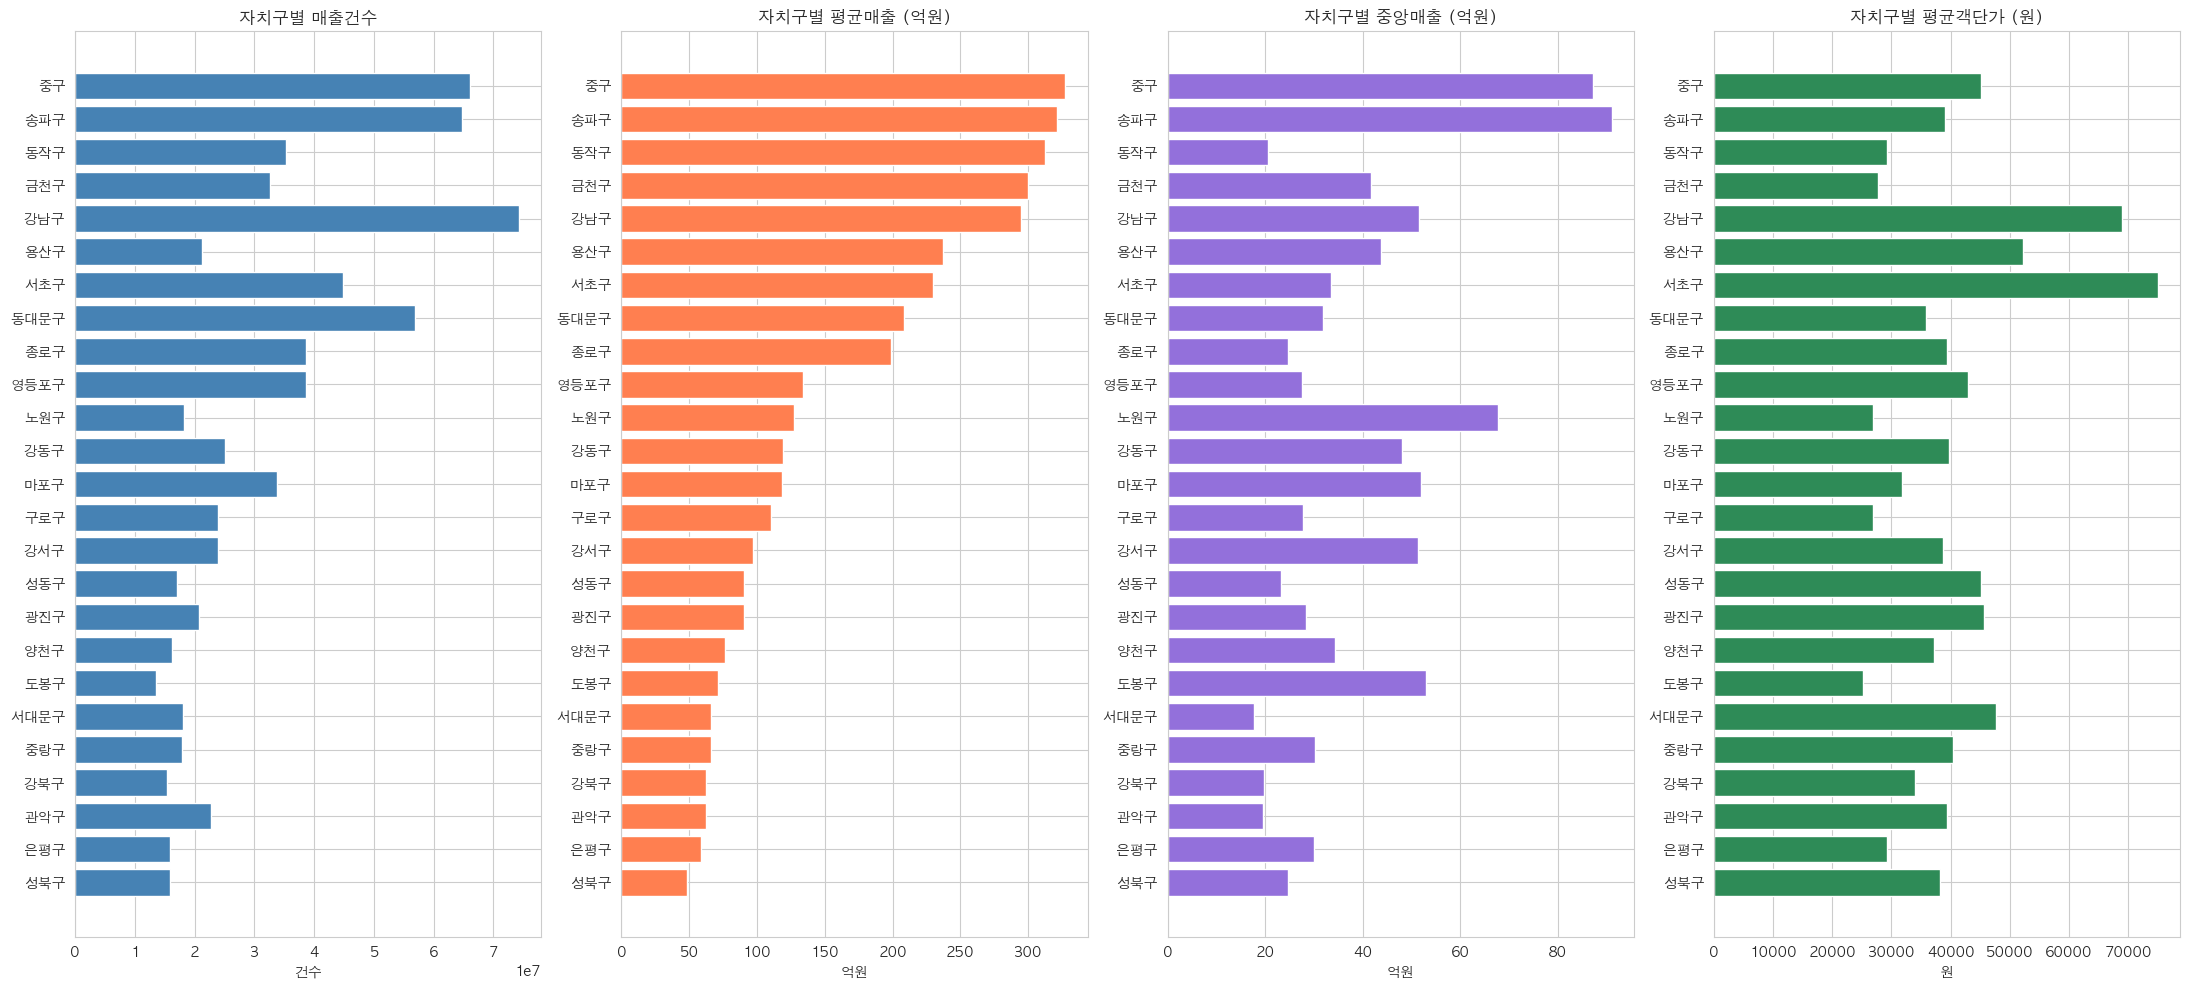

In [13]:

import matplotlib.pyplot as plt
import platform

# 한글 폰트
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 자치구별 집계
구분통계 = 상권집계.groupby('자치구_코드_명').agg(
    매출건수=('총건수', 'sum'),
    평균매출=('총매출', 'mean'),
    중앙매출=('총매출', 'median'),
    평균객단가=('객단가', 'mean')
).reset_index()

구분통계['평균객단가'] = 구분통계['평균객단가'].round(0)

# 평균매출 기준 정렬
구분통계 = 구분통계.sort_values('평균매출', ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(22, 10))

# 1. 매출건수
axes[0].barh(구분통계['자치구_코드_명'], 구분통계['매출건수'], color='steelblue')
axes[0].set_title('자치구별 매출건수')
axes[0].set_xlabel('건수')

# 2. 평균매출
axes[1].barh(구분통계['자치구_코드_명'], 구분통계['평균매출'] / 1e8, color='coral')
axes[1].set_title('자치구별 평균매출 (억원)')
axes[1].set_xlabel('억원')

# 3. 중앙매출
axes[2].barh(구분통계['자치구_코드_명'], 구분통계['중앙매출'] / 1e8, color='mediumpurple')
axes[2].set_title('자치구별 중앙매출 (억원)')
axes[2].set_xlabel('억원')

# 4. 평균객단가
axes[3].barh(구분통계['자치구_코드_명'], 구분통계['평균객단가'], color='seagreen')
axes[3].set_title('자치구별 평균객단가 (원)')
axes[3].set_xlabel('원')

plt.tight_layout()
plt.show()

- 인사이트:
  - 1.중구와 송파구 "규모의 시장"
    매출건수 + 평균매출 -> 1~2위 .
    거래도 많은데 단가도 높다.
    ==> 유동인구 기반의 대형상권으로 볼 수 있음.

  - 2. 서초와 강남 "고단가 저빈도 소비"
    평균객단가는 압도적 1~2위 인데, 매출건수는 중구 와 송파보다 현저히 낮음.
    ==> 소수 고가 거래 중심의 시장구조. 대중적 접근성보다 프리미엄 소비층이 타겟.

  - 3. 노원구  "일반적이지 않는 상권구조"
    매출건수+평균매출 모두 중하위권인데, 중앙매출이 유독 높음. / 평균은 낮지만 중앙값이 높다는건 극단적 고매출 업체가 없는대신,=>중간 규모 업체들이 고르게 분포한다는 의미. 상권구조가 다른구들과 다르다.

  - 4. 중구와 송파  "평균과 중앙의 괴리가 큼"
   평균매출은 압도적 1위인데 중앙매출은 그에 비해 훨씬 낮음
   => 소수의 초대형 매출업체가 평균을 끌어올리는 구조. 상권내 양극화가 심함.

  - 5. 객단가 하위권 구들의 공통점  "생활밀착 상권"
   노원,도봉,은평 등 객단가, 평균매출 모두 하위권이지만 매출건수가 낮지 않음.
   => 저단가 고빈도 소비의 구조. 생활밀착형 상권임.


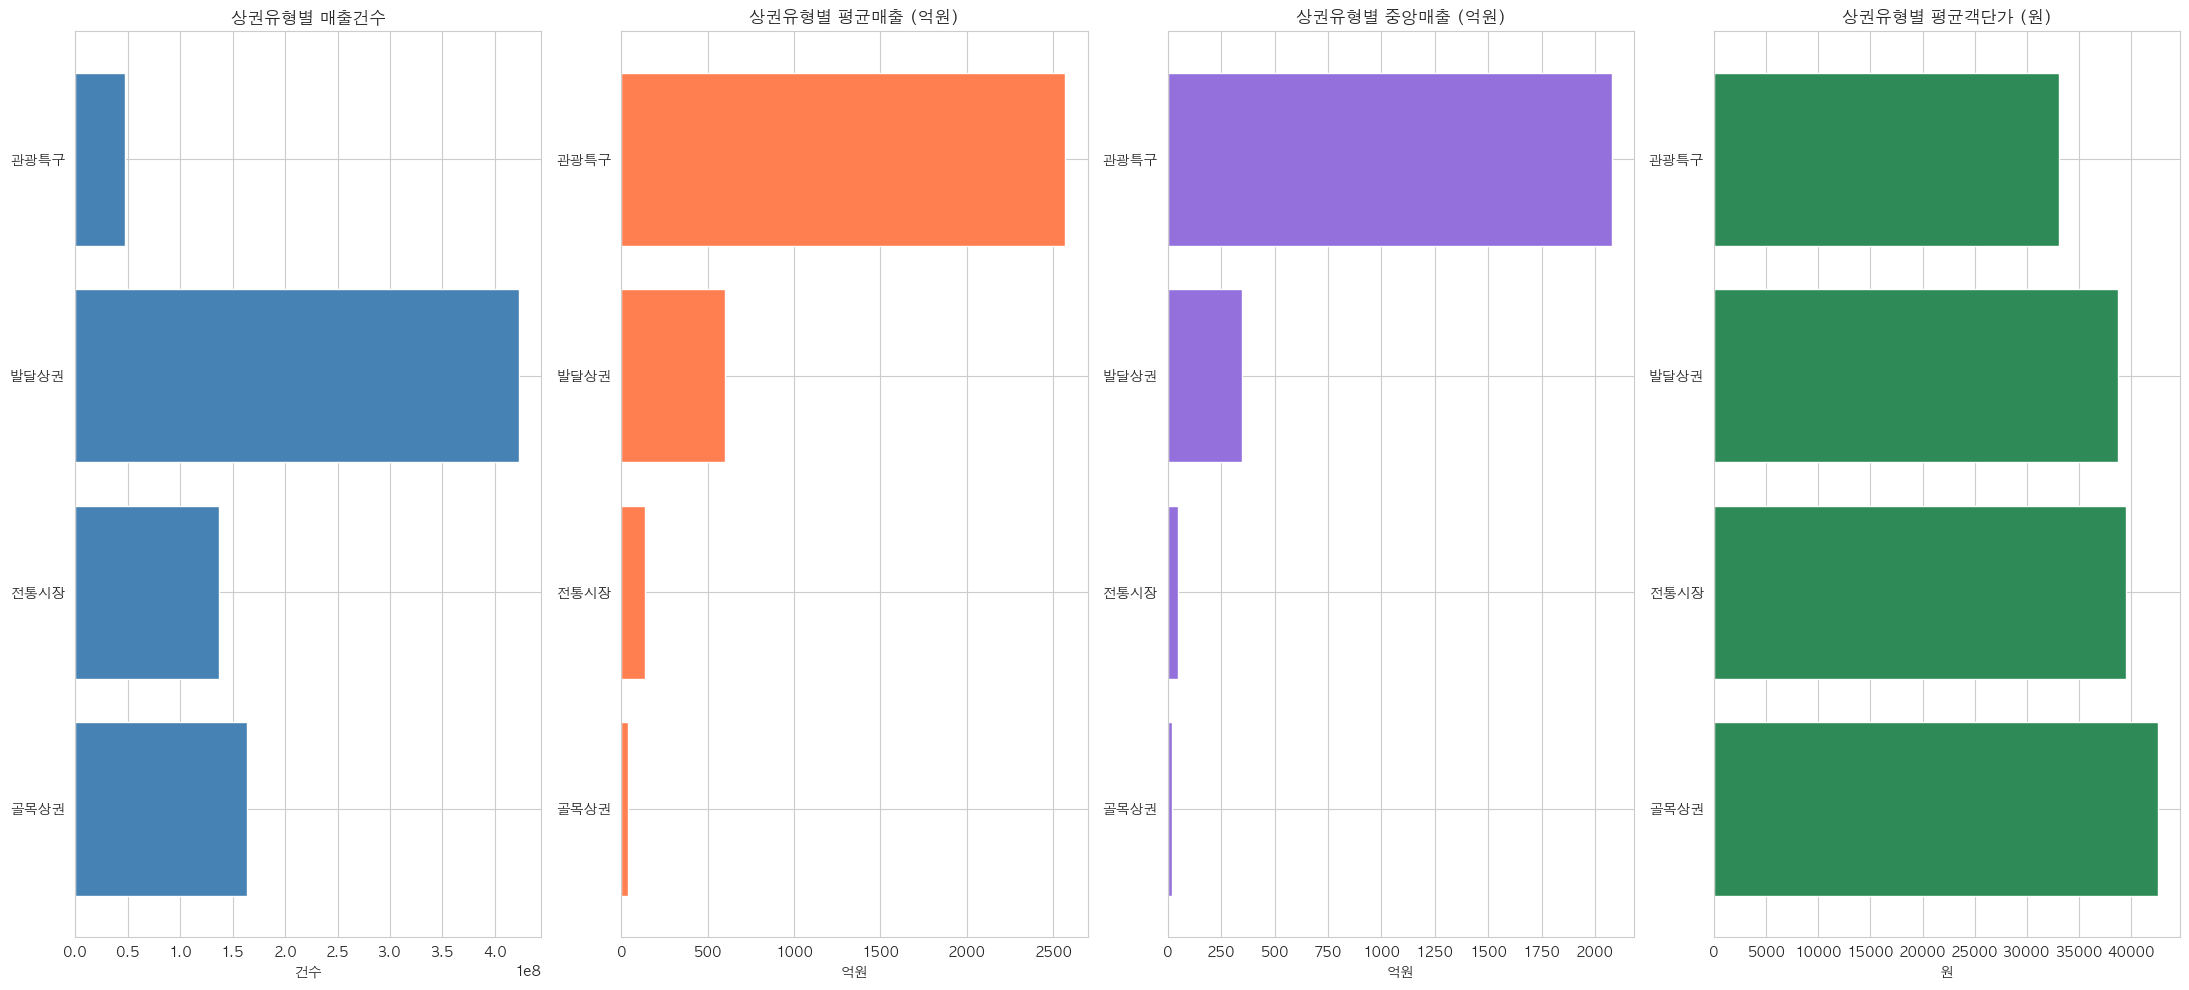

In [14]:

import matplotlib.pyplot as plt
import platform

# 한글 폰트
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상권유형별 집계
구분통계 = 상권집계.groupby('상권_구분_코드_명').agg(
    매출건수=('총건수', 'sum'),
    평균매출=('총매출', 'mean'),
    중앙매출=('총매출', 'median'),
    평균객단가=('객단가', 'mean')
).reset_index()

구분통계['평균객단가'] = 구분통계['평균객단가'].round(0)

# 평균매출 기준 정렬
구분통계 = 구분통계.sort_values('평균매출', ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(22, 10))

# 1. 매출건수
axes[0].barh(구분통계['상권_구분_코드_명'], 구분통계['매출건수'], color='steelblue')
axes[0].set_title('상권유형별 매출건수')
axes[0].set_xlabel('건수')


# 2. 평균매출
axes[1].barh(구분통계['상권_구분_코드_명'], 구분통계['평균매출'] / 1e8, color='coral')
axes[1].set_title('상권유형별 평균매출 (억원)')
axes[1].set_xlabel('억원')

# 3. 중앙매출
axes[2].barh(구분통계['상권_구분_코드_명'], 구분통계['중앙매출'] / 1e8, color='mediumpurple')
axes[2].set_title('상권유형별 중앙매출 (억원)')
axes[2].set_xlabel('억원')

# 4. 평균객단가
axes[3].barh(구분통계['상권_구분_코드_명'], 구분통계['평균객단가'], color='seagreen')
axes[3].set_title('상권유형별 평균객단가 (원)')
axes[3].set_xlabel('원')

plt.tight_layout()
plt.show()

* 인사이트:
- 1. 관광특구 
   << 방문수보다 매출규모 중심상권 구조 >>
   -  평균 매출 1위.
   -  중앙매출 1위.
   -  객단가 중간.
   -  매출건수 적음.
   - 한번 소비 규모 큼/ 상권당 매출 규모 큼/ 프리미엄 소비 특징
=> 고단가 소비중심 구조

- 2. 발달상권 << 서울 상권 매출의 양적 중심 축 >>
  - 매출건수 압도적 많음.
  - 평균매출은 관광특구보다 낮음.
  - 중앙매출 낮음.
  - 객단가 중상위
=> 서울내 매출건수 기준 핵심소비 거점으로, 방문기반 소비구조가 강하게 나타남.

- 3. 전통시장 << 객단가 대비 낮은 매출규모 구조 >>
  - 매출건수 중간.
  - 평균매출 낮음.
  - 중앙매출 낮음.
  - 객단가  생각보다 높음.
=> 객단가 수준은 유지되나 상권 전체 매출 규모는 상대적으로 낮아 생활밀착형 소비구조가 나타남.

- 4. 골목상권 << 소규모지만 고단가 생활형 소비구조 >>
  - 매출건수 중간.
  - 평균매출 낮음.
  - 중앙매출 낮음.
  - 객단가 1위.
=> 상대적 높은 객단가를 보이나 전체매출 규모는 낮아 지역기반 생활형 소비 특성이 나타난다.

++ 평균 과 중앙값 비교.  인사이트
- 1. 관광특구
  - 평균 = 중앙값
  => 특정 초대형 상권이 아니라 전체적으로 고르게 높은 매출 구조

- 2. 평균 > 중앙값
  => 일부 초대형 상권이 평균을 끌어올림.

==> 발달상권 = 매출 양극화 존재 / 관광특구 = 고른 고매출 구조

++ 객단가
골목 > 전통 > 발달 > 관광

예상 외로 관광이 객단가가 높지 않았음.
추측:
   관광특구는 방문수 기반 소비이고, 골목상권은 생활밀착 고단가소비
   (관광 = 많이 와서 많이 씀, 골목= 적에와도 크게씀 )




In [15]:
매출_영역.groupby('상권_구분_코드_명')['서비스_업종_코드'].count()

상권_구분_코드_명
골목상권    261023
관광특구      5997
발달상권    175653
전통시장     77258
Name: 서비스_업종_코드, dtype: int64

---
* 자치구별 여성, 나이별 
- 프리미엄 (서초, 강남, 용산) 고단가 소비층 
- 타겟대형 (상권중구, 송파) 매출건수+평균매출 상위
- 생활밀착 (노원, 도봉, 은평) 저단가 고빈도 하위권
- 이상치 (노원) 중앙값 특이구조 (생활밀착과 겹침)

In [16]:
# 성별 비중
성별컬럼 = ['남성_매출_금액', '여성_매출_금액']
성별라벨 = ['남성', '여성']

gender_data = 최신분기.groupby('자치구_코드_명')[성별컬럼].sum()
gender_data.columns = 성별라벨
gender_pct = gender_data.div(gender_data.sum(axis=1), axis=0) * 100

선택구 = ['강남구','서초구','노원구','중구','송파구']

print(gender_pct.loc[선택구].round(1))

            남성    여성
자치구_코드_명            
강남구      48.80 51.20
서초구      49.20 50.80
노원구      48.60 51.40
중구       46.10 53.90
송파구      49.70 50.30


In [17]:
# 연령 비중
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']
# 연령대 매출 비중
연령컬럼 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
        '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령라벨 = ['10대','20대','30대','40대','50대','60대+']

age_data = 최신분기.groupby('자치구_코드_명')[연령컬럼].sum()
age_data.columns = 연령라벨
age_pct = age_data.div(age_data.sum(axis=1), axis=0) * 100
age_pct = age_pct.loc[선택구]
print(age_pct.loc[선택구].round(1))

          10대   20대   30대   40대   50대  60대+
자치구_코드_명                                   
서초구      0.50 12.40 22.10 24.90 22.30 17.80
강남구      0.50 10.90 23.20 28.20 21.30 15.90
용산구      0.40 13.50 23.50 23.30 22.30 17.10
중구       0.70 10.20 19.70 18.90 20.80 29.70
송파구      0.50 10.30 22.00 25.40 19.90 21.90
노원구      0.70  9.00 15.20 24.30 27.00 23.80
도봉구      0.40  5.30 12.40 19.80 25.70 36.40
은평구      0.50  7.70 14.20 20.60 24.60 32.40


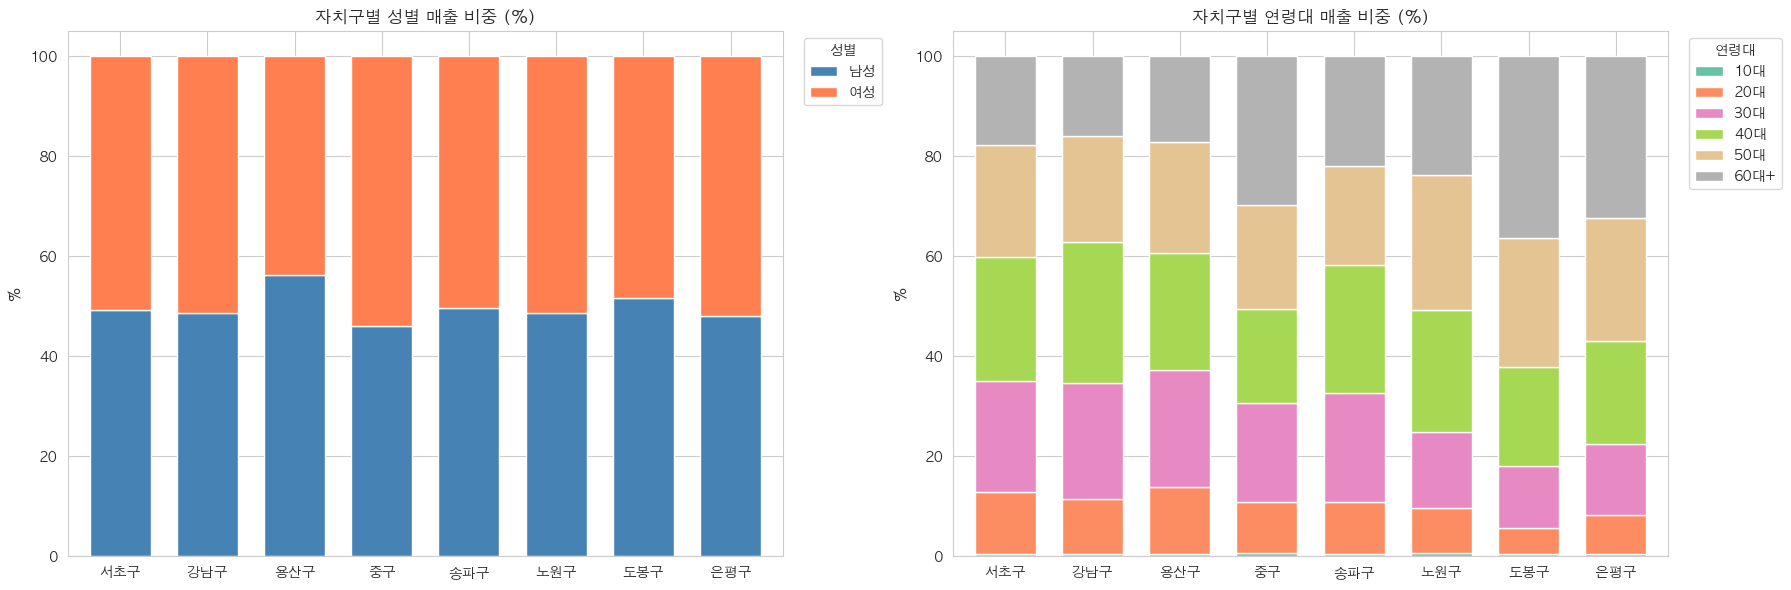

In [18]:
# 성별 매출 비중
성별컬럼 = ['남성_매출_금액', '여성_매출_금액']
성별라벨 = ['남성', '여성']

선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

gender_data = 최신분기.groupby('자치구_코드_명')[성별컬럼].sum()
gender_data.columns = 성별라벨
gender_pct = gender_data.div(gender_data.sum(axis=1), axis=0) * 100
gender_pct = gender_pct.loc[선택구]

# 연령대 매출 비중
연령컬럼 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
        '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령라벨 = ['10대','20대','30대','40대','50대','60대+']

age_data = 최신분기.groupby('자치구_코드_명')[연령컬럼].sum()
age_data.columns = 연령라벨
age_pct = age_data.div(age_data.sum(axis=1), axis=0) * 100
age_pct = age_pct.loc[선택구]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 성별
gender_pct.plot(kind='bar', stacked=True, ax=axes[0],
                color=['steelblue','coral'], width=0.7, edgecolor='white')
axes[0].set_title('자치구별 성별 매출 비중 (%)', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_xlabel('')
axes[0].legend(title='성별', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

# 연령대
age_pct.plot(kind='bar', stacked=True, ax=axes[1],
             colormap='Set2', width=0.7, edgecolor='white')
axes[1].set_title('자치구별 연령대 매출 비중 (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].legend(title='연령대', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

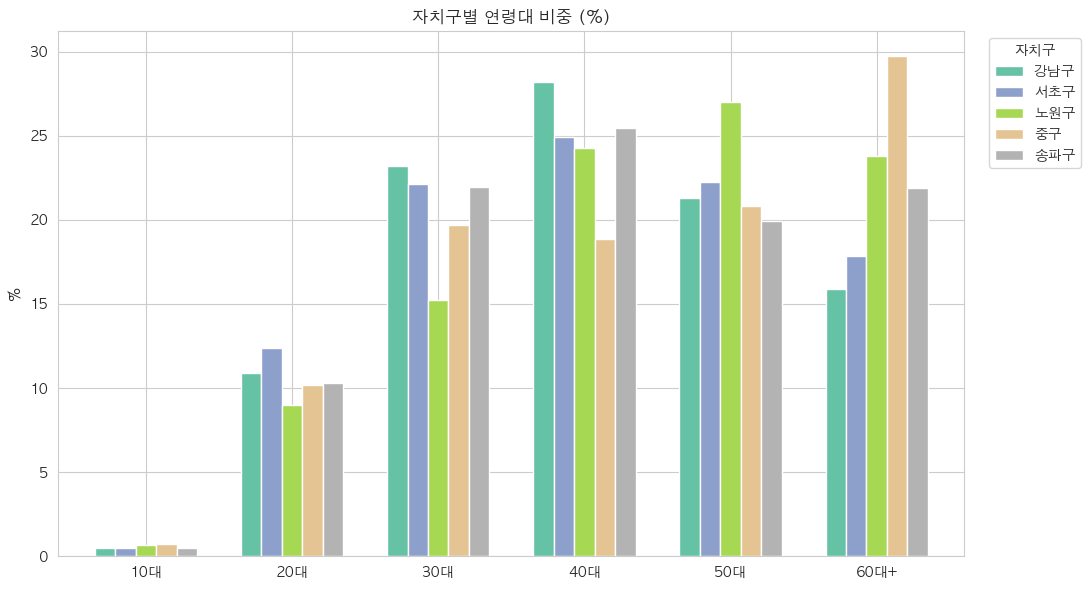

In [19]:
연령컬럼 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
        '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령라벨 = ['10대','20대','30대','40대','50대','60대+']
age_data = 최신분기.groupby('자치구_코드_명')[연령컬럼].sum()
age_data.columns = 연령라벨
age_pct = age_data.div(age_data.sum(axis=1), axis=0) * 100

선택구 = ['강남구','서초구','노원구','중구','송파구']

fig, ax = plt.subplots(figsize=(11, 6))
age_pct.loc[선택구].T.plot(kind='bar', stacked=False, ax=ax,
                           colormap='Set2', width=0.7, edgecolor='white')
ax.set_title('자치구별 연령대 비중 (%)', fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('')
ax.legend(title='자치구', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

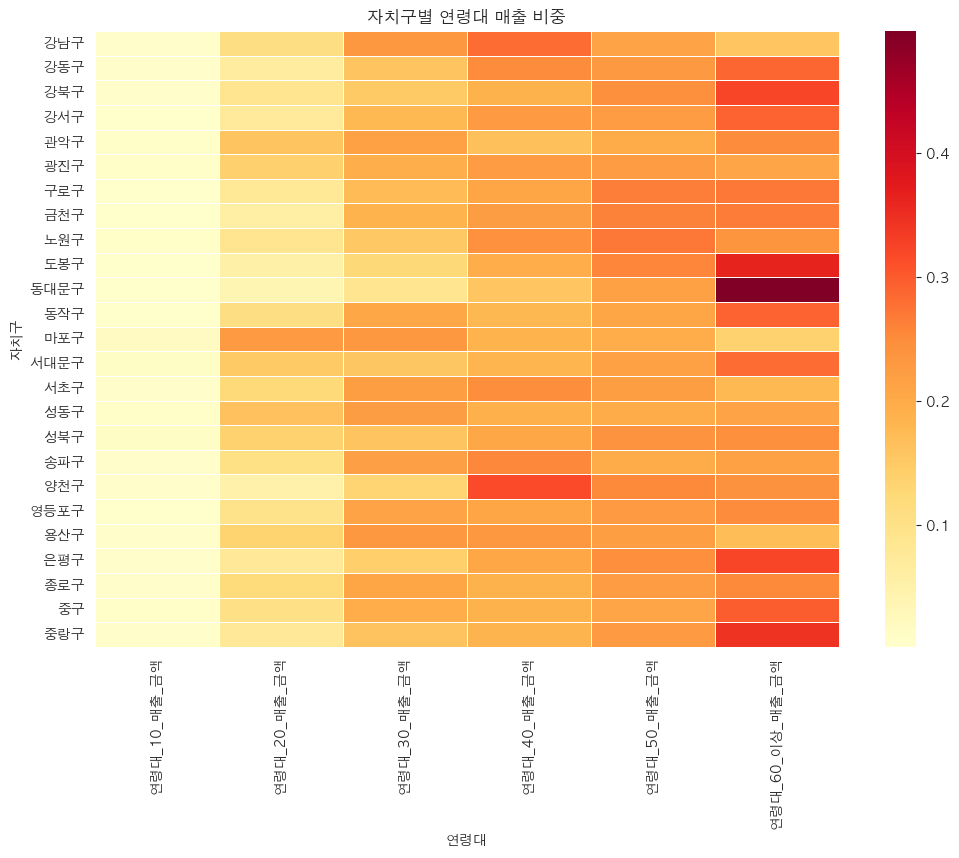

In [20]:

연령컬럼 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
        '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령라벨 = ['10대','20대','30대','40대','50대','60대+']

자치구_연령매출 = (
    최신분기
    .groupby('자치구_코드_명')[연령컬럼]
    .sum()
)

자치구_연령비중 = 자치구_연령매출.div(
    자치구_연령매출.sum(axis=1),
    axis=0
)



import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    자치구_연령비중,
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('자치구별 연령대 매출 비중')
plt.ylabel('자치구')
plt.xlabel('연령대')

plt.show()

In [21]:
# 연령대별 자치구 매출 탑 5
연령컬럼 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
        '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령라벨 = ['10대','20대','30대','40대','50대','60대+']

for 연령, 컬럼 in zip(연령라벨, 연령컬럼):
    상위구 = 최신분기.groupby('자치구_코드_명')[컬럼].sum().nlargest(5).index.tolist()
    print(f'{연령}: {상위구}')

10대: ['마포구', '중구', '강남구', '송파구', '서초구']
20대: ['강남구', '송파구', '중구', '마포구', '서초구']
30대: ['강남구', '송파구', '중구', '동작구', '서초구']
40대: ['강남구', '송파구', '서초구', '중구', '금천구']
50대: ['강남구', '송파구', '중구', '동대문구', '금천구']
60대+: ['동대문구', '중구', '송파구', '동작구', '강남구']


총 인사이트:
유형 A️ 고소득 실무·중산층 중심 (30~40대 중심형)
대표:강남구 서초구 송파구 용산구
강남구 - 30대 23.2 ,  30대 23.2
서초구 - 30대 22.1, 40대 24.9 ,  50대 22.3
송파구 - 30대 22.0, 40대 25.4 ,  60대 21.9
==>경제활동 핵심 연령층 중심 소비 구조
= 고단가 소비 가능 지역
유형 B️ 초고령 소비 중심 생활형 상권
대표:도봉구 서초구 은평구 노원구
도봉구 - 30대 22.0, 40대 25.4 ,  60대 21.9
은평구 - 60대+ 32.4
노원구 - 50대 27.0,  60대 23.8
==>고령층 중심 소비 구조 = 생활밀착형 상권  = 방문형 소비보다 거주형 소비 (지역 기반 소비형 상권)
유형 C️ 관광·업무 중심 혼합형 소비 구조
대표:중구
중구 - 60대+ 29.7 ← 최고, 30대 19.7, 40대 18.9
청년 중심 ❌
중산층 중심 ❌
고령 중심 단순 구조도 ❌
관광 + 업무 + 전통 상권 혼합 소비 구조 (방문형 소비 중심 상권)
유형 D️ 균형형 직주혼합 소비 구조
대표:용산구
용산구 - 20대 13.5
30대 23.5
40대 23.3
50대 22.3
=>(연령 편중 없음
= 유입형 + 거주형 혼합 소비 구조) (서울에서 가장 균형 잡힌 소비 구조 중 하나)

20대 소비 TOP 
청년 소비 중심 지역 = 마포 + 강남축
40대 소비 TOP
경제활동 핵심 소비 중심 = 강남 3구
60대 소비 TOP
중구 반복 등장
전 연령층 소비가 모두 유입되는 지역

총: 자치구별 연령대 매출 비중 분석 결과 서울 상권은 소비 연령 구조에 따라 뚜렷한 유형 차이를 보였다.
강남·서초·송파는 30~40대 중심의 경제활동 핵심 소비 구조가 나타났으며,
마포는 20대 소비 비중이 높은 청년 중심 상권으로 확인되었다.
반면 도봉·은평·노원은 50~60대 비중이 높은 생활밀착형 소비 구조를 보였고,
중구는 전 연령대 소비가 동시에 유입되는 관광·업무 혼합형 방문 소비 중심 상권으로 나타났다.

* 전체연도

In [22]:
매출_영역.head(2)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,수요일_매출_금액,목요일_매출_금액,금요일_매출_금액,토요일_매출_금액,일요일_매출_금액,시간대_00~06_매출_금액,시간대_06~11_매출_금액,시간대_11~14_매출_금액,시간대_14~17_매출_금액,시간대_17~21_매출_금액,시간대_21~24_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액,주중_매출_건수,주말_매출_건수,월요일_매출_건수,화요일_매출_건수,수요일_매출_건수,목요일_매출_건수,금요일_매출_건수,토요일_매출_건수,일요일_매출_건수,시간대_건수~06_매출_건수,시간대_건수~11_매출_건수,시간대_건수~14_매출_건수,시간대_건수~17_매출_건수,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수,객단가,자치구_코드_명,행정동_코드_명,엑스좌표_값,와이좌표_값
0,20201,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,347550588,9320,213752434,133798154,37402850,41524552,47796436,46373613,40654983,63699044,70099110,6117743,2335355,109500466,72362607,128214082,29020335,189979822,90662919,855204,11301258,18673667,52501944,96091232,101219432,6286,3034,1141,1274,1289,1298,1284,1462,1572,30,132,3976,1694,2993,495,5321,2687,32,563,718,1525,2656,2516,"37,290.84",종로구,평창동,196262,456660
1,20201,A,골목상권,3110001,이북5도청사,CS100008,분식전문점,41481623,3326,30952552,10529071,6324005,5253789,7715511,5630513,6028734,7135151,3393920,0,395958,18556824,8009652,14304241,214948,17905191,17720789,214947,7229050,3521758,8531183,10949917,5179122,2556,770,542,429,611,464,510,532,238,0,34,1471,633,1177,11,1380,1516,33,656,339,611,917,339,"12,471.93",종로구,평창동,196262,456660


In [23]:
매출_영역['연도'] = 매출_영역['기준_년분기_코드'].astype(str).str[:4].astype(int)

In [24]:
# 전체 연도 분기로 필터 후 상권 단위 집계

전체_상권집계 = 매출_영역.groupby(
    ['연도','상권_코드','상권_코드_명','상권_구분_코드_명','자치구_코드_명']
).agg(
    총매출=('당월_매출_금액','sum'),
    총건수=('당월_매출_건수','sum'),
    업종수=('서비스_업종_코드','nunique'),
).reset_index()

전체_상권집계['객단가'] = 전체_상권집계['총매출'] / 전체_상권집계['총건수']
전체_상권집계['log_매출'] = np.log10(전체_상권집계['총매출'].clip(lower=1))
전체_상권집계['총매출_억'] = (전체_상권집계['총매출']/1e8).round(1)

print(f'분석 대상 상권: {len(전체_상권집계):,}개')
전체_상권집계.head(5)

분석 대상 상권: 9,464개


,연도,상권_코드,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출,총건수,업종수,객단가,log_매출,총매출_억
0,2020,3001491,이태원 관광특구,관광특구,용산구,267046350630,10075990,37,"26,503.24",11.43,"2,670.50"
1,2020,3001492,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,1041812480128,35976913,51,"28,957.81",12.02,"10,418.10"
2,2020,3001493,동대문패션타운 관광특구,관광특구,중구,348499217126,11815872,38,"29,494.16",11.54,"3,485.00"
3,2020,3001494,종로·청계 관광특구,관광특구,종로구,823128489194,19100338,54,"43,094.97",11.92,"8,231.30"
4,2020,3001495,잠실 관광특구,관광특구,송파구,762236202129,23506931,45,"32,426.02",11.88,"7,622.40"


In [25]:
매출_영역['연도'].unique()

array([2020, 2021, 2022, 2023, 2024, 2025])

In [26]:
전체_상권집계['연도'].unique()

array([2020, 2021, 2022, 2023, 2024, 2025])

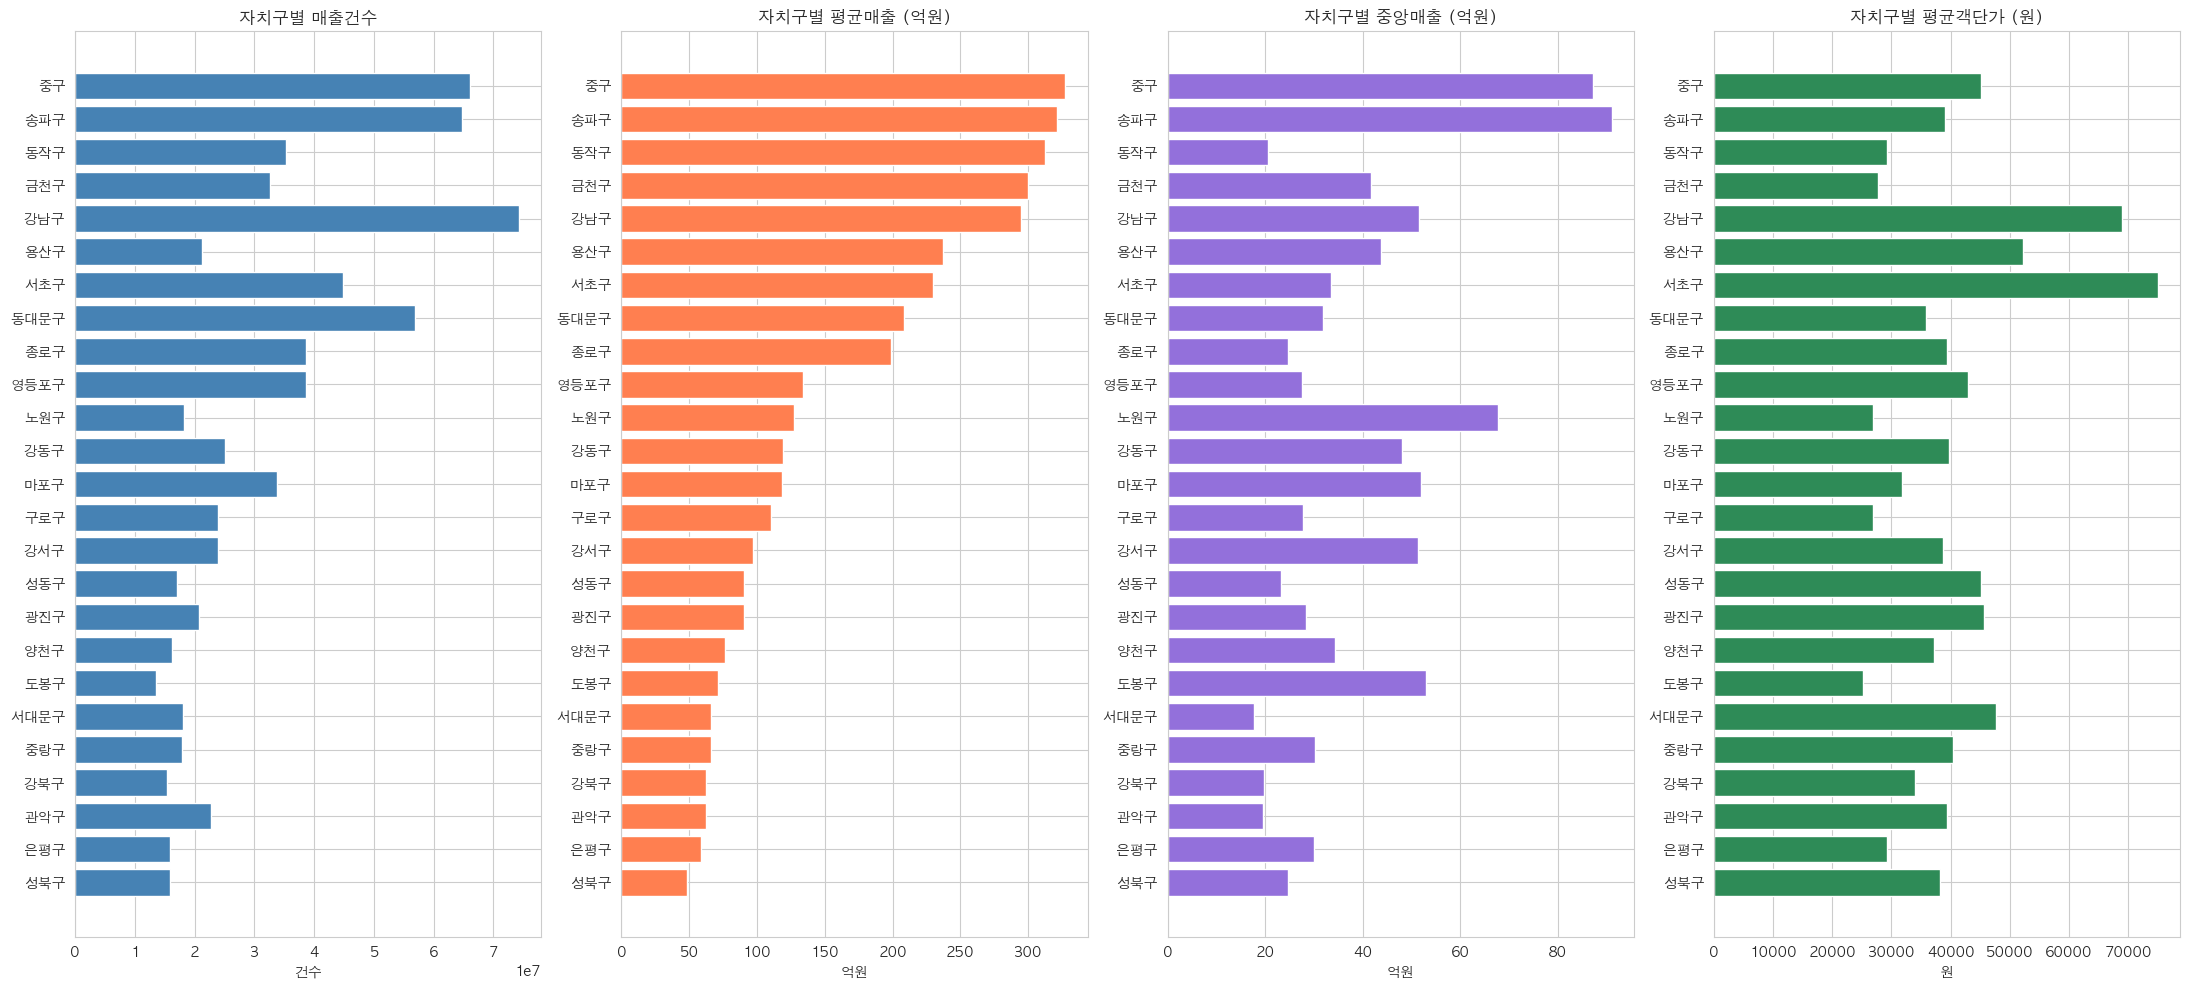

In [27]:

import matplotlib.pyplot as plt
import platform

# 한글 폰트
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 자치구별 집계
구분통계 = 상권집계.groupby('자치구_코드_명').agg(
    매출건수=('총건수', 'sum'),
    평균매출=('총매출', 'mean'),
    중앙매출=('총매출', 'median'),
    평균객단가=('객단가', 'mean')
).reset_index()

구분통계['평균객단가'] = 구분통계['평균객단가'].round(0)

# 평균매출 기준 정렬
구분통계 = 구분통계.sort_values('평균매출', ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(22, 10))

# 1. 매출건수
axes[0].barh(구분통계['자치구_코드_명'], 구분통계['매출건수'], color='steelblue')
axes[0].set_title('자치구별 매출건수')
axes[0].set_xlabel('건수')

# 2. 평균매출
axes[1].barh(구분통계['자치구_코드_명'], 구분통계['평균매출'] / 1e8, color='coral')
axes[1].set_title('자치구별 평균매출 (억원)')
axes[1].set_xlabel('억원')

# 3. 중앙매출
axes[2].barh(구분통계['자치구_코드_명'], 구분통계['중앙매출'] / 1e8, color='mediumpurple')
axes[2].set_title('자치구별 중앙매출 (억원)')
axes[2].set_xlabel('억원')

# 4. 평균객단가
axes[3].barh(구분통계['자치구_코드_명'], 구분통계['평균객단가'], color='seagreen')
axes[3].set_title('자치구별 평균객단가 (원)')
axes[3].set_xlabel('원')

plt.tight_layout()
plt.show()

In [28]:
매출_영역.head(2)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,수요일_매출_금액,목요일_매출_금액,금요일_매출_금액,토요일_매출_금액,일요일_매출_금액,시간대_00~06_매출_금액,시간대_06~11_매출_금액,시간대_11~14_매출_금액,시간대_14~17_매출_금액,시간대_17~21_매출_금액,시간대_21~24_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,...,연령대_60_이상_매출_금액,주중_매출_건수,주말_매출_건수,월요일_매출_건수,화요일_매출_건수,수요일_매출_건수,목요일_매출_건수,금요일_매출_건수,토요일_매출_건수,일요일_매출_건수,시간대_건수~06_매출_건수,시간대_건수~11_매출_건수,시간대_건수~14_매출_건수,시간대_건수~17_매출_건수,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수,객단가,자치구_코드_명,행정동_코드_명,엑스좌표_값,와이좌표_값,연도
0,20201,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,347550588,9320,213752434,133798154,37402850,41524552,47796436,46373613,40654983,63699044,70099110,6117743,2335355,109500466,72362607,128214082,29020335,189979822,90662919,855204,11301258,18673667,52501944,...,101219432,6286,3034,1141,1274,1289,1298,1284,1462,1572,30,132,3976,1694,2993,495,5321,2687,32,563,718,1525,2656,2516,"37,290.84",종로구,평창동,196262,456660,2020
1,20201,A,골목상권,3110001,이북5도청사,CS100008,분식전문점,41481623,3326,30952552,10529071,6324005,5253789,7715511,5630513,6028734,7135151,3393920,0,395958,18556824,8009652,14304241,214948,17905191,17720789,214947,7229050,3521758,8531183,...,5179122,2556,770,542,429,611,464,510,532,238,0,34,1471,633,1177,11,1380,1516,33,656,339,611,917,339,"12,471.93",종로구,평창동,196262,456660,2020


* 자치구별 코로나 이전 이후 매출 성장률(전체연도)

In [29]:
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']
순서 = 선택구

period = (
    매출_영역[
        (매출_영역['자치구_코드_명'].isin(선택구)) &
        (매출_영역['기준_년분기_코드'].isin([20201, 20244]))
    ]
    .groupby(['자치구_코드_명', '기준_년분기_코드'])['당월_매출_금액']
    .sum()
    .unstack()
)

period.columns = ['2020Q1', '2024Q4']
period['성장률(%)'] = ((period['2024Q4'] / period['2020Q1'] - 1) * 100).round(1)
period['2020Q1_조'] = (period['2020Q1'] / 1e12).round(2)
period['2024Q4_조'] = (period['2024Q4'] / 1e12).round(2)

period = period.reindex(순서)

period[['2020Q1_조', '2024Q4_조', '성장률(%)']]

,2020Q1_조,2024Q4_조,성장률(%)
자치구_코드_명,,,
서초구,1.12,1.55,38.00
강남구,2.34,2.87,22.50
용산구,1.49,1.24,-16.40
중구,1.24,1.98,60.20
송파구,1.34,2.19,63.60
노원구,0.41,0.46,12.60
도봉구,0.19,0.27,41.40
은평구,0.27,0.36,33.10


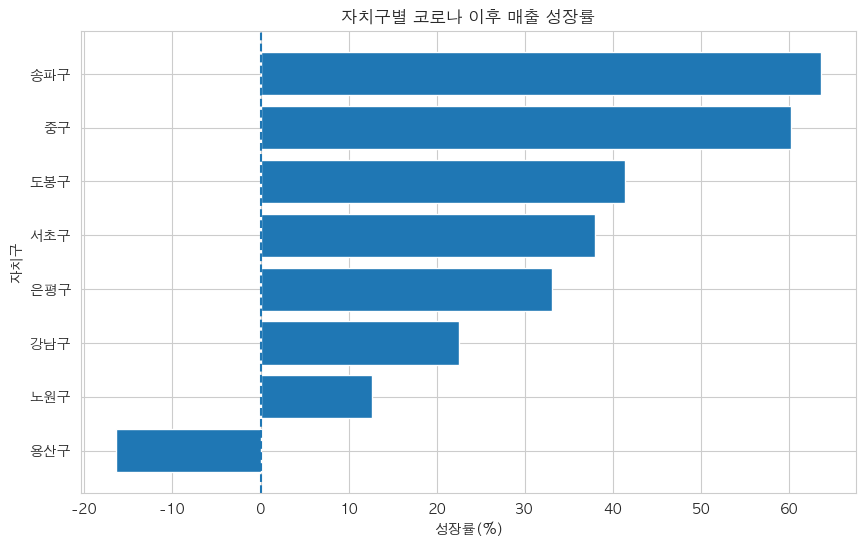

In [30]:
import matplotlib.pyplot as plt

plot_df = period[['성장률(%)']].sort_values('성장률(%)', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df.index, plot_df['성장률(%)'])
plt.axvline(0, linestyle='--')
plt.title('자치구별 코로나 이후 매출 성장률')
plt.xlabel('성장률(%)')
plt.ylabel('자치구')
plt.show()

* 전체 구조 변화 요약

2020년 1분기 대비 2024년 4분기까지 선택된 8개 자치구 중 대부분 지역에서 상권 규모가 증가하였다. 특히 송파구(63.6%)와 중구(60.2%)는 가장 높은 성장률을 기록하며 빠른 상권 확대가 나타났다. 반면 용산구는 선택된 자치구 중 유일하게 상권 규모가 감소한 지역으로 확인된다.
* 가장 빠르게 성장한 지역

송파구는 2020년 1분기 1.34조에서 2024년 4분기 2.19조로 증가하여 63.6%의 성장률을 기록하였다. 중구 역시 1.24조에서 1.98조로 증가하여 60.2%의 높은 성장률을 보였다. 두 지역 모두 절대 규모 증가와 상대 성장률이 동시에 크게 나타난 지역이다.
* 최대 상권 규모 유지 지역

강남구는 2020년 1분기 2.34조에서 2024년 4분기 2.87조로 증가하여 22.5%의 성장률을 기록하였다. 성장률 자체는 다른 일부 지역보다 낮지만 2024년 기준 가장 큰 상권 규모를 유지하고 있다.
* 강남권 내부 성장 속도 차이

서초구는 1.12조에서 1.55조로 증가하여 38.0%의 성장률을 기록하였다. 이는 같은 강남권에 속하는 강남구(22.5%)보다 높은 성장률로, 동일 권역 내에서도 상권 확대 속도의 차이가 존재함을 보여준다.
* 유일한 감소 지역

용산구는 2020년 1분기 1.49조에서 2024년 4분기 1.24조로 감소하여 –16.4%의 성장률을 기록하였다. 이는 선택된 8개 자치구 중 유일하게 상권 규모가 감소한 사례이다.
* 외곽 주거 중심 지역의 성장 확인

노원구(12.6%), 도봉구(41.4%), 은평구(33.1%) 역시 모두 상권 규모 증가가 나타났다. 특히 도봉구는 비교적 높은 성장률을 기록하여 외곽 주거 중심 지역에서도 상권 확대가 발생했음을 확인할 수 있다.
* 초기 규모와 성장률 간 관계

초기 상권 규모가 큰 지역이 항상 높은 성장률을 보인 것은 아니었다. 예를 들어 강남구는 가장 큰 규모를 유지하고 있지만 성장률은 22.5% 수준이며, 송파구와 중구는 상대적으로 더 높은 성장률을 기록함. 이는 상권 초기 규모와 성장률 사이에 단순한 비례 관계가 나타나지 않음을 보여줌.

* 선택구 간 상권 성장 패턴 차이

선택된 자치구 간 상권 규모 변화는 동일한 방향으로 나타나지 않았다. 일부 지역은 빠른 성장(송파구, 중구), 일부 지역은 안정적 성장(강남구, 서초구), 일부 지역은 감소(용산구) 등 서로 다른 변화 양상이 확인된다. 이는 동일 기간 동안에도 지역별 상권 성장 흐름에 차이가 존재함을 보여준다.


In [31]:
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']
매출_영역['연도'] = 매출_영역['기준_년분기_코드']//10

연도별_자치구 = (
    매출_영역[매출_영역['자치구_코드_명'].isin(선택구)]
    .groupby(['연도', '자치구_코드_명'])['당월_매출_금액']
    .sum()
    .unstack() / 1e12
)

연도별_자치구 = 연도별_자치구[선택구]
연도별_자치구.round(2)

자치구_코드_명,서초구,강남구,용산구,중구,송파구,노원구,도봉구,은평구
연도,,,,,,,,
2020,4.52,9.90,6.13,5.18,5.69,1.69,0.81,1.17
2021,5.32,10.84,5.98,6.04,7.03,1.62,0.99,1.42
2022,5.77,11.60,5.47,6.54,6.37,1.74,1.04,1.46
2023,6.12,11.68,5.01,7.23,7.71,1.87,1.06,1.52
2024,6.11,11.36,4.72,7.59,8.62,1.84,1.06,1.45
2025,6.06,11.14,4.65,7.85,8.54,1.82,1.06,1.43


<Figure size 1200x600 with 0 Axes>

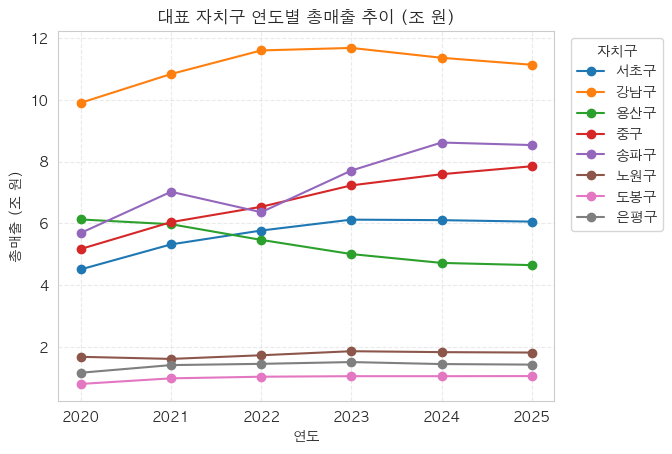

In [32]:
#기본 추이
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

연도별_자치구.plot(marker='o')

plt.title('대표 자치구 연도별 총매출 추이 (조 원)')
plt.xlabel('연도')
plt.ylabel('총매출 (조 원)')
plt.xticks(rotation=0)

plt.legend(title='자치구', bbox_to_anchor=(1.02,1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

<Figure size 1200x600 with 0 Axes>

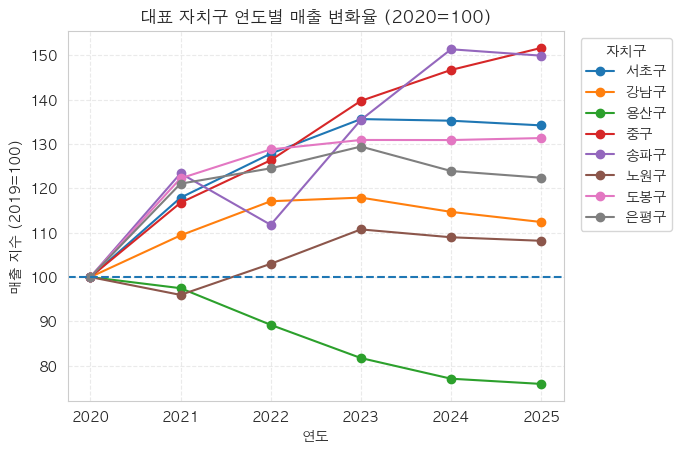

In [33]:
#회복 속도 비교용
연도별_indexed = 연도별_자치구 / 연도별_자치구.loc[2020] * 100

plt.figure(figsize=(12,6))

연도별_indexed.plot(marker='o')

plt.title('대표 자치구 연도별 매출 변화율 (2020=100)')
plt.xlabel('연도')
plt.ylabel('매출 지수 (2019=100)')
plt.xticks(rotation=0)

plt.axhline(100, linestyle='--')

plt.legend(title='자치구', bbox_to_anchor=(1.02,1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

그룹 A️ 안정적 성장형 (강남·서초·송파)
특징:
2020 → 2023까지 꾸준한 상승
이후 완만한 정체 또는 안정화
예:
강남: 9.90 → 11.68 → 11.14
서초: 4.52 → 6.12 → 6.06
송파: 5.69 → 7.71 → 8.54
=>코로나 이후 빠르게 회복하고 고점 유지하는 “핵심 소비 중심 상권” (서울의 프리미엄 소비축)

그룹 B️ 반등형 (중구)
특징:
가장 강한 회복 흐름
꾸준한 상승 추세 지속
다른 구는 대부분 2023 이후 정체인데
중구는 계속 상승 중
예:
5.18 → 6.04 → 6.54 → 7.23 → 7.85
=>관광·업무 중심 방문형 소비가 코로나 이후 가장 강하게 회복된 지역(서울에서 코로나 영향 가장 컸지만 회복도 가장 강했던 상권)

그룹 C️ 생활형 안정 유지형 (노원·도봉·은평)
특징:
변화폭 작음
외부 유입보다 지역 거주 기반 소비 중심 상권
예:
노원: 1.69 → 1.87 → 1.82
도봉: 0.81 → 1.06 → 1.06
은평: 1.17 → 1.52 → 1.43
=>생활밀착형 상권은 코로나 영향도 작고 회복 변동도 작음

+ 용산구는 "유일한 감소형"
6.13 → 5.98 → 5.47 → 5.01 → 4.72 → 4.65
계속감소중
=>문형 소비 중심 구조 변화 또는 상권 구조 재편 진행 가능성(서울 주요 자치구 중 유일한 구조적 감소 패턴)
+송파구 "조용하지만 강한 성장형"
특징:
2022 잠깐 하락
이후 최고 수준 성장
해석:
거주형 + 대형 상업시설 결합 구조 (강남 다음으로 안정적인 성장형 소비 중심 지역)
+강남 "이미 큰시장인데 더 커진지역"
이미 서울 최대시장인데 또 성장
=> 서울소비 중심축 구조적 강화 (코로나이후 소비집중현상)
요약:
자치구별 연도별 매출 추이를 비교한 결과 서울 상권은 회복 경로에 따라 세 가지 유형으로 구분되었다.
강남·서초·송파는 코로나 이후 빠르게 회복한 안정적 성장형 소비 구조를 보였으며,
중구는 관광·업무 중심 상권 특성에 따라 가장 강한 반등 흐름이 나타났다.
반면 노원·도봉·은평 등 생활밀착형 상권은 변화폭이 작고 안정적인 소비 구조를 유지하였다.
특히 용산구는 주요 자치구 중 유일하게 지속적인 감소 흐름을 보여 상권 구조 변화 가능성이 확인되었다.

---

# 상권변화 지표

In [34]:
from pathlib import Path
import pandas as pd

csv_file = list(Path("data").rglob("*상권변화지표*.csv"))[0]

df = pd.read_csv(csv_file, encoding="cp949")

print(csv_file)
print(f"✅ 로드 완료: {df.shape}")

data/extracted/서울시 상권분석서비스(상권변화지표-상권)/서울시 상권분석서비스(상권변화지표-상권).csv
✅ 로드 완료: (46200, 11)


In [35]:
area

,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,엑스좌표_값,와이좌표_값,자치구_코드,자치구_코드_명,행정동_코드,행정동_코드_명,영역_면적
0,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264
1,A,골목상권,3110009,자하문터널,196991,455057,11110,종로구,11110550,부암동,178306
2,A,골목상권,3110010,평창동서측,197064,456643,11110,종로구,11110560,평창동,369415
3,A,골목상권,3110017,정독도서관,198581,453781,11110,종로구,11110600,가회동,83855
4,A,골목상권,3110018,중앙고등학교,198883,453690,11110,종로구,11110600,가회동,166872
...,...,...,...,...,...,...,...,...,...,...,...
1645,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,198397,451614,11140,중구,11140520,소공동,983618
1646,U,관광특구,3001493,동대문패션타운 관광특구,200996,451976,11140,중구,11140590,광희동,606058
1647,U,관광특구,3001494,종로?청계 관광특구,199796,452274,11110,종로구,11110615,종로1?2?3?4가동,653127
1648,U,관광특구,3001495,잠실 관광특구,210188,446334,11710,송파구,11710562,방이2동,2462734


In [ ]:
# 영역 정보 merge
매출_영역 = sales.merge(
    area[['상권_코드','자치구_코드_명','행정동_코드_명','엑스좌표_값','와이좌표_값']],
    on='상권_코드', how='left'
)
print(f'merge 후: {매출_영역.shape}')
print(f'결측 자치구: {매출_영역["자치구_코드_명"].isna().sum()}')

merge 후: (519931, 60)
결측 자치구: 0


In [36]:
df.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '상권_변화_지표',
       '상권_변화_지표_명', '운영_영업_개월_평균', '폐업_영업_개월_평균', '서울_운영_영업_개월_평균',
       '서울_폐업_영업_개월_평균'],
      dtype='str')

In [37]:
상권_통합 = area.merge(
    df[['기준_년분기_코드','상권_코드','상권_변화_지표_명','운영_영업_개월_평균','폐업_영업_개월_평균','서울_운영_영업_개월_평균','서울_폐업_영업_개월_평균']],
    on='상권_코드',
    how='left'
)

상권_통합.head(2)

,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,엑스좌표_값,와이좌표_값,자치구_코드,자치구_코드_명,행정동_코드,행정동_코드_명,영역_면적,기준_년분기_코드,상권_변화_지표_명,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균
0,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264,20254,다이나믹,88,53,115,53
1,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264,20253,다이나믹,86,52,113,53


In [38]:
상권_통합['기준_년분기_코드'].unique()

array([20254, 20253, 20252, 20251, 20244, 20243, 20242, 20241, 20234,
       20233, 20232, 20231, 20224, 20223, 20222, 20221, 20214, 20213,
       20212, 20211, 20204, 20203, 20202, 20201, 20194, 20193, 20192,
       20191])

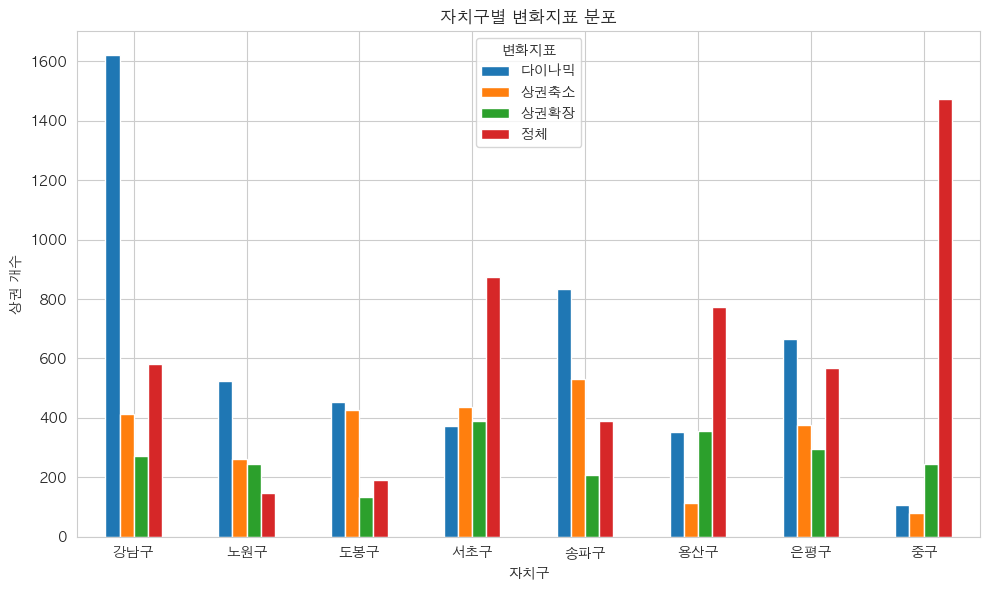

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

# 선택 자치구만 필터링
filtered = 상권_통합[
    상권_통합['자치구_코드_명'].isin(선택구)
]

# 자치구별 변화지표 개수 계산
pivot = (
    filtered
    .groupby(['자치구_코드_명', '상권_변화_지표_명'])
    .size()
    .unstack()
)

# 막대 그래프
pivot.plot(kind='bar', ax=ax)

ax.set_title('자치구별 변화지표 분포')
ax.set_xlabel('자치구')
ax.set_ylabel('상권 개수')
ax.legend(title='변화지표')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

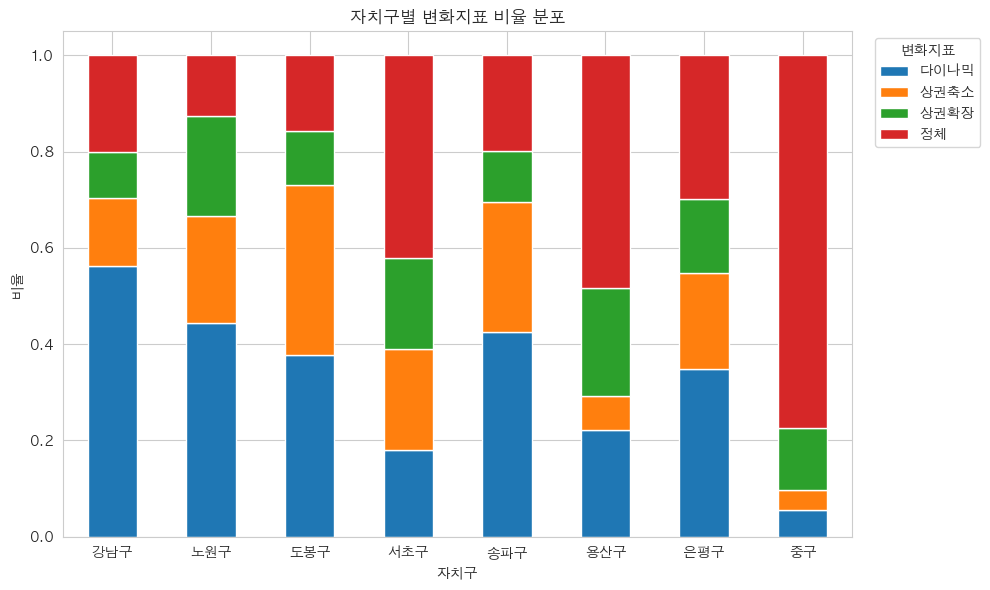

In [40]:
pivot_ratio = pivot.div(pivot.sum(axis=1), axis=0)

pivot_ratio.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('자치구별 변화지표 비율 분포')
plt.xlabel('자치구')
plt.ylabel('비율')
plt.legend(title='변화지표', bbox_to_anchor=(1.02,1))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

전체 구조 요약

선택된 8개 자치구 모두에서 상권 변화 유형의 분포 패턴이 서로 다르게 나타난다.
특히 일부 자치구는 특정 변화 유형이 다른 유형보다 매우 크게 나타나 상권 변화 구조의 차이가 존재함을 확인할 수 있다.

강남구: 다이나믹 유형 최다
강남구에서는 다이나믹 유형이 가장 많이 나타난 변화 유형이다.
또한 정체·상권축소·상권확장보다 다이나믹 유형의 빈도가 가장 크게 나타난다.

노원구: 다이나믹 중심 구조
노원구에서도 다이나믹 유형이 가장 많이 나타난 변화 유형이다.
정체 유형은 상대적으로 가장 적게 나타난다.

도봉구: 상권축소와 다이나믹이 동시에 높은 구조
도봉구에서는 다이나믹 유형과 상권축소 유형의 빈도가 유사하게 높게 나타난다.
상권확장 유형은 가장 적은 비중을 차지한다.

서초구: 정체 유형 최다
서초구에서는 정체 유형이 가장 많이 나타난 변화 유형이다.
다른 세 유형보다 정체 유형이 가장 높은 빈도를 보인다.

송파구: 다이나믹 중심 구조
송파구에서는 다이나믹 유형이 가장 많이 나타난 변화 유형이다.
상권확장 유형은 상대적으로 가장 적게 나타난다.

용산구: 정체와 상권확장이 함께 높은 구조
용산구에서는 정체 유형이 가장 많이 나타난 변화 유형이다.
상권확장과 다이나믹 유형의 빈도는 유사한 수준으로 나타난다.

은평구: 다이나믹과 정체 중심 구조
은평구에서는 다이나믹 유형이 가장 많이 나타난 변화 유형이며, 정체 유형도 비교적 높은 빈도로 나타난다.

중구: 정체 유형 압도적 우세
중구에서는 정체 유형이 다른 모든 유형보다 매우 크게 나타난다.
특히 다이나믹과 상권축소 유형은 상대적으로 낮은 빈도로 나타난다.

In [41]:
# 연도 생성
상권_통합['연도'] = 상권_통합['기준_년분기_코드'] // 10

# 선택 자치구
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

상권_통합_filtered = 상권_통합[상권_통합['자치구_코드_명'].isin(선택구)]

# 전체 상권 개수
total = 상권_통합_filtered.groupby(['연도','자치구_코드_명']).size()

# 축소 상권 개수
축소 = 상권_통합_filtered[상권_통합_filtered['상권_변화_지표_명'] == '상권축소'] \
        .groupby(['연도','자치구_코드_명']).size()

# 비율 계산
축소_비율 = (축소 / total * 100).unstack()

축소_비율_T = 축소_비율.T.round(2)
print(축소_비율_T)

연도        2019  2020  2021  2022  2023  2024  2025
자치구_코드_명                                          
강남구      13.83 14.81 15.78 14.08 16.02 12.38 13.11
노원구      23.21 26.79 25.00 22.62 25.60 15.48 16.07
도봉구      33.72 37.79 36.63 37.79 35.47 33.72 31.98
서초구      22.97 23.65 24.32 21.62 20.61 17.23 17.57
송파구      25.00 27.14 29.29 28.93 27.86 27.86 23.21
용산구       6.14  7.46  8.33  9.65  7.89  6.58  4.39
은평구      25.74 25.00 23.53 16.91 19.12 14.71 13.60
중구        4.04  6.25  6.99  3.31  4.04  2.94  1.84


<Figure size 1200x600 with 0 Axes>

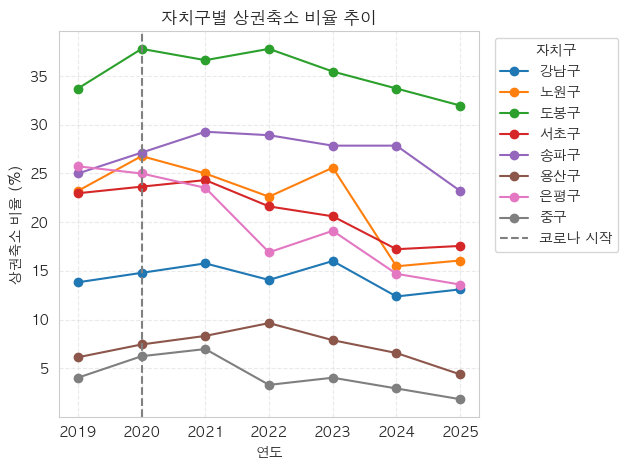

In [42]:
import matplotlib.pyplot as plt

# 연도 생성
상권_통합['연도'] = 상권_통합['기준_년분기_코드'] // 10

# 선택 자치구
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

상권_통합_filtered = 상권_통합[상권_통합['자치구_코드_명'].isin(선택구)]

# 전체 상권 개수
total = 상권_통합_filtered.groupby(['연도','자치구_코드_명']).size()

# 축소 상권 개수
축소 = 상권_통합_filtered[상권_통합_filtered['상권_변화_지표_명'] == '상권축소'] \
        .groupby(['연도','자치구_코드_명']).size()

# 비율 계산
축소_비율 = (축소 / total * 100).unstack()

# 그래프
plt.figure(figsize=(12,6))

축소_비율.plot(marker='o')

plt.axvline(x=2020, linestyle='--', color='gray', label='코로나 시작')

plt.title('자치구별 상권축소 비율 추이')
plt.xlabel('연도')
plt.ylabel('상권축소 비율 (%)')

plt.legend(title='자치구', bbox_to_anchor=(1.02,1))
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

상권축소 비율이 가장 높은 지역: 도봉구
도봉구는 모든 연도에서 다른 자치구보다 높은 수준의 상권축소 비율이 나타난 지역

상권축소 비율이 가장 낮은 지역: 중구
중구는 선택된 자치구 중 가장 낮은 수준의 상권축소 비율이 지속적으로 나타난 지역

=>선택된 8개 자치구 모두에서 2019년 대비 2025년 기준 상권축소 비율이 감소함

감소폭 큰 지역
은평, 노원, 서초, 송파, 강남
-> 은평 과 노원은 다른 자치구보다 상대적 큰 감소폭이 나타난 지역

기간 중 가장 높은 상권축소 비율이 나타난 시점
도봉구 : 20년 22년
송파구 : 21년
노원구 : 20년
서초구 : 21년
강남구 : 23년
->일부 자치구에서는 2020년 또는 2021년 시기에 상대적으로 높은 상권축소 비율이 나타남.

전체기간동안 낮은 수준의 유지 지역: 중구, 용산

지역간 구조적 차이 
도봉구 약 30%  vs 중구 약 2~7%

요약:
2019년부터 2025년까지 자치구별 상권축소 비율을 비교한 결과, 모든 선택 자치구에서 상권축소 비율이 전반적으로 감소하는 흐름이 나타났다. 특히 은평구와 노원구는 감소폭이 크게 나타났으며, 도봉구는 전체 기간 동안 가장 높은 상권축소 비율을 유지한 반면 중구와 용산구는 지속적으로 낮은 수준을 유지하였다. 

In [43]:
# 연도 생성
상권_통합['연도'] = 상권_통합['기준_년분기_코드'] // 10

# 선택 자치구
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

상권_통합_filtered = 상권_통합[상권_통합['자치구_코드_명'].isin(선택구)]

# 전체 상권 개수
total = 상권_통합_filtered.groupby(['연도','자치구_코드_명']).size()

# 확장 상권 개수
확장 = 상권_통합_filtered[상권_통합_filtered['상권_변화_지표_명'] == '상권확장'] \
        .groupby(['연도','자치구_코드_명']).size()

# 비율 계산
확장_비율 = (확장 / total * 100).unstack()

확장_비율_T = 확장_비율.T.round(2)
print(확장_비율_T)

연도        2019  2020  2021  2022  2023  2024  2025
자치구_코드_명                                          
강남구      13.35 10.19  7.52  7.52  7.04  9.47 10.92
노원구      18.45 19.64 19.64 17.26 20.83 28.57 21.43
도봉구      11.63 15.12  9.30  8.72  6.98 10.47 16.28
서초구      19.59 18.92 15.88 15.88 17.91 22.30 20.61
송파구      17.86 17.14 10.36  6.79  5.71  7.86  8.57
용산구      22.37 21.93 16.67 21.05 24.12 25.44 24.56
은평구      18.38 17.65 18.38 15.07 12.50 13.97 12.13
중구       18.01 15.44 13.97 13.60 11.03 10.66  7.72


<Figure size 1200x600 with 0 Axes>

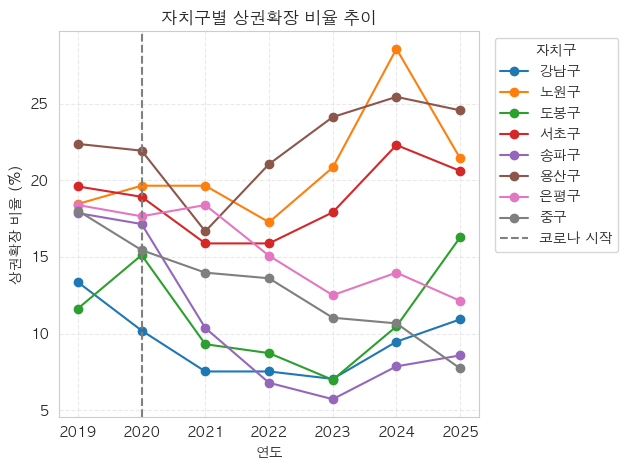

In [44]:
import matplotlib.pyplot as plt

# 연도 생성
상권_통합['연도'] = 상권_통합['기준_년분기_코드'] // 10

# 선택 자치구
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

상권_통합_filtered = 상권_통합[상권_통합['자치구_코드_명'].isin(선택구)]

# 전체 상권 개수
total = 상권_통합_filtered.groupby(['연도','자치구_코드_명']).size()

# 확장 상권 개수
확장 = 상권_통합_filtered[상권_통합_filtered['상권_변화_지표_명'] == '상권확장'] \
        .groupby(['연도','자치구_코드_명']).size()

# 비율 계산
확장_비율 = (확장 / total * 100).unstack()

# 그래프
plt.figure(figsize=(12,6))

확장_비율.plot(marker='o')

plt.axvline(x=2020, linestyle='--', color='gray', label='코로나 시작')

plt.title('자치구별 상권확장 비율 추이')
plt.xlabel('연도')
plt.ylabel('상권확장 비율 (%)')

plt.legend(title='자치구', bbox_to_anchor=(1.02,1))
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

상권확장 비율 인사이트:
많은 구들이 21~23구간에서 약해졌다가 24~25구간에서 회복조짐을 보임.
=>확장비율을 보면 대부분 자치구에서 2021년부터 2023년 사이 감소 흐름이 나타났고, 2024년 이후 일부 지역에서는 다시 회복되는 움직임이 보임.

용산구 - 높은 확장비율권. 장기적으로 확장성이 강한 지역.
서초구 - 높은 확장비율 유지, 최근 상승흐름. 회복된 안정적인 지역.
도봉구+ 노원구 - 최근 확장비율 폭이 가장 큼. 확장움직임 상대적으로 활발한 지역.
송파구 - 확장비율 감소폭이 가장큼. 회복도 제한적. 회복 불가중.
중구 + 은평구 - 지속적인 확장비율 감소중.

In [45]:
# 선택 자치구
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

# 선택구만 필터링
상권_통합_filtered = 상권_통합[상권_통합['자치구_코드_명'].isin(선택구)]

# 자치구별 평균 계산
평균 = 상권_통합_filtered.groupby('자치구_코드_명')[
    ['운영_영업_개월_평균', '폐업_영업_개월_평균']
].mean()

# 순서 맞추기 (보기 좋게)
평균 = 평균.loc[선택구]
평균

,운영_영업_개월_평균,폐업_영업_개월_평균
자치구_코드_명,,
서초구,109.28,52.78
강남구,96.24,48.37
용산구,105.32,55.24
중구,121.72,60.31
송파구,101.25,49.48
노원구,98.18,48.91
도봉구,100.72,47.99
은평구,102.62,51.36


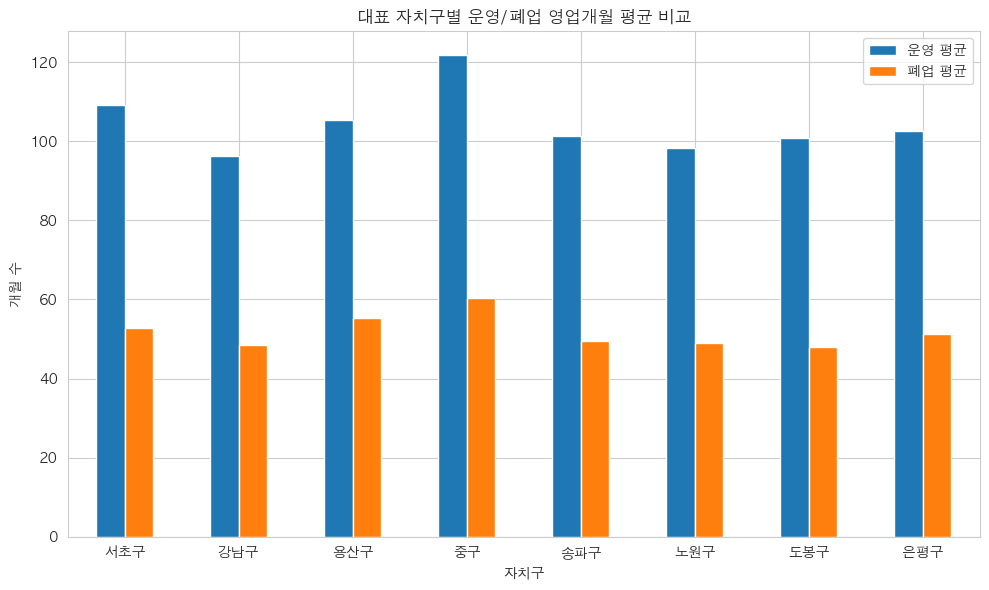

In [46]:
import matplotlib.pyplot as plt

# 선택 자치구
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

# 선택구만 필터링
상권_통합_filtered = 상권_통합[상권_통합['자치구_코드_명'].isin(선택구)]

# 자치구별 평균 계산
평균 = 상권_통합_filtered.groupby('자치구_코드_명')[
    ['운영_영업_개월_평균', '폐업_영업_개월_평균']
].mean()

# 순서 맞추기 (보기 좋게)
평균 = 평균.loc[선택구]

# 그래프
fig, ax = plt.subplots(figsize=(10, 6))

평균.plot(kind='bar', ax=ax)

ax.set_title('대표 자치구별 운영/폐업 영업개월 평균 비교')
ax.set_xlabel('자치구')
ax.set_ylabel('개월 수')

ax.legend(['운영 평균', '폐업 평균'])

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

자치구별 평ㄱ균 영업개월 인사이트
운영 점포 평균 영업기간 전체적으로 8-10년 수준
폐업 점포 평균 영업기간 전체적 4-5년 수준
-> 단기 폐업보단 일정기간 운영후 폐업구조

+장기운영 점포 비중 높음 -> 용산 , 서초
+ 운영 폐업 모두 낮음. -> 강납
+모든 자치구에서 운영 점포가 폐업 점포보다 더 오래 유지됨

자치구별 운영 영업개월 평균과 폐업 영업개월 평균을 비교한 결과 자치구별 상권 유지 구조에서 차이가 나타났다.

중구는 운영 영업개월 평균과 폐업 영업개월 평균이 모두 가장 높게 나타나 다른 자치구 대비 점포 유지 기간이 가장 긴 상권 구조를 보였다. 이는 점포 교체 속도가 상대적으로 낮은 안정적인 상권 구조로 해석된다.

서초구 역시 운영 영업개월 평균이 비교적 높은 수준으로 나타나 점포 유지 기간이 긴 안정형 상권 특성을 보였다.

반면 강남구는 운영 영업개월 평균과 폐업 영업개월 평균이 상대적으로 낮게 나타나 다른 자치구 대비 점포 교체 속도가 빠른 구조로 나타났다.

송파구는 운영 영업개월 평균과 폐업 영업개월 평균이 중간 수준으로 나타나 안정성과 변화가 함께 나타나는 상권 구조로 해석된다.

노원구, 도봉구, 은평구는 운영 영업개월 평균과 폐업 영업개월 평균이 서로 유사한 수준으로 나타났으며 전반적으로 큰 변동 없이 안정적인 상권 유지 구조를 보였다.

##  직장인구/상주인구

In [55]:
from pathlib import Path
import zipfile
import shutil

# 프로젝트 루트 감지
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 경로 설정
target_dir = project_root / 'data' / '06_직장인구'
csv_path = target_dir / '서울시 상권분석서비스(직장인구-상권).csv'

# CSV 없으면 raw/ 에서 zip 찾아서 압축 해제
if not csv_path.exists():
    print('📦 CSV 없음, zip 파일 찾는 중...')
    raw_dir = project_root.parent / 'data' / 'raw'
    
    # 직장인구 관련 zip 찾기
    zip_files = list(raw_dir.glob('*직장인구*.zip'))
    if not zip_files:
        raise FileNotFoundError(f'{raw_dir} 에 직장인구 zip 없음')
    
    zip_path = zip_files[0]
    print(f'  압축 해제: {zip_path.name}')
    target_dir.mkdir(parents=True, exist_ok=True)
    
    # Mac zip의 한글 파일명 문제 해결
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            if info.filename.startswith('__MACOSX'):
                continue
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except:
                filename = info.filename
            
            if info.is_dir():
                continue
            
            out_path = target_dir / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)

# CSV 로드
df_직장 = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 직장인구 로드 완료: {df_직장.shape}')

📦 CSV 없음, zip 파일 찾는 중...
  압축 해제: 서울시 상권분석서비스(직장인구-상권).zip
✅ 직장인구 로드 완료: (45840, 26)


In [56]:
상권_통합.head(2)

,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,엑스좌표_값,와이좌표_값,자치구_코드,자치구_코드_명,행정동_코드,행정동_코드_명,영역_면적,기준_년분기_코드,상권_변화_지표_명,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균,연도
0,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264,20254,다이나믹,88,53,115,53,2025
1,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264,20253,다이나믹,86,52,113,53,2025


In [57]:
df_직장.head(2)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_직장_인구_수,남성_직장_인구_수,여성_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,연령대_30_직장_인구_수,연령대_40_직장_인구_수,연령대_50_직장_인구_수,연령대_60_이상_직장_인구_수,남성연령대_10_직장_인구_수,남성연령대_20_직장_인구_수,남성연령대_30_직장_인구_수,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수
0,20254,U,관광특구,3001496,강남 마이스 관광특구,102032,68834,33198,260,20558,30594,27320,18116,5184,128,11046,20220,20142,14200,3098,132,9512,10374,7178,3916,2086
1,20254,U,관광특구,3001495,잠실 관광특구,137602,81307,56295,247,22732,36053,35461,30321,12788,95,11243,22723,22594,16132,8520,152,11489,13330,12867,14189,4268


In [58]:
상권_통합[['상권_코드','기준_년분기_코드']].dtypes
df_직장[['상권_코드','기준_년분기_코드']].dtypes

상권_코드        int64
기준_년분기_코드    int64
dtype: object

In [59]:
직장_상권_통합 = 상권_통합.merge(
    df_직장,
    on=['상권_코드', '기준_년분기_코드'],
    how='left'
)

In [61]:
missing_rows = 직장_상권_통합[직장_상권_통합['총_직장_인구_수'].isna()]

missing_rows[['기준_년분기_코드', '상권_코드', '상권_코드_명_x', '자치구_코드_명']].head(20)

,기준_년분기_코드,상권_코드,상권_코드_명_x,자치구_코드_명
4129,20223,3110145,장안초등학교,광진구
4130,20222,3110145,장안초등학교,광진구
4131,20221,3110145,장안초등학교,광진구
4132,20214,3110145,장안초등학교,광진구
4133,20213,3110145,장안초등학교,광진구
4134,20212,3110145,장안초등학교,광진구
4135,20211,3110145,장안초등학교,광진구
4136,20204,3110145,장안초등학교,광진구
5824,20254,3110205,경희대삼거리,동대문구
5825,20253,3110205,경희대삼거리,동대문구


In [62]:
missing_rows['기준_년분기_코드'].value_counts().sort_index()

기준_년분기_코드
20191    13
20192    13
20193    13
20194    13
20201    13
20202    13
20203    13
20204    14
20211    14
20212    14
20213    14
20214    15
20221    15
20222    15
20223    15
20224    13
20231    13
20232    13
20233    13
20234    14
20241    14
20242    14
20243    14
20244     9
20251     9
20252     9
20253     9
20254     9
Name: count, dtype: int64

In [63]:
missing_rows['상권_구분_코드_명_x'].value_counts()

상권_구분_코드_명_x
전통시장    278
골목상권     54
발달상권     28
Name: count, dtype: int64

* merge 
-> 1프로미만 : 양호
전통시장 ->직장인인구 데이터에서 자연스러운 구조.
분기별 누락패턴이 "균등함" 모든분기에서 9~15개 수준 -> 특정 상권코드 자체가 직장인구 데이터에 존재하지 않는 구조

In [64]:
직장_상권_통합.groupby('상권_변화_지표_명')[
    ['연령대_20_직장_인구_수',
     '연령대_30_직장_인구_수',
     '연령대_40_직장_인구_수']
].mean()
직장_상권_통합

,상권_구분_코드_x,상권_구분_코드_명_x,상권_코드,상권_코드_명_x,엑스좌표_값,와이좌표_값,자치구_코드,자치구_코드_명,행정동_코드,행정동_코드_명,영역_면적,기준_년분기_코드,상권_변화_지표_명,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균,연도,상권_구분_코드_y,상권_구분_코드_명_y,상권_코드_명_y,총_직장_인구_수,남성_직장_인구_수,여성_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,연령대_30_직장_인구_수,연령대_40_직장_인구_수,연령대_50_직장_인구_수,연령대_60_이상_직장_인구_수,남성연령대_10_직장_인구_수,남성연령대_20_직장_인구_수,남성연령대_30_직장_인구_수,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수
0,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264,20254,다이나믹,88,53,115,53,2025,A,골목상권,배화여자대학교(박노수미술관),"1,536.00",979.00,557.00,0.00,247.00,444.00,445.00,287.00,113.00,0.00,104.00,276.00,318.00,205.00,76.00,0.00,143.00,168.00,127.00,82.00,37.00
1,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264,20253,다이나믹,86,52,113,53,2025,A,골목상권,배화여자대학교(박노수미술관),"1,536.00",979.00,557.00,0.00,247.00,444.00,445.00,287.00,113.00,0.00,104.00,276.00,318.00,205.00,76.00,0.00,143.00,168.00,127.00,82.00,37.00
2,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264,20252,다이나믹,84,52,112,53,2025,A,골목상권,배화여자대학교(박노수미술관),"1,536.00",979.00,557.00,0.00,247.00,444.00,445.00,287.00,113.00,0.00,104.00,276.00,318.00,205.00,76.00,0.00,143.00,168.00,127.00,82.00,37.00
3,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264,20251,다이나믹,82,52,111,52,2025,A,골목상권,배화여자대학교(박노수미술관),"1,536.00",979.00,557.00,0.00,247.00,444.00,445.00,287.00,113.00,0.00,104.00,276.00,318.00,205.00,76.00,0.00,143.00,168.00,127.00,82.00,37.00
4,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264,20244,다이나믹,81,51,109,52,2024,A,골목상권,배화여자대학교(박노수미술관),"1,536.00",979.00,557.00,0.00,247.00,444.00,445.00,287.00,113.00,0.00,104.00,276.00,318.00,205.00,76.00,0.00,143.00,168.00,127.00,82.00,37.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46195,U,관광특구,3001496,강남 마이스 관광특구,205282,445736,11680,강남구,11680580,삼성1동,237892,20201,상권확장,88,60,92,48,2020,U,관광특구,강남 마이스 관광특구,"79,184.00","53,440.00","25,744.00",188.00,"15,954.00","23,746.00","21,212.00","14,056.00","4,028.00",94.00,"8,574.00","15,696.00","15,648.00","11,020.00","2,408.00",94.00,"7,380.00","8,050.00","5,564.00","3,036.00","1,620.00"
46196,U,관광특구,3001496,강남 마이스 관광특구,205282,445736,11680,강남구,11680580,삼성1동,237892,20194,상권확장,88,60,92,48,2019,U,관광특구,강남 마이스 관광특구,"79,184.00","53,440.00","25,744.00",188.00,"15,954.00","23,746.00","21,212.00","14,056.00","4,028.00",94.00,"8,574.00","15,696.00","15,648.00","11,020.00","2,408.00",94.00,"7,380.00","8,050.00","5,564.00","3,036.00","1,620.00"
46197,U,관광특구,3001496,강남 마이스 관광특구,205282,445736,11680,강남구,11680580,삼성1동,237892,20193,상권확장,88,60,92,48,2019,U,관광특구,강남 마이스 관광특구,"79,184.00","53,440.00","25,744.00",188.00,"15,954.00","23,746.00","21,212.00","14,056.00","4,028.00",94.00,"8,574.00","15,696.00","15,648.00","11,020.00","2,408.00",94.00,"7,380.00","8,050.00","5,564.00","3,036.00","1,620.00"
46198,U,관광특구,3001496,강남 마이스 관광특구,205282,445736,11680,강남구,11680580,삼성1동,237892,20192,상권확장,91,59,93,49,2019,U,관광특구,강남 마이스 관광특구,"79,184.00","53,440.00","25,744.00",188.00,"15,954.00","23,746.00","21,212.00","14,056.00","4,028.00",94.00,"8,574.00","15,696.00","15,648.00","11,020.00","2,408.00",94.00,"7,380.00","8,050.00","5,564.00","3,036.00","1,620.00"


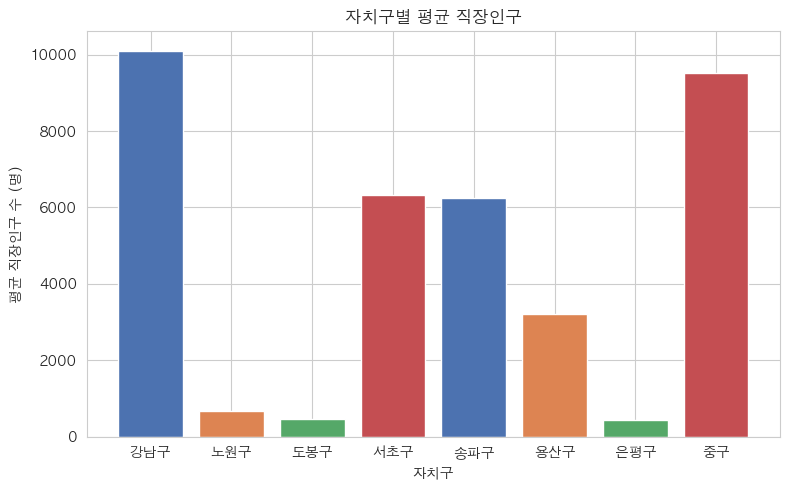

In [65]:


# 상권 유형별 총 직장인구 평균 계산
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

평균_직장 = (
    직장_상권_통합[
        직장_상권_통합['자치구_코드_명'].isin(선택구)
    ]
    .groupby('자치구_코드_명')['총_직장_인구_수']
    .mean()
    .reset_index()
)
# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_직장['자치구_코드_명'], 평균_직장['총_직장_인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('자치구별 평균 직장인구')
ax.set_xlabel('자치구')
ax.set_ylabel('평균 직장인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

+직장인 자치구별 인구수
상위 - 강남, 중구
중상 - 서초,송파
중 - 용산 
외. - 직장인 인구수 적음

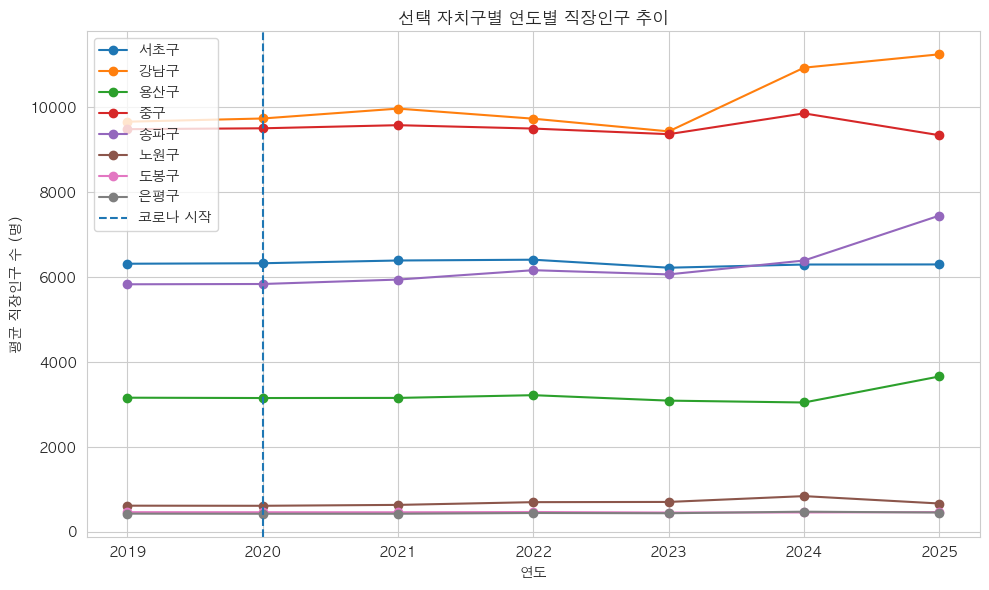

In [66]:
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

연도별 = (
    직장_상권_통합[
        직장_상권_통합['자치구_코드_명'].isin(선택구)
    ]
    .groupby(['연도', '자치구_코드_명'])['총_직장_인구_수']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))

for 구 in 선택구:
    df_구 = 연도별[연도별['자치구_코드_명'] == 구]
    ax.plot(
        df_구['연도'],
        df_구['총_직장_인구_수'],
        marker='o',
        label=구
    )

ax.axvline(x=2020, linestyle='--', label='코로나 시작')

ax.set_title('선택 자치구별 연도별 직장인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 직장인구 수 (명)')

ax.legend()
plt.tight_layout()
plt.show()

연도별로보는 자치구별 직작인 인구 추이(연도)
자치구별로 평균 직장인구 수 상위권, 강남+중구 비교 - 강남구에 직장인 인구 상승. 중구 직장인인구 최근 하락
                     중상위, 서초+ 송파 - 서초 유지, 송파 상승.
                      중 , 용산 상승
                     하위 , 노원+동봉+은평 인구수 적고 낮음.

요약:직장인 인구는 강남·중구 등 중심 업무지역에 집중되어 있으며, 송파·용산은 증가 흐름이 나타나는 확장형 지역으로 확인되고, 노원·도봉·은평은 상대적으로 낮은 규모가 유지되는 지역으로 나타난다.

# 상구인구

In [68]:
from pathlib import Path
import zipfile, shutil

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 경로
target_dir = project_root / 'data' / '07_상주인구'
csv_path = target_dir / '서울시 상권분석서비스(상주인구-상권).csv'

# CSV 없으면 raw에서 zip 찾아서 자동 압축 해제
if not csv_path.exists():
    print('📦 CSV 없음, zip 찾는 중...')
    raw_dir = project_root.parent / 'data' / 'raw'
    
    zip_files = list(raw_dir.glob('*상주인구*.zip'))
    if not zip_files:
        raise FileNotFoundError(f'{raw_dir} 에 상주인구 zip 없음')
    
    zip_path = zip_files[0]
    print(f'  압축 해제: {zip_path.name}')
    target_dir.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            if info.filename.startswith('__MACOSX'):
                continue
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except:
                filename = info.filename
            
            if info.is_dir():
                continue
            
            out_path = target_dir / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)
    print(f'  ✅ 완료')

# CSV 로드
df_상주 = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 상주인구 로드: {df_상주.shape}')

📦 CSV 없음, zip 찾는 중...
  압축 해제: 서울시 상권분석서비스(상주인구-상권).zip
  ✅ 완료
✅ 상주인구 로드: (40812, 29)


In [69]:
len(상권_통합.columns)

18

In [70]:
len(df_상주.columns)

29

In [71]:
상주_상권_통합 = 상권_통합.merge(
    df_상주[
        [
            '상권_코드', '기준_년분기_코드',
            '총_상주인구_수',
            '남성_상주인구_수', '여성_상주인구_수',
            '연령대_10_상주인구_수', '연령대_20_상주인구_수',
            '연령대_30_상주인구_수', '연령대_40_상주인구_수',
            '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수',
            '남성연령대_10_상주인구_수', '남성연령대_20_상주인구_수',
            '남성연령대_30_상주인구_수', '남성연령대_40_상주인구_수',
            '남성연령대_50_상주인구_수', '남성연령대_60_이상_상주인구_수',
            '여성연령대_10_상주인구_수', '여성연령대_20_상주인구_수',
            '여성연령대_30_상주인구_수', '여성연령대_40_상주인구_수',
            '여성연령대_50_상주인구_수', '여성연령대_60_이상_상주인구_수',
            '총_가구_수', '아파트_가구_수', '비_아파트_가구_수'
        ]
    ],
    on=['상권_코드', '기준_년분기_코드'],
    how='left'
)

In [72]:
len(상주_상권_통합.columns)

42

In [73]:
print(상권_통합.shape)
print(상주_상권_통합.shape)
print(상주_상권_통합['총_상주인구_수'].isna().sum())
print(상주_상권_통합['총_상주인구_수'].isna().mean() * 100)

(46200, 18)
(46200, 42)
5388
11.662337662337663


In [74]:
상주_상권_통합['총_상주인구_수'].isna().groupby(
    상주_상권_통합['자치구_코드_명']
).sum()

자치구_코드_명
강남구     362
강동구     180
강북구     214
강서구     260
관악구     245
광진구     186
구로구     184
금천구     135
노원구     143
도봉구     129
동대문구    260
동작구     171
마포구     285
서대문구    211
서초구     222
성동구     165
성북구     236
송파구     235
양천구     168
영등포구    349
용산구     171
은평구     204
종로구     226
중구      264
중랑구     183
Name: 총_상주인구_수, dtype: int64

In [75]:
상주_상권_통합['총_상주인구_수'].isna().groupby(
    상주_상권_통합['상권_구분_코드_명']
).sum()

상권_구분_코드_명
골목상권    3306
관광특구      18
발달상권     875
전통시장    1189
Name: 총_상주인구_수, dtype: int64

상주인구 데이터 결측은 특정 자치구에 집중되지 않고 서울 전역에 고르게 분포하고 있어 merge 오류가 아닌 데이터 제공 단위 차이에 따른 구조적 결측으로 판단됨.
따라 상주인구는 전체 상권 공통설명 변수라기보다 일부 상권유형에 선택적으로  적용가능한 보조 설명변수로 활용하는게 적절함.

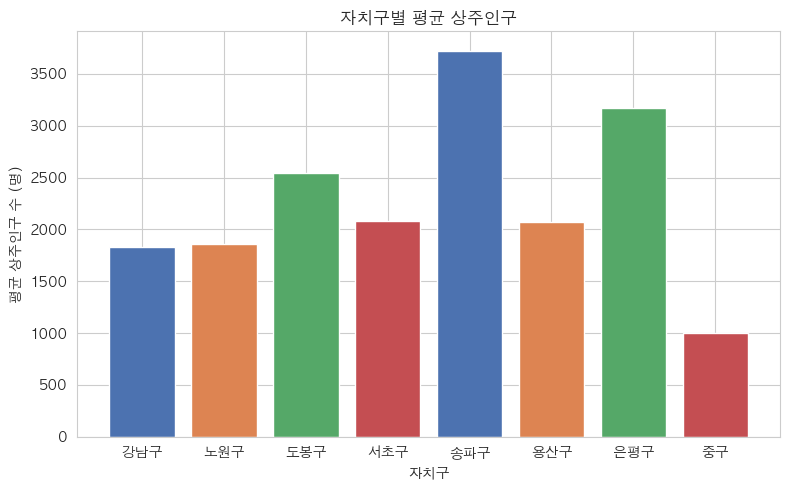

In [76]:
# 자치구별 총 상주인구 평균 계산
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']
평균_상주 = (
    상주_상권_통합[
        상주_상권_통합['자치구_코드_명'].isin(선택구)
    ]
    .groupby('자치구_코드_명')['총_상주인구_수']
    .mean()
    .reset_index()
)

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_상주['자치구_코드_명'], 평균_상주['총_상주인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('자치구별 평균 상주인구')
ax.set_xlabel('자치구')
ax.set_ylabel('평균 상주인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

자치별구 평균상주인구수 비교
상위 탑 3 송파 > 은평 > 도봉
중간     서초와 용산 > 강남과 노원 
하위      중구

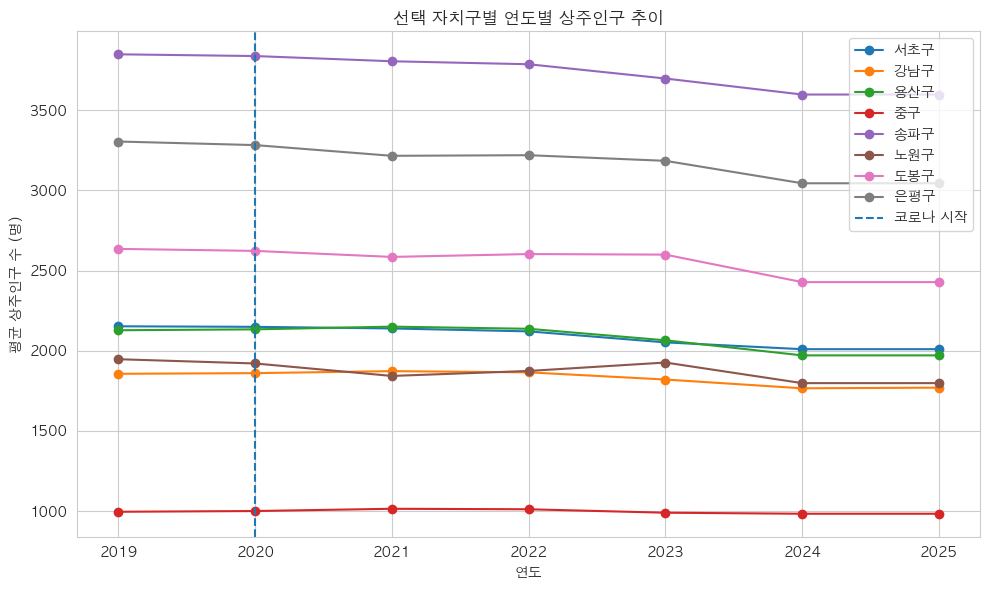

In [77]:
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

연도별 = (
    상주_상권_통합[
        상주_상권_통합['자치구_코드_명'].isin(선택구)
    ]
    .groupby(['연도', '자치구_코드_명'])['총_상주인구_수']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))

for 구 in 선택구:
    df_구 = 연도별[연도별['자치구_코드_명'] == 구]
    ax.plot(
        df_구['연도'],
        df_구['총_상주인구_수'],
        marker='o',
        label=구
    )

ax.axvline(x=2020, linestyle='--', label='코로나 시작')

ax.set_title('선택 자치구별 연도별 상주인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 상주인구 수 (명)')

ax.legend()
plt.tight_layout()
plt.show()

연도별 자치별구 평균상주인구수 비교
상위 탑 3 = 송파 > 은평 > 도봉     ->(추이비교) 송파(살짝 떨어지고 유지), 은평(살짝떨어지고유지) , 도봉 (살짝떨어지고 유지)
중간      = 서초와 용산 > 강남과 노원 ->(추이비교) 거의 유지
하위      =  중구                 ->(추이비교) 유지

# 길단위

In [78]:
from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

csv_path = project_root / 'data' / 'extracted' /'서울시 상권분석서비스(길단위인구-상권)/서울시 상권분석서비스(길단위인구-상권).csv'

df_길단위 = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 로드 완료: {df.shape}')

✅ 로드 완료: (46200, 11)


In [79]:
df_길단위.head(2)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_유동인구_수,남성_유동인구_수,여성_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,연령대_30_유동인구_수,연령대_40_유동인구_수,연령대_50_유동인구_수,연령대_60_이상_유동인구_수,시간대_00_06_유동인구_수,시간대_06_11_유동인구_수,시간대_11_14_유동인구_수,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수
0,20254,U,관광특구,3001496,강남 마이스 관광특구,109921,53290,56631,8894,21760,29582,25319,15024,9343,5732,20525,26812,27794,23322,5735,15423,16342,17360,17968,17478,13580,11770
1,20254,U,관광특구,3001495,잠실 관광특구,4226024,1994837,2231189,443601,974324,1043765,726236,486949,551150,755096,743839,620593,667575,926500,512425,555832,570736,602424,610277,625251,660794,600710


In [80]:
print("평균:", df_길단위['총_유동인구_수'].mean())
print("중앙값:", df_길단위['총_유동인구_수'].median())
print("최대값:", df_길단위['총_유동인구_수'].max())

평균: 836435.7921141521
중앙값: 571569.5
최대값: 10936954


In [81]:
import numpy as np
df_길단위['log_유동인구'] = np.log1p(df_길단위['총_유동인구_수'])
df_길단위['log_유동인구']

0       11.61
1       15.26
2       15.94
3       15.01
4       15.80
         ... 
46179   11.77
46180   13.11
46181   13.47
46182   13.20
46183   11.96
Name: log_유동인구, Length: 46184, dtype: float64

In [82]:
유동_상권_통합 = 상권_통합.merge(
    df_길단위[
        [
            '상권_코드',
            '기준_년분기_코드',
            '총_유동인구_수',
            '남성_유동인구_수',
            '여성_유동인구_수',
            '연령대_10_유동인구_수',
            '연령대_20_유동인구_수',
            '연령대_30_유동인구_수',
            '연령대_40_유동인구_수',
            '연령대_50_유동인구_수',
            '연령대_60_이상_유동인구_수',
            '시간대_00_06_유동인구_수',
            '시간대_06_11_유동인구_수',
            '시간대_11_14_유동인구_수',
            '시간대_14_17_유동인구_수',
            '시간대_17_21_유동인구_수',
            '시간대_21_24_유동인구_수',
            '월요일_유동인구_수',
            '화요일_유동인구_수',
            '수요일_유동인구_수',
            '목요일_유동인구_수',
            '금요일_유동인구_수',
            '토요일_유동인구_수',
            '일요일_유동인구_수',
            'log_유동인구'
        ]
    ],
    on=['상권_코드', '기준_년분기_코드'],
    how='left'
)

In [83]:
print(상권_통합.shape)
print(유동_상권_통합.shape)
print(유동_상권_통합['총_유동인구_수'].isna().mean()*100)

(46200, 18)
(46200, 41)
0.03463203463203463


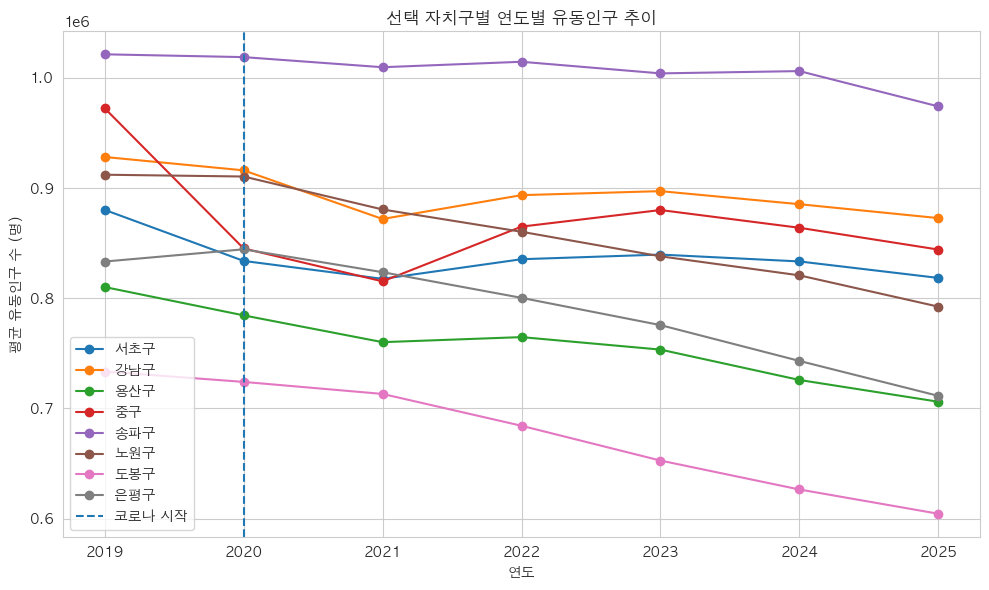

In [84]:
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

연도별 = (
    유동_상권_통합[
        유동_상권_통합['자치구_코드_명'].isin(선택구)
    ]
    .groupby(['연도', '자치구_코드_명'])['총_유동인구_수']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))

for 구 in 선택구:
    df_구 = 연도별[연도별['자치구_코드_명'] == 구]
    ax.plot(
        df_구['연도'],
        df_구['총_유동인구_수'],
        marker='o',
        label=구
    )

ax.axvline(x=2020, linestyle='--', label='코로나 시작')

ax.set_title('선택 자치구별 연도별 유동인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 유동인구 수 (명)')

ax.legend()
plt.tight_layout()
plt.show()

전반적인 평균 유동인구수가 떨어지는 추세(21년)로 보인다.

자치구별 유동인구는 송파구가 전 기간 가장 높은 수준을 유지한 반면 도봉구·은평구·노원구는 전반적인 감소 흐름이 나타났고 강남구와 서초구는 비교적 안정적인 수준을 유지하는 특징이 확인

# 상권분석 서비스

In [85]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'  # Mac 한글 폰트
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

In [86]:
from pathlib import Path
import zipfile
import shutil

# 경로 설정
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
target_dir = project_root / 'data' / 'extracted' / '상권분석서비스(점포_상권)'
zip_path = project_root / 'data' / 'raw' / '상권분석서비스(점포_상권).zip'

# 1. zip 한 번만 풀기 (이미 풀려있으면 스킵)
if not target_dir.exists() or not any(target_dir.iterdir()):
    print(f'📦 압축 해제 중: {zip_path.name}')
    target_dir.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            if info.filename.startswith('__MACOSX'):
                continue
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except:
                filename = info.filename
            if info.is_dir():
                continue
            out_path = target_dir / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)
    print('  ✅ 완료')

# 2. 풀린 폴더 안의 모든 CSV 자동 통합
import glob
csv_files = sorted(target_dir.glob('*.csv'))
print(f'\n📂 CSV 파일 {len(csv_files)}개 발견:')
for f in csv_files:
    print(f'  {f.name}')

# 3. 모두 로드해서 통합 (인코딩 자동 시도)
dfs = []
for csv_path in csv_files:
    try:
        df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
    dfs.append(df)
    print(f'✅ {csv_path.name}: {df.shape}')

df_전체 = pd.concat(dfs, ignore_index=True)
print(f'\n📊 전체 데이터: {df_전체.shape}')


📂 CSV 파일 6개 발견:
  서울시 상권분석서비스(점포-상권)_2024년.csv
  서울시_상권분석서비스(점포-상권)_2019년.csv
  서울시_상권분석서비스(점포-상권)_2020년.csv
  서울시_상권분석서비스(점포-상권)_2021년.csv
  서울시_상권분석서비스(점포-상권)_2022년.csv
  서울시_상권분석서비스(점포-상권)_2023년.csv
✅ 서울시 상권분석서비스(점포-상권)_2024년.csv: (306889, 14)
✅ 서울시_상권분석서비스(점포-상권)_2019년.csv: (297369, 14)
✅ 서울시_상권분석서비스(점포-상권)_2020년.csv: (310459, 14)
✅ 서울시_상권분석서비스(점포-상권)_2021년.csv: (303880, 14)
✅ 서울시_상권분석서비스(점포-상권)_2022년.csv: (305587, 14)
✅ 서울시_상권분석서비스(점포-상권)_2023년.csv: (307741, 14)

📊 전체 데이터: (1831925, 14)


In [87]:
점포_집계 = (
    df_전체
    .groupby(['상권_코드', '기준_년분기_코드'])
    .agg(
        총점포수=('점포_수', 'sum'),
        총유사업종점포수=('유사_업종_점포_수', 'sum'),
        총개업점포수=('개업_점포_수', 'sum'),
        총폐업점포수=('폐업_점포_수', 'sum'),
        총프랜차이즈점포수=('프랜차이즈_점포_수', 'sum')
    )
    .reset_index()
)

점포_집계['개업률'] = (점포_집계['총개업점포수'] / 점포_집계['총점포수'] * 100).round(2)
점포_집계['폐업률'] = (점포_집계['총폐업점포수'] / 점포_집계['총점포수'] * 100).round(2)
점포_집계['순성장률'] = (점포_집계['개업률'] - 점포_집계['폐업률']).round(2)

점포_집계

,상권_코드,기준_년분기_코드,총점포수,총유사업종점포수,총개업점포수,총폐업점포수,총프랜차이즈점포수,개업률,폐업률,순성장률
0,3001491,20191,1600,1686,67,59,86,4.19,3.69,0.50
1,3001491,20192,1602,1689,65,62,87,4.06,3.87,0.19
2,3001491,20193,1600,1686,64,67,86,4.00,4.19,-0.19
3,3001491,20194,1619,1705,59,40,86,3.64,2.47,1.17
4,3001491,20201,1592,1682,54,77,90,3.39,4.84,-1.45
...,...,...,...,...,...,...,...,...,...,...
39595,3130327,20234,3097,3106,12,50,9,0.39,1.61,-1.22
39596,3130327,20241,2978,2987,8,127,9,0.27,4.26,-3.99
39597,3130327,20242,2928,2937,5,55,9,0.17,1.88,-1.71
39598,3130327,20243,2860,2869,18,86,9,0.63,3.01,-2.38


In [88]:
상권_통합_2024 = 상권_통합[상권_통합['기준_년분기_코드'] <= 20244].copy()

점포_상권_통합 = 상권_통합_2024.merge(
    점포_집계,
    on=['상권_코드', '기준_년분기_코드'],
    how='left'
)

In [89]:
print(상권_통합_2024.shape)
print(점포_상권_통합.shape)

print(점포_상권_통합[['총점포수', '총개업점포수', '총폐업점포수', '순성장률']].isna().sum())
print((점포_상권_통합['총점포수'].isna().mean() * 100).round(2))

(39600, 18)
(39600, 26)
총점포수      0
총개업점포수    0
총폐업점포수    0
순성장률      0
dtype: int64
0.0


In [90]:
# 점포수 많으면 성장률이 높나?
점포_상권_통합[['총점포수','순성장률']].corr()

,총점포수,순성장률
총점포수,1.00,0.00
순성장률,0.00,1.00


In [91]:
# 자치구별 성장률
점포_상권_통합.groupby('자치구_코드_명')['순성장률'].mean()

자치구_코드_명
강남구    0.80
강동구    0.57
강북구    0.19
강서구    0.51
관악구    0.41
광진구    0.55
구로구    0.26
금천구    0.23
노원구    0.82
도봉구    0.39
동대문구   0.31
동작구    0.14
마포구    0.68
서대문구   0.25
서초구    0.41
성동구    0.84
성북구    0.24
송파구    0.51
양천구    0.36
영등포구   0.37
용산구    0.48
은평구    0.29
종로구    0.26
중구     0.20
중랑구    0.63
Name: 순성장률, dtype: float64

In [92]:
# 자치구별 평균 점포수

# 연도 + 자치구별 평균 점포수
result = 점포_상권_통합.groupby(
    ['연도', '자치구_코드_명']
)['총점포수'].mean().reset_index()

# 피벗
pivot_store = result.pivot(
    index='자치구_코드_명',
    columns='연도',
    values='총점포수'
)

print(pivot_store)

연도         2019   2020   2021   2022   2023   2024
자치구_코드_명                                          
강남구      427.18 449.24 465.45 483.54 498.91 498.36
강동구      246.43 253.93 261.36 269.14 278.50 274.74
강북구      134.30 139.17 142.92 145.56 148.03 145.21
강서구      228.04 245.43 258.51 270.70 279.15 277.81
관악구      164.67 172.14 176.49 179.21 183.61 182.76
광진구      216.63 225.96 231.85 236.79 240.75 238.94
구로구      279.88 289.12 295.08 300.09 304.53 299.74
금천구      287.63 301.65 312.41 321.99 337.31 336.11
노원구      233.55 242.38 247.46 251.18 254.76 252.88
도봉구      156.89 161.26 163.77 166.71 167.94 165.58
동대문구     193.41 197.74 200.60 203.92 206.60 206.48
동작구      191.71 198.40 201.45 203.36 205.51 204.35
마포구      263.74 274.78 282.13 295.23 307.84 311.25
서대문구     152.18 156.12 157.52 161.64 164.28 162.92
서초구      414.26 431.58 441.22 452.84 464.42 465.24
성동구      207.81 219.70 227.76 235.89 243.34 246.32
성북구      130.62 133.92 136.21 140.84 143.68 142.72
송파구      436.17 458.86 470.77 4

In [93]:
result_sum = 점포_상권_통합.groupby(
    ['연도','자치구_코드_명']
)['총점포수'].sum().reset_index()

result_sum

,연도,자치구_코드_명,총점포수
0,2019,강남구,175998
1,2019,강동구,59144
2,2019,강북구,33843
3,2019,강서구,63852
4,2019,관악구,48742
...,...,...,...
145,2024,용산구,68409
146,2024,은평구,49924
147,2024,종로구,104826
148,2024,중구,233009


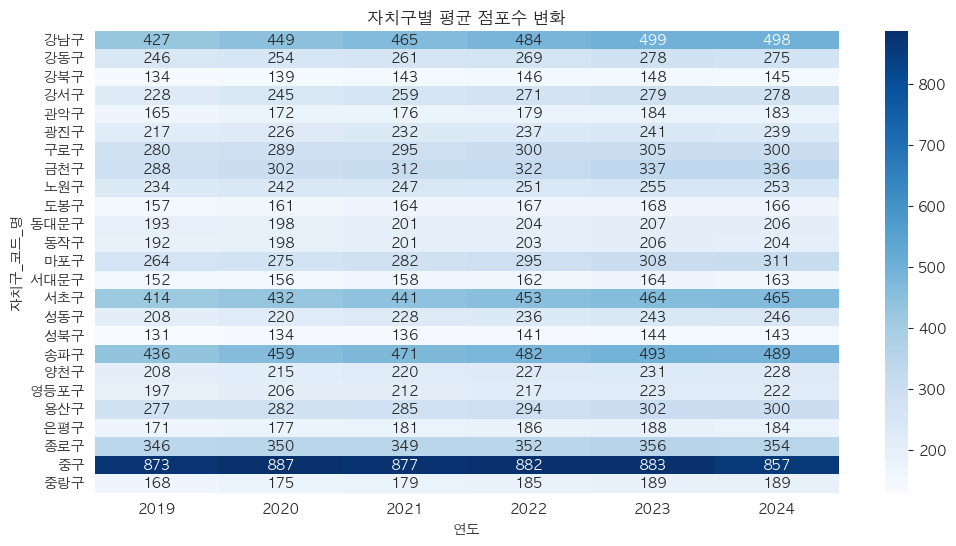

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(pivot_store, annot=True, fmt=".0f", cmap="Blues")
plt.title("자치구별 평균 점포수 변화")
plt.show()

점포수 변화
상위 중구, 강나,서초 , 송파구
그위는 점포수 낮음.

점포수 상위권 구 중에서 나머지는 다 점포수 오르는 중인데, 21년도 이후로 중구는 낮아지는 추세

In [95]:
growth = 점포_상권_통합.groupby(
    ['연도','자치구_코드_명']
)['순성장률'].mean().reset_index()

In [96]:
선택구_list = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

점포_상권_선택구 = 점포_상권_통합[
    점포_상권_통합['자치구_코드_명'].isin(선택구_list)
].copy()

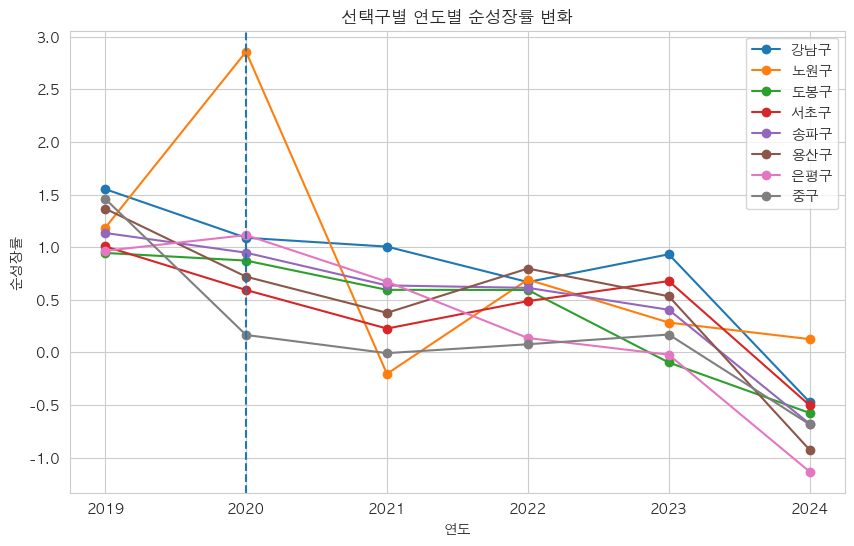

In [97]:
import matplotlib.pyplot as plt

growth = 점포_상권_선택구.groupby(
    ['연도','자치구_코드_명']
)['순성장률'].mean().reset_index()

plt.figure(figsize=(10,6))

for gu in growth['자치구_코드_명'].unique():
    temp = growth[growth['자치구_코드_명']==gu]
    plt.plot(temp['연도'], temp['순성장률'], marker='o', label=gu)

plt.axvline(x=2020, linestyle='--')

plt.title('선택구별 연도별 순성장률 변화')
plt.xlabel('연도')
plt.ylabel('순성장률')
plt.legend()
plt.show()

24년도 동시하락된 순성장률.
노원구- 20년 가장 최고점 순성장률을 찍고 후 변동성 크게 나타남. (변동성 전체 자치구 중 가장 큰폭)
강남+송파 - 29-23 안정적 유지 하다가 24 하락
도봉구- 19 이후부터 점진적 감소
은평 - 20년붜 성장률 최대 감소.
중구 - 전체흐름+전체구에서 가장 낮은 성장률.

요약:
자치구별 순성장률은 2024년에 대부분 지역에서 동시에 하락하는 흐름이 나타났으며, 노원구는 가장 큰 변동폭을 보였고 도봉구와 송파구는 장기적인 감소 흐름

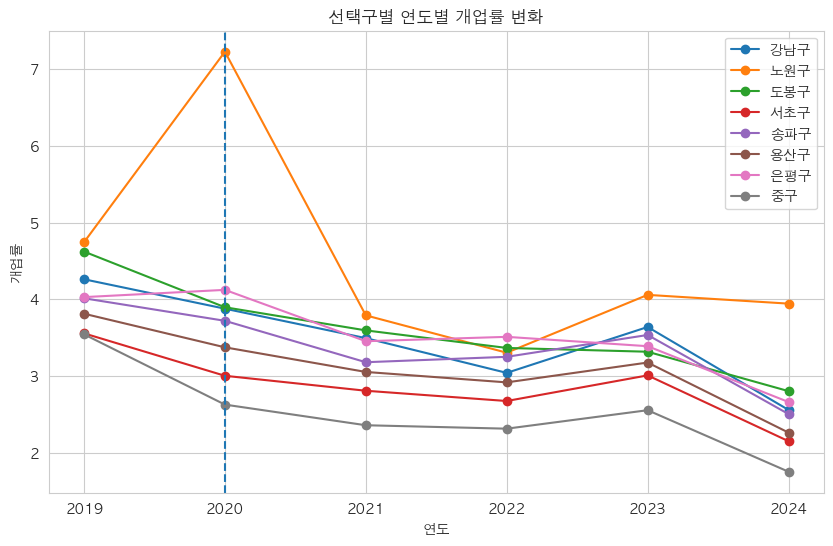

In [98]:
open_rate = 점포_상권_선택구.groupby(
    ['연도','자치구_코드_명']
)['개업률'].mean().reset_index()

plt.figure(figsize=(10,6))

for gu in open_rate['자치구_코드_명'].unique():
    temp = open_rate[open_rate['자치구_코드_명']==gu]
    plt.plot(temp['연도'], temp['개업률'], marker='o', label=gu)

plt.axvline(x=2020, linestyle='--')

plt.title('선택구별 연도별 개업률 변화')
plt.xlabel('연도')
plt.ylabel('개업률')
plt.legend()
plt.show()

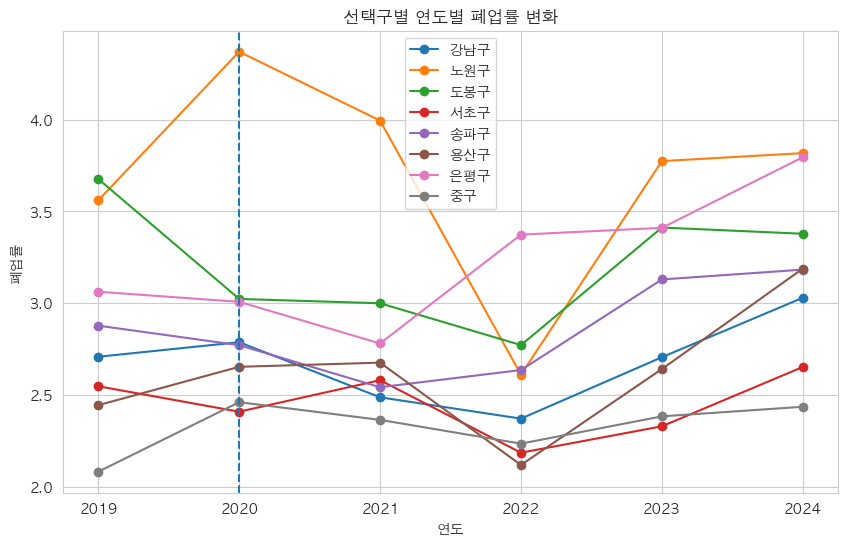

In [99]:
close_rate = 점포_상권_선택구.groupby(
    ['연도','자치구_코드_명']
)['폐업률'].mean().reset_index()

plt.figure(figsize=(10,6))

for gu in close_rate['자치구_코드_명'].unique():
    temp = close_rate[close_rate['자치구_코드_명']==gu]
    plt.plot(temp['연도'], temp['폐업률'], marker='o', label=gu)

plt.axvline(x=2020, linestyle='--')

plt.title('선택구별 연도별 폐업률 변화')
plt.xlabel('연도')
plt.ylabel('폐업률')
plt.legend()
plt.show()

자치구별 개업률 폐업률 추이(연도) 인사이트
<개업률> 노원 20년도에 최고점 + 대부분 21~22년도에 개업률 하락 발생 + 23년도 일부개업률 회복 햇다가 24년도 다시 하락하는 추세.
<폐업률> 22년 최저 기록 (강남,서초,용산,노원,중구) 동시저점 발생 (22년도에 폐업률 가장 낮은 수준) + 23~24년 폐업률 증가하는 추세.

<개업/폐업 인사이트>
24년 개업률 감소 + 폐업률 증가 -> 강남, 용산,송파,은평 (순성장률 하락 구조)
대부분 자치구에서 2021~2022년 개업률 감소 이후 2023년 일부 회복이 나타났으나 2024년 다시 감소 흐름이 나타났고, 동시에 폐업률은 2023년 이후 증가하는 흐름

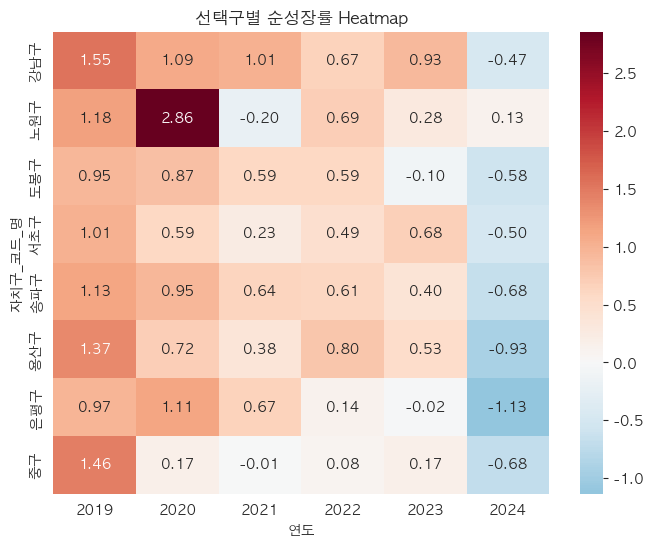

In [100]:
import seaborn as sns

pivot_growth = growth.pivot(
    index='자치구_코드_명',
    columns='연도',
    values='순성장률'
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_growth,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0
)

plt.title('선택구별 순성장률 Heatmap')
plt.show()

In [101]:
상권집계

,상권_코드,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출,총건수,업종수,객단가,log_매출,총매출_억
0,3001491,이태원 관광특구,관광특구,용산구,96748250708,3137664,33,"30,834.48",10.99,967.50
1,3001492,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,537829815743,15760017,53,"34,126.22",11.73,"5,378.30"
2,3001493,동대문패션타운 관광특구,관광특구,중구,151636997858,4447433,39,"34,095.40",11.18,"1,516.40"
3,3001494,종로?청계 관광특구,관광특구,종로구,263865637195,6909787,53,"38,187.23",11.42,"2,638.70"
4,3001495,잠실 관광특구,관광특구,송파구,380932087468,13411055,42,"28,404.33",11.58,"3,809.30"
...,...,...,...,...,...,...,...,...,...,...
1560,3130323,둔촌역전통시장,전통시장,강동구,14312819445,533868,17,"26,809.66",10.16,143.10
1561,3130324,길동복조리시장,전통시장,강동구,7415216657,377503,16,"19,642.80",9.87,74.20
1562,3130325,명일전통시장,전통시장,강동구,3680810022,129473,9,"28,429.17",9.57,36.80
1563,3130326,고덕 골목형상점가,전통시장,강동구,15616098774,688989,12,"22,665.24",10.19,156.20


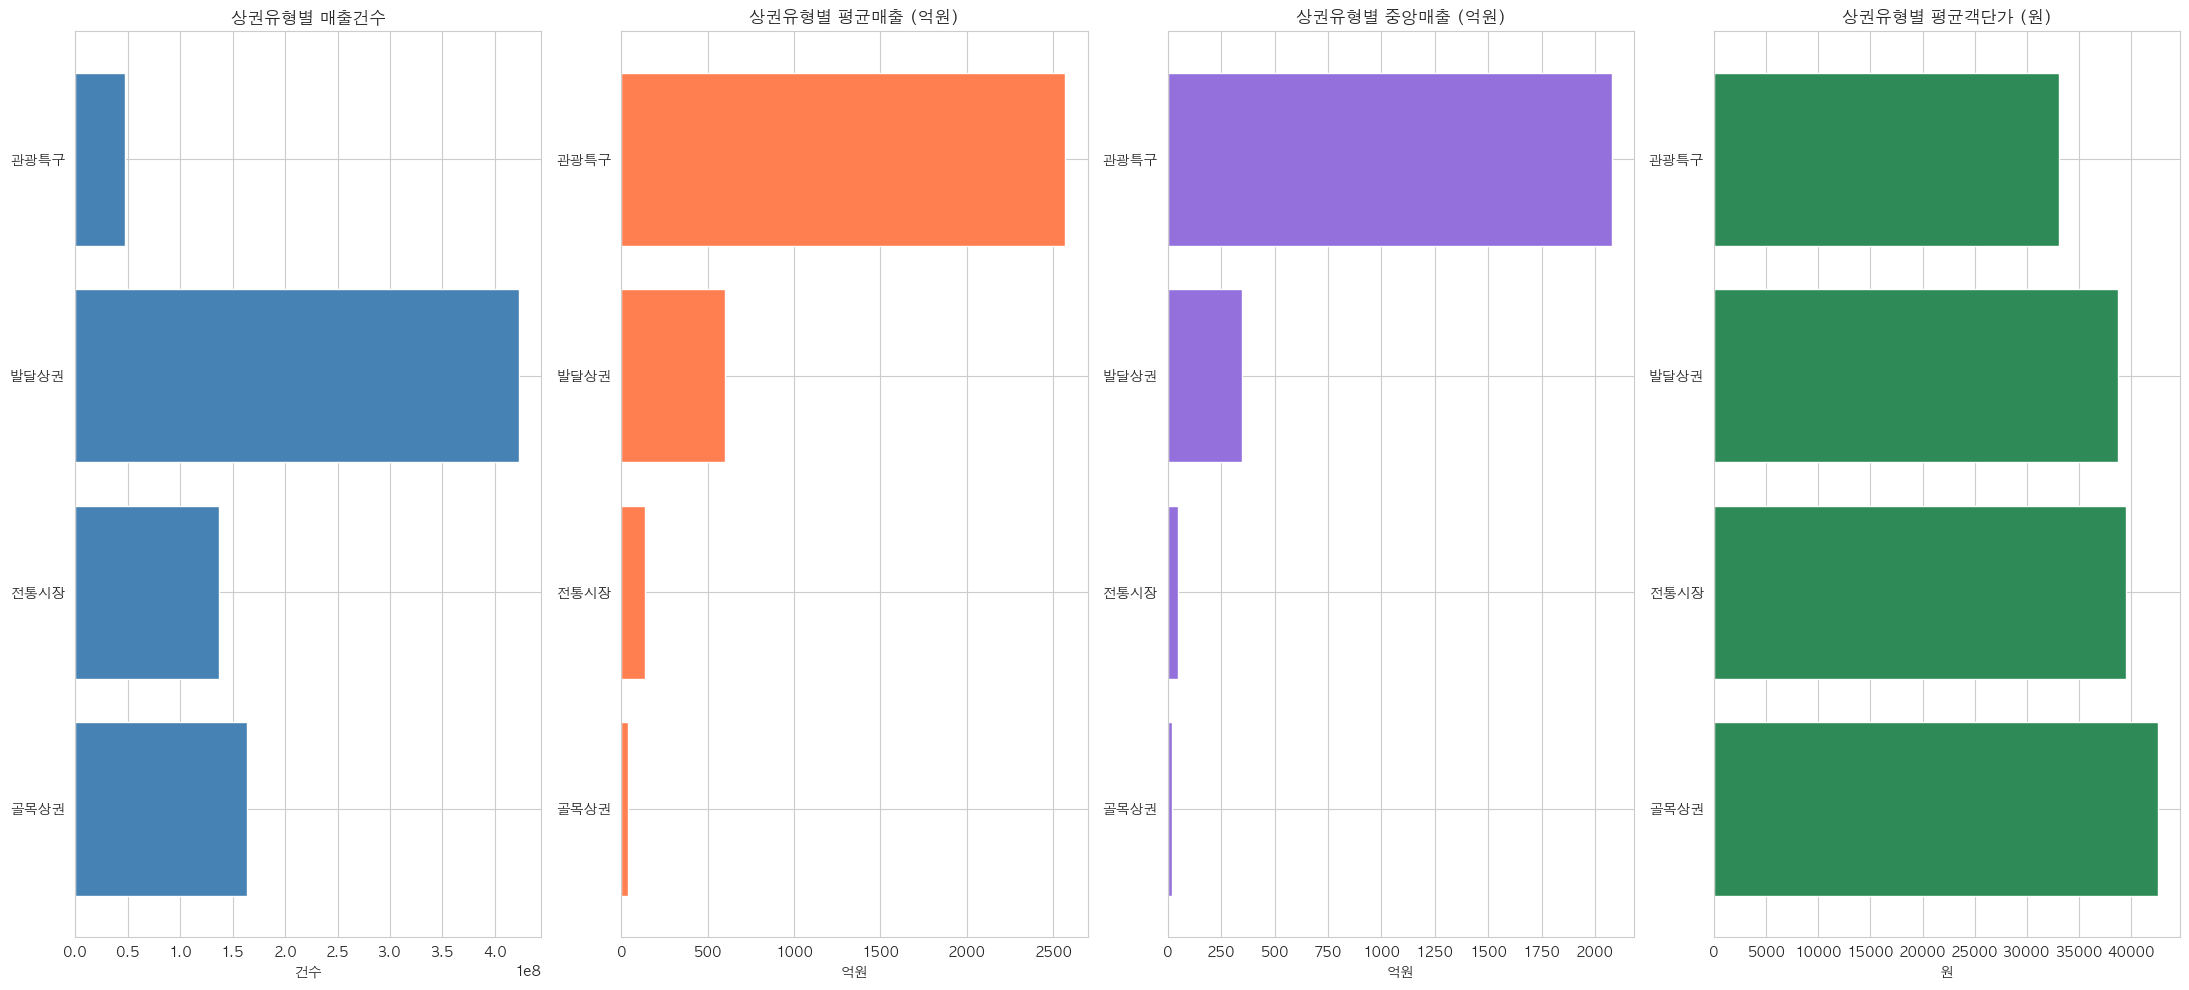

In [102]:

import matplotlib.pyplot as plt
import platform



# 상권유형별 집계
구분통계 = 상권집계.groupby('상권_구분_코드_명').agg(
    매출건수=('총건수', 'sum'),
    평균매출=('총매출', 'mean'),
    중앙매출=('총매출', 'median'),
    평균객단가=('객단가', 'mean')
).reset_index()

구분통계['평균객단가'] = 구분통계['평균객단가'].round(0)

# 평균매출 기준 정렬
구분통계 = 구분통계.sort_values('평균매출', ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(22, 10))

# 1. 매출건수
axes[0].barh(구분통계['상권_구분_코드_명'], 구분통계['매출건수'], color='steelblue')
axes[0].set_title('상권유형별 매출건수')
axes[0].set_xlabel('건수')


# 2. 평균매출
axes[1].barh(구분통계['상권_구분_코드_명'], 구분통계['평균매출'] / 1e8, color='coral')
axes[1].set_title('상권유형별 평균매출 (억원)')
axes[1].set_xlabel('억원')

# 3. 중앙매출
axes[2].barh(구분통계['상권_구분_코드_명'], 구분통계['중앙매출'] / 1e8, color='mediumpurple')
axes[2].set_title('상권유형별 중앙매출 (억원)')
axes[2].set_xlabel('억원')

# 4. 평균객단가
axes[3].barh(구분통계['상권_구분_코드_명'], 구분통계['평균객단가'], color='seagreen')
axes[3].set_title('상권유형별 평균객단가 (원)')
axes[3].set_xlabel('원')

plt.tight_layout()
plt.show()

# 전체연도

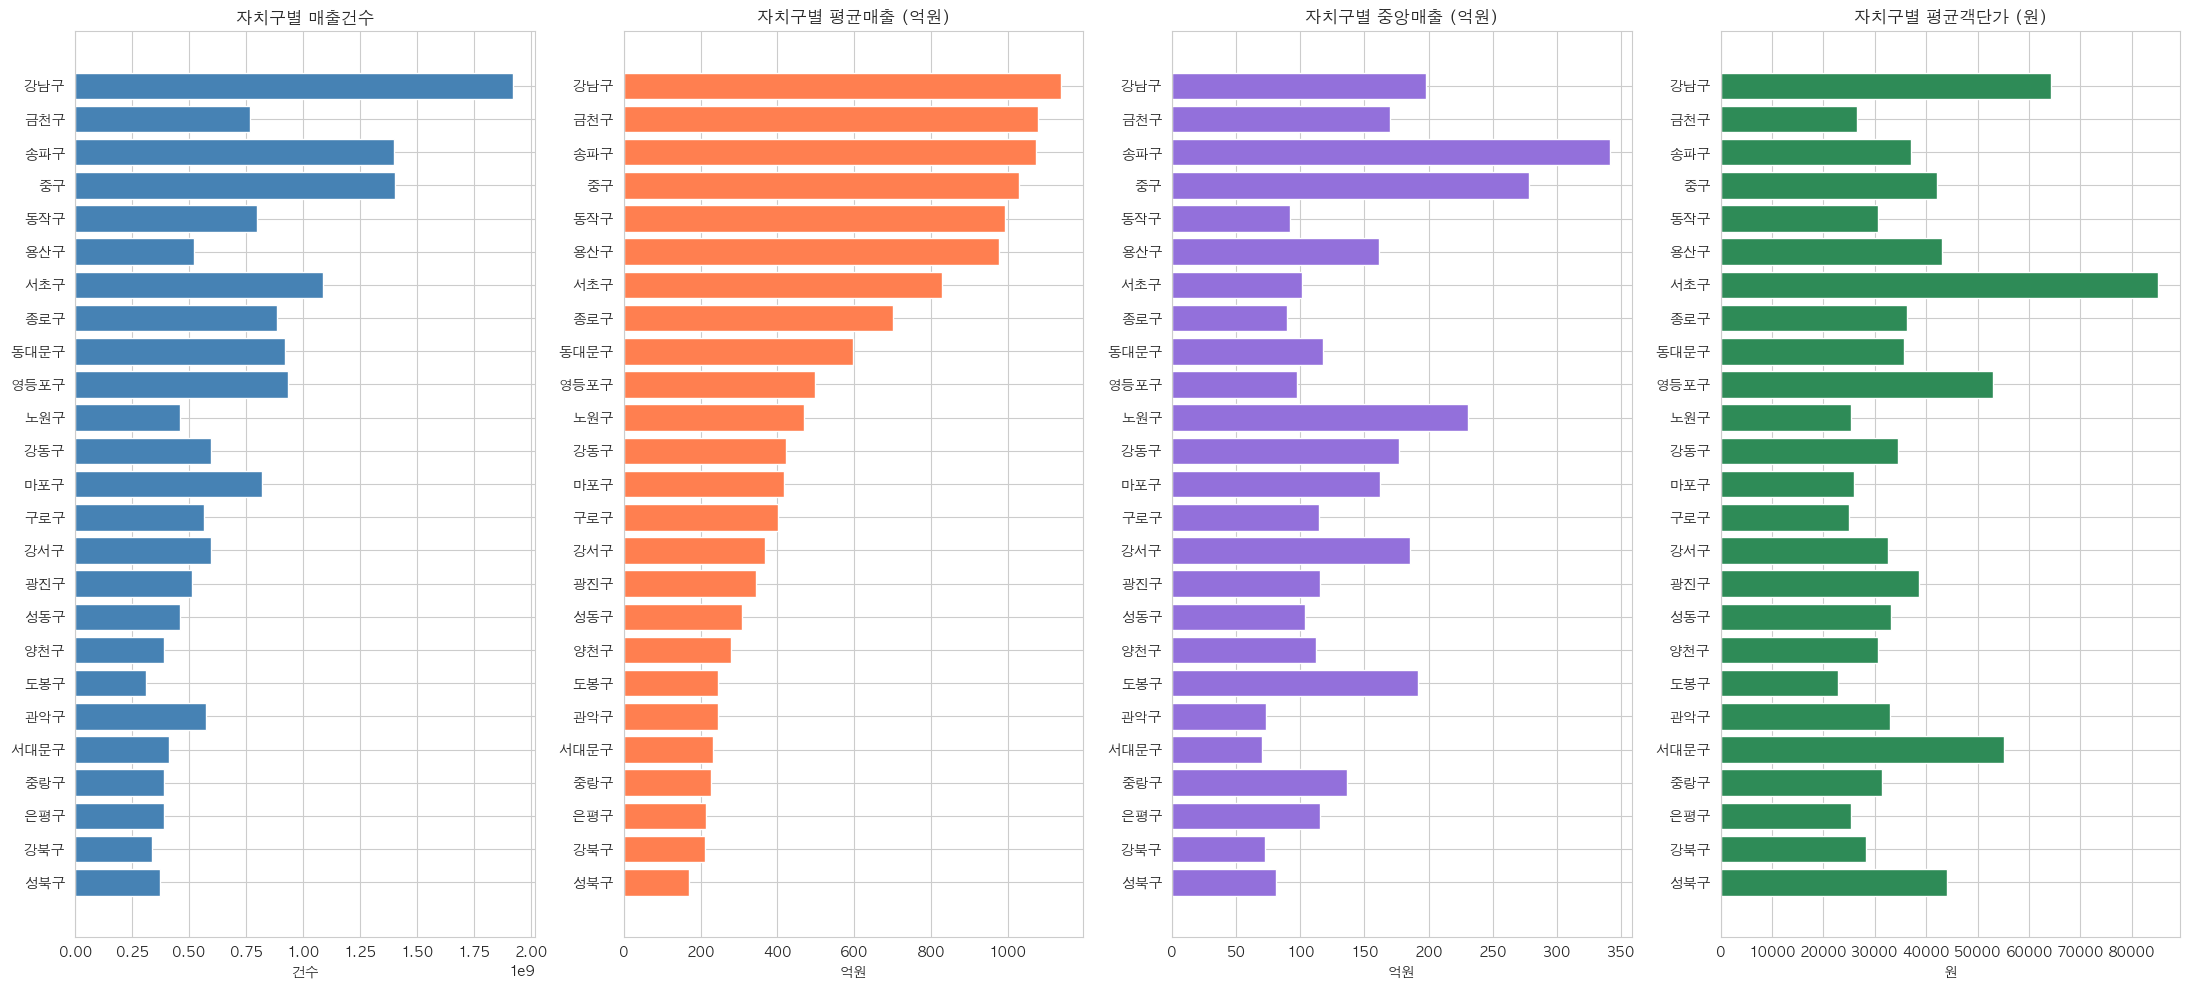

In [103]:

import matplotlib.pyplot as plt
import platform

# 한글 폰트
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 자치구별 집계
전체_구분통계 = 전체_상권집계.groupby('자치구_코드_명').agg(
    매출건수=('총건수', 'sum'),
    평균매출=('총매출', 'mean'),
    중앙매출=('총매출', 'median'),
    평균객단가=('객단가', 'mean')
).reset_index()

전체_구분통계['평균객단가'] = 전체_구분통계['평균객단가'].round(0)

# 평균매출 기준 정렬
전체_구분통계 = 전체_구분통계.sort_values('평균매출', ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(22, 10))

# 1. 매출건수
axes[0].barh(전체_구분통계['자치구_코드_명'], 전체_구분통계['매출건수'], color='steelblue')
axes[0].set_title('자치구별 매출건수')
axes[0].set_xlabel('건수')

# 2. 평균매출
axes[1].barh(전체_구분통계['자치구_코드_명'], 전체_구분통계['평균매출'] / 1e8, color='coral')
axes[1].set_title('자치구별 평균매출 (억원)')
axes[1].set_xlabel('억원')

# 3. 중앙매출
axes[2].barh(전체_구분통계['자치구_코드_명'], 전체_구분통계['중앙매출'] / 1e8, color='mediumpurple')
axes[2].set_title('자치구별 중앙매출 (억원)')
axes[2].set_xlabel('억원')

# 4. 평균객단가
axes[3].barh(전체_구분통계['자치구_코드_명'], 전체_구분통계['평균객단가'], color='seagreen')
axes[3].set_title('자치구별 평균객단가 (원)')
axes[3].set_xlabel('원')

plt.tight_layout()
plt.show()

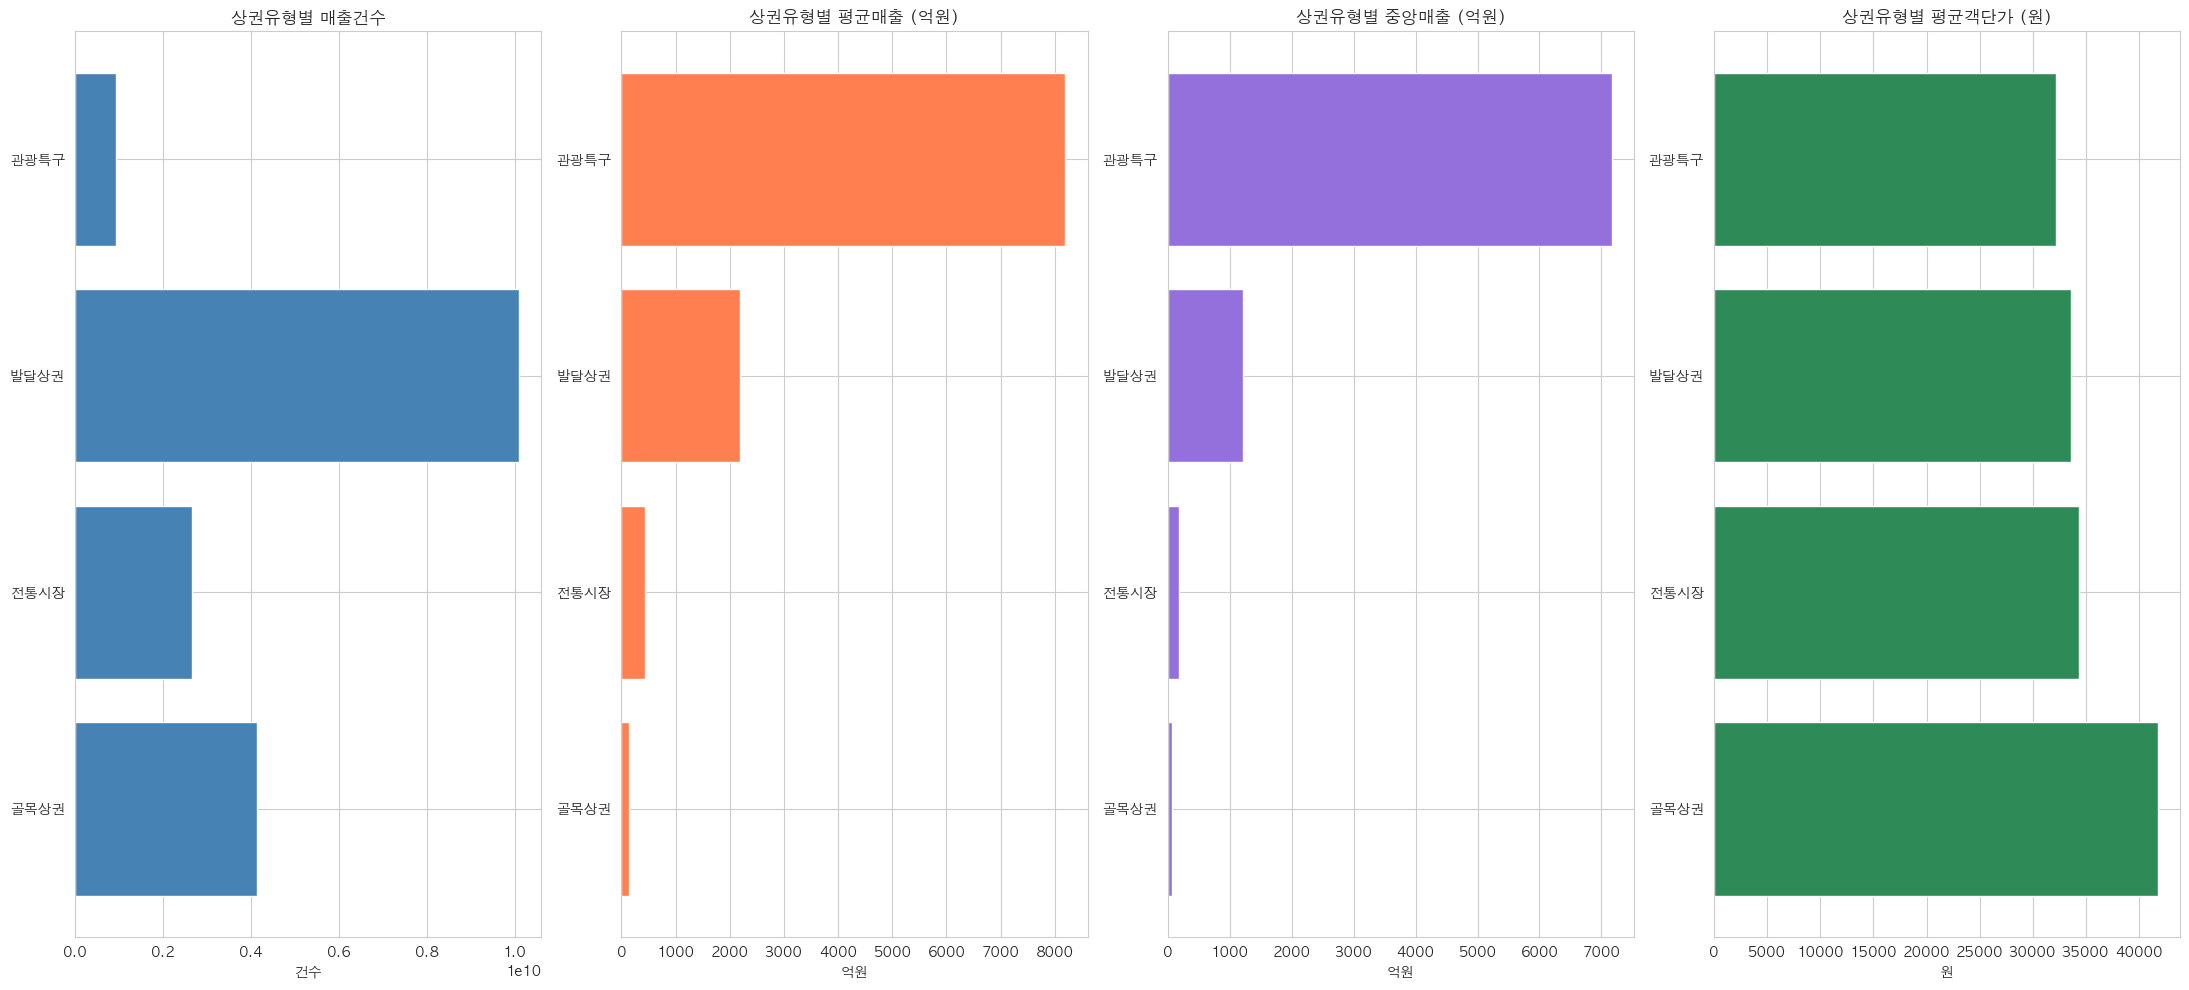

In [104]:

import matplotlib.pyplot as plt
import platform

# 한글 폰트
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상권유형별 집계
전체_구분통계 = 전체_상권집계.groupby('상권_구분_코드_명').agg(
    매출건수=('총건수', 'sum'),
    평균매출=('총매출', 'mean'),
    중앙매출=('총매출', 'median'),
    평균객단가=('객단가', 'mean')
).reset_index()

전체_구분통계['평균객단가'] = 전체_구분통계['평균객단가'].round(0)

# 평균매출 기준 정렬
전체_구분통계 = 전체_구분통계.sort_values('평균매출', ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(22, 10))

# 1. 매출건수
axes[0].barh(전체_구분통계['상권_구분_코드_명'], 전체_구분통계['매출건수'], color='steelblue')
axes[0].set_title('상권유형별 매출건수')
axes[0].set_xlabel('건수')


# 2. 평균매출
axes[1].barh(전체_구분통계['상권_구분_코드_명'], 전체_구분통계['평균매출'] / 1e8, color='coral')
axes[1].set_title('상권유형별 평균매출 (억원)')
axes[1].set_xlabel('억원')

# 3. 중앙매출
axes[2].barh(전체_구분통계['상권_구분_코드_명'], 전체_구분통계['중앙매출'] / 1e8, color='mediumpurple')
axes[2].set_title('상권유형별 중앙매출 (억원)')
axes[2].set_xlabel('억원')

# 4. 평균객단가
axes[3].barh(전체_구분통계['상권_구분_코드_명'], 전체_구분통계['평균객단가'], color='seagreen')
axes[3].set_title('상권유형별 평균객단가 (원)')
axes[3].set_xlabel('원')

plt.tight_layout()
plt.show()

In [105]:
# 성별 비중
성별컬럼 = ['남성_매출_금액', '여성_매출_금액']
성별라벨 = ['남성', '여성']

gender_data = 매출_영역.groupby('자치구_코드_명')[성별컬럼].sum()
gender_data.columns = 성별라벨
gender_pct = gender_data.div(gender_data.sum(axis=1), axis=0) * 100

선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

print(gender_pct.loc[선택구].round(1))

            남성    여성
자치구_코드_명            
서초구      48.30 51.70
강남구      47.30 52.70
용산구      59.70 40.30
중구       48.90 51.10
송파구      51.70 48.30
노원구      48.70 51.30
도봉구      52.60 47.40
은평구      49.00 51.00


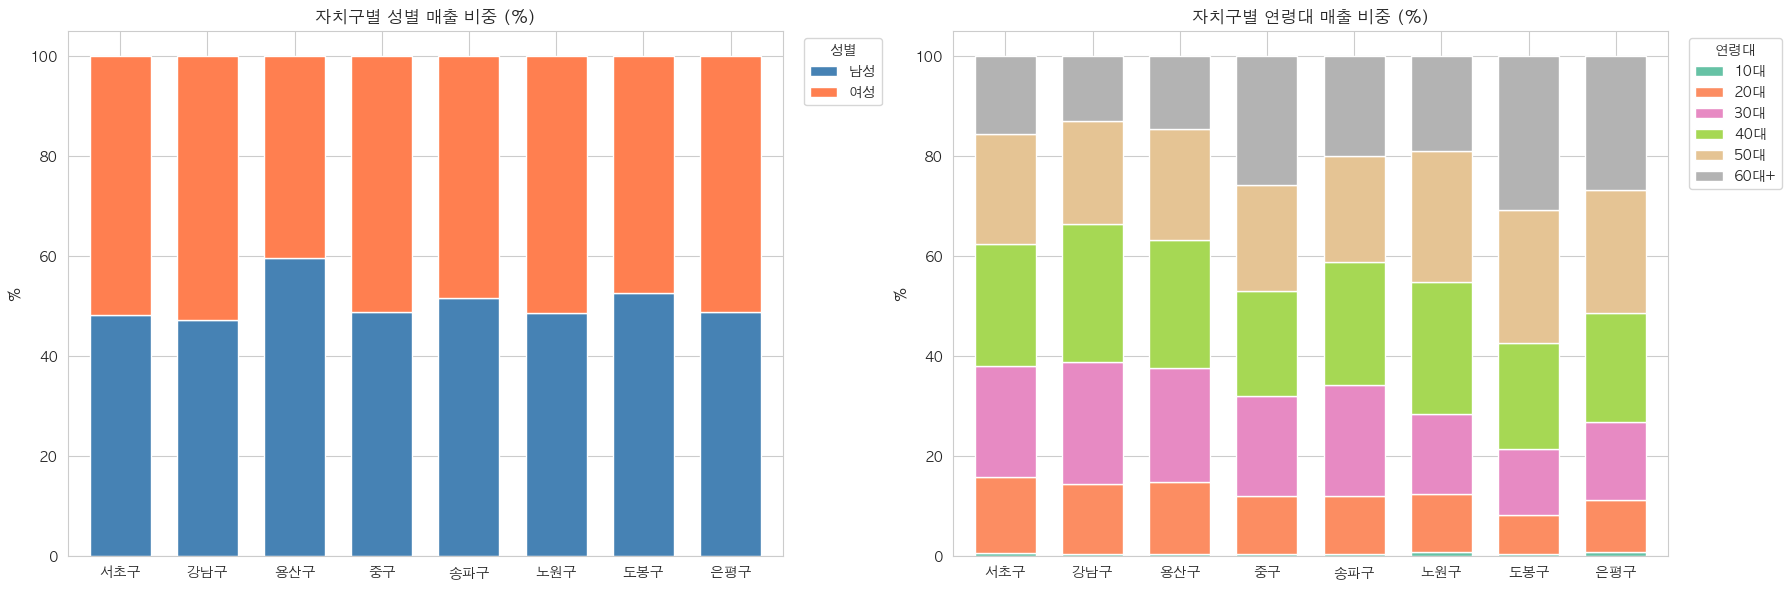

In [106]:
# 성별 매출 비중
성별컬럼 = ['남성_매출_금액', '여성_매출_금액']
성별라벨 = ['남성', '여성']

선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

gender_data = 매출_영역.groupby('자치구_코드_명')[성별컬럼].sum()
gender_data.columns = 성별라벨
gender_pct = gender_data.div(gender_data.sum(axis=1), axis=0) * 100
gender_pct = gender_pct.loc[선택구]

# 연령대 매출 비중
연령컬럼 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
        '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령라벨 = ['10대','20대','30대','40대','50대','60대+']

age_data = 매출_영역.groupby('자치구_코드_명')[연령컬럼].sum()
age_data.columns = 연령라벨
age_pct = age_data.div(age_data.sum(axis=1), axis=0) * 100
age_pct = age_pct.loc[선택구]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 성별
gender_pct.plot(kind='bar', stacked=True, ax=axes[0],
                color=['steelblue','coral'], width=0.7, edgecolor='white')
axes[0].set_title('자치구별 성별 매출 비중 (%)', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_xlabel('')
axes[0].legend(title='성별', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

# 연령대
age_pct.plot(kind='bar', stacked=True, ax=axes[1],
             colormap='Set2', width=0.7, edgecolor='white')
axes[1].set_title('자치구별 연령대 매출 비중 (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].legend(title='연령대', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [107]:
# 성별 컬럼
성별컬럼 = ['남성_매출_금액', '여성_매출_금액']
성별라벨 = ['남성', '여성']

# 연도 생성 
매출_영역['연도'] = 매출_영역['기준_년분기_코드'] // 10

# 연도 + 자치구 기준 집계
gender_year = 매출_영역.groupby(
    ['연도','자치구_코드_명']
)[성별컬럼].sum()

# 컬럼 이름 변경
gender_year.columns = 성별라벨

# 비율 계산
gender_year_pct = gender_year.div(
    gender_year.sum(axis=1), axis=0
) * 100

# 선택구만 보기
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

print(gender_year_pct.loc[
    gender_year_pct.index.get_level_values('자치구_코드_명').isin(선택구)
].round(1))

                 남성    여성
연도   자치구_코드_명            
2020 강남구      45.90 54.10
     노원구      46.20 53.80
     도봉구      52.10 47.90
     서초구      48.00 52.00
     송파구      52.40 47.60
     용산구      63.10 36.90
     은평구      50.00 50.00
     중구       50.40 49.60
2021 강남구      46.90 53.10
     노원구      49.20 50.80
     도봉구      52.40 47.60
     서초구      47.70 52.30
     송파구      52.80 47.20
     용산구      59.60 40.40
     은평구      49.10 50.90
     중구       50.10 49.90
2022 강남구      47.10 52.90
     노원구      49.70 50.30
     도봉구      52.80 47.20
     서초구      48.20 51.80
     송파구      55.20 44.80
     용산구      59.00 41.00
     은평구      49.30 50.70
     중구       49.80 50.20
2023 강남구      47.60 52.40
     노원구      49.30 50.70
     도봉구      52.60 47.40
     서초구      48.50 51.50
     송파구      51.50 48.50
     용산구      59.30 40.70
     은평구      49.50 50.50
     중구       48.70 51.30
2024 강남구      47.70 52.30
     노원구      49.00 51.00
     도봉구      52.90 47.10
     서초구      48.40 51.60
     송파구    

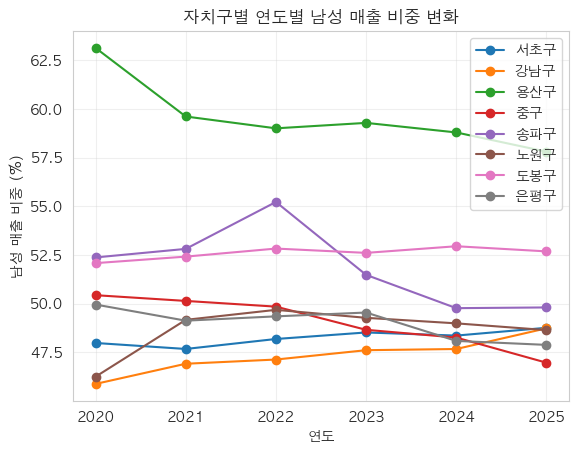

In [108]:
import matplotlib.pyplot as plt

for 구 in 선택구:
    temp = gender_year_pct.loc[
        gender_year_pct.index.get_level_values('자치구_코드_명')==구
    ]

    plt.plot(temp.index.get_level_values('연도'),
             temp['남성'],
             marker='o',
             label=구)

plt.title('자치구별 연도별 남성 매출 비중 변화')
plt.xlabel('연도')
plt.ylabel('남성 매출 비중 (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

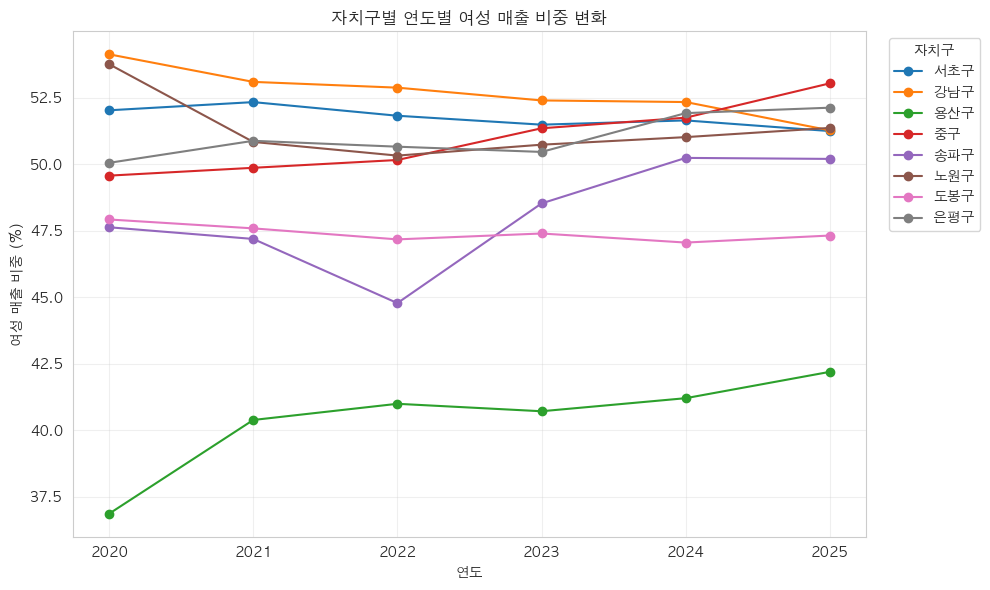

In [109]:
import matplotlib.pyplot as plt

# 선택 자치구
선택구 = ['서초구','강남구','용산구','중구','송파구','노원구','도봉구','은평구']

plt.figure(figsize=(10,6))

for 구 in 선택구:
    temp = gender_year_pct.loc[
        gender_year_pct.index.get_level_values('자치구_코드_명') == 구
    ]

    plt.plot(
        temp.index.get_level_values('연도'),
        temp['여성'],
        marker='o',
        label=구
    )

plt.title('자치구별 연도별 여성 매출 비중 변화')
plt.xlabel('연도')
plt.ylabel('여성 매출 비중 (%)')
plt.legend(title='자치구', bbox_to_anchor=(1.02,1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

연도별, 상권구분코드명, 자치구=용산구, 직장인구 , 남녀비율
연도별, 상권구분코드명, 자치구=용산구, 상주인구 , 남녀비율
연도별, 상권구분코드명, 자치구=용산구, 유동인구 , 남녀비율
연도별, 자치구=용산구, 성장률
연도별, 자치구=용산구, 상권축소비율

In [110]:
# 상권변화지표가 어느 변수에 있는지 찾기
import gc
for name, obj in list(globals().items()):
    if hasattr(obj, 'columns') and '상권_변화_지표_명' in getattr(obj, 'columns', []):
        print(name)

상권_통합
_37
filtered
상권_통합_filtered
_56
직장_상권_통합
missing_rows
_64
상주_상권_통합
유동_상권_통합
상권_통합_2024
점포_상권_통합
점포_상권_선택구


In [112]:
# 직장인구_필요컬럼 + 매출_영역 merge
직장_필요컬럼 = [
    '상권_코드',
    '기준_년분기_코드',
    '총_직장_인구_수',
    '남성_직장_인구_수',
    '여성_직장_인구_수'
]

매출_직장_통합 = 매출_영역.merge(
    df_직장[직장_필요컬럼],
    on=['상권_코드', '기준_년분기_코드'],
    how='left'
)

상권 상태별 평균매출비교, 상권변화상태별 매출흐름 분석.

In [113]:
용산구_직장 = 매출_직장_통합[
    매출_직장_통합['자치구_코드_명'] == '용산구'
]



result = 용산구_직장.groupby(
    ['연도','상권_구분_코드_명']
).agg(
    총직장인구=('총_직장_인구_수','mean'),
    남성직장인구=('남성_직장_인구_수','mean'),
    여성직장인구=('여성_직장_인구_수','mean')
).reset_index()

result['남성비율'] = (
    result['남성직장인구'] /
    (result['남성직장인구'] + result['여성직장인구'])
) * 100

result['여성비율'] = 100 - result['남성비율']

result.round(1)

In [114]:
용산구_직장['상권_구분_코드_명'].value_counts()

상권_구분_코드_명
골목상권    9221
발달상권    4874
전통시장    1613
관광특구     852
Name: count, dtype: int64

In [115]:
매출_직장_통합.groupby('자치구_코드_명')['총_직장_인구_수'].mean()

자치구_코드_명
강남구    20,278.11
강동구     1,354.86
강북구       495.67
강서구     1,481.38
관악구       892.05
광진구     1,375.97
구로구     4,668.42
금천구     8,434.17
노원구     1,266.63
도봉구       690.76
동대문구    1,553.81
동작구     1,930.15
마포구     2,880.60
서대문구      908.96
서초구    15,478.55
성동구     2,114.31
성북구     1,186.01
송파구    10,153.78
양천구     2,990.76
영등포구   11,114.13
용산구     6,807.27
은평구       626.73
종로구    11,496.03
중구     22,954.17
중랑구       483.36
Name: 총_직장_인구_수, dtype: float64

In [116]:
매출_직장_통합.groupby(
    ['상권_구분_코드_명']
)[['남성_직장_인구_수','여성_직장_인구_수']].mean()

,남성_직장_인구_수,여성_직장_인구_수
상권_구분_코드_명,,
골목상권,654.80,408.51
관광특구,"54,443.91","38,627.83"
발달상권,"8,412.80","5,215.67"
전통시장,654.66,446.18


In [117]:
용산구_직장.groupby(
    ['상권_구분_코드_명']
)[['남성_직장_인구_수','여성_직장_인구_수']].mean()

,남성_직장_인구_수,여성_직장_인구_수
상권_구분_코드_명,,
골목상권,975.75,645.28
관광특구,"19,578.84","14,517.03"
발달상권,"7,537.14","6,237.49"
전통시장,592.33,395.65


In [118]:
송파구_직장 = 매출_직장_통합[
    매출_직장_통합['자치구_코드_명'] == '송파구'
]

송파구_직장.groupby(
    ['상권_구분_코드_명']
)[['남성_직장_인구_수','여성_직장_인구_수']].mean()

,남성_직장_인구_수,여성_직장_인구_수
상권_구분_코드_명,,
골목상권,"1,709.98",736.75
관광특구,"65,896.76","44,684.73"
발달상권,"8,605.99","5,554.01"
전통시장,"1,711.40",833.82


In [119]:
도봉구_직장 = 매출_직장_통합[
    매출_직장_통합['자치구_코드_명'] == '도봉구'
]

도봉구_직장.groupby(
    ['상권_구분_코드_명']
)[['남성_직장_인구_수','여성_직장_인구_수']].mean()

,남성_직장_인구_수,여성_직장_인구_수
상권_구분_코드_명,,
골목상권,351.57,242.31
발달상권,"1,914.22","1,110.60"
전통시장,190.34,177.05


In [120]:
중구_직장 = 매출_직장_통합[
    매출_직장_통합['자치구_코드_명'] == '중구'
]

중구_직장.groupby(
    ['상권_구분_코드_명']
)[['남성_직장_인구_수','여성_직장_인구_수']].mean()

,남성_직장_인구_수,여성_직장_인구_수
상권_구분_코드_명,,
골목상권,679.70,560.55
관광특구,"75,045.35","57,314.54"
발달상권,"8,756.95","7,139.06"
전통시장,"3,570.82","2,404.23"


In [121]:
강남구_직장 = 매출_직장_통합[
    매출_직장_통합['자치구_코드_명'] == '강남구'
]

강남구_직장.groupby(
    ['상권_구분_코드_명']
)[['남성_직장_인구_수','여성_직장_인구_수']].mean()

,남성_직장_인구_수,여성_직장_인구_수
상권_구분_코드_명,,
골목상권,827.65,502.83
관광특구,"62,522.54","30,128.83"
발달상권,"14,872.91","9,478.01"
전통시장,"1,660.44",911.00


In [122]:
서초구_직장 = 매출_직장_통합[
    매출_직장_통합['자치구_코드_명'] == '서초구'
]

서초구_직장.groupby(
    ['상권_구분_코드_명']
)[['남성_직장_인구_수','여성_직장_인구_수']].mean()

,남성_직장_인구_수,여성_직장_인구_수
상권_구분_코드_명,,
골목상권,"1,722.17","1,024.04"
발달상권,"12,836.55","7,008.38"
전통시장,255.87,163.29


In [123]:
노원구_직장 = 매출_직장_통합[
    매출_직장_통합['자치구_코드_명'] == '노원구'
]

노원구_직장.groupby(
    ['상권_구분_코드_명']
)[['남성_직장_인구_수','여성_직장_인구_수']].mean()

,남성_직장_인구_수,여성_직장_인구_수
상권_구분_코드_명,,
골목상권,424.53,320.13
발달상권,"1,156.69","1,176.40"
전통시장,266.34,233.74


In [124]:
은평구_직장 = 매출_직장_통합[
    매출_직장_통합['자치구_코드_명'] == '은평구'
]

은평구_직장.groupby(
    ['상권_구분_코드_명']
)[['남성_직장_인구_수','여성_직장_인구_수']].mean()

,남성_직장_인구_수,여성_직장_인구_수
상권_구분_코드_명,,
골목상권,270.22,241.95
발달상권,499.78,482.39
전통시장,350.57,357.65


* 상주인구. 남성여성비율

'총_상주인구_수',
       '남성_상주인구_수', '여성_상주인구_수'

In [125]:
df_상주.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_상주인구_수',
       '남성_상주인구_수', '여성_상주인구_수', '연령대_10_상주인구_수', '연령대_20_상주인구_수',
       '연령대_30_상주인구_수', '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수',
       '남성연령대_10_상주인구_수', '남성연령대_20_상주인구_수', '남성연령대_30_상주인구_수',
       '남성연령대_40_상주인구_수', '남성연령대_50_상주인구_수', '남성연령대_60_이상_상주인구_수',
       '여성연령대_10_상주인구_수', '여성연령대_20_상주인구_수', '여성연령대_30_상주인구_수',
       '여성연령대_40_상주인구_수', '여성연령대_50_상주인구_수', '여성연령대_60_이상_상주인구_수', '총_가구_수',
       '아파트_가구_수', '비_아파트_가구_수'],
      dtype='str')

In [126]:
# 상주인구_필요컬럼 + 매출_영역 merge
상주_필요컬럼 = [
    '상권_코드',
    '기준_년분기_코드',
    '총_상주인구_수',
    '남성_상주인구_수',
    '여성_상주인구_수'
]

매출_상주_통합 = 매출_영역.merge(
    df_상주[상주_필요컬럼],
    on=['상권_코드', '기준_년분기_코드'],
    how='left'
)

In [127]:
매출_상주_통합.head(1)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,수요일_매출_금액,목요일_매출_금액,금요일_매출_금액,토요일_매출_금액,일요일_매출_금액,시간대_00~06_매출_금액,시간대_06~11_매출_금액,시간대_11~14_매출_금액,시간대_14~17_매출_금액,시간대_17~21_매출_금액,시간대_21~24_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,...,월요일_매출_건수,화요일_매출_건수,수요일_매출_건수,목요일_매출_건수,금요일_매출_건수,토요일_매출_건수,일요일_매출_건수,시간대_건수~06_매출_건수,시간대_건수~11_매출_건수,시간대_건수~14_매출_건수,시간대_건수~17_매출_건수,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수,객단가,자치구_코드_명,행정동_코드_명,엑스좌표_값,와이좌표_값,연도,총_상주인구_수,남성_상주인구_수,여성_상주인구_수
0,20201,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,347550588,9320,213752434,133798154,37402850,41524552,47796436,46373613,40654983,63699044,70099110,6117743,2335355,109500466,72362607,128214082,29020335,189979822,90662919,855204,11301258,18673667,52501944,...,1141,1274,1289,1298,1284,1462,1572,30,132,3976,1694,2993,495,5321,2687,32,563,718,1525,2656,2516,"37,290.84",종로구,평창동,196262,456660,2020,869.00,397.00,472.00


In [128]:
매출_상주_통합['남성_상주비율'] = (
    매출_상주_통합['남성_상주인구_수'] /
    매출_상주_통합['총_상주인구_수']
)

In [129]:
매출_상주_통합['여성_상주비율'] = (
    매출_상주_통합['여성_상주인구_수'] /
    매출_상주_통합['총_상주인구_수']
)

In [130]:
매출_상주_통합.groupby(
    ['상권_구분_코드_명']
)[['남성_상주인구_수','여성_상주인구_수']].mean()

,남성_상주인구_수,여성_상주인구_수
상권_구분_코드_명,,
골목상권,"2,077.57","2,144.75"
관광특구,"1,500.74","1,680.62"
발달상권,"1,326.74","1,419.29"
전통시장,538.48,557.67


In [131]:
용산구_상주 = 매출_상주_통합[
    매출_상주_통합['자치구_코드_명'] == '용산구'
]


In [132]:
용산구_상주.groupby(
    ['상권_구분_코드_명']
)[['남성_상주비율','여성_상주비율']].mean()

,남성_상주비율,여성_상주비율
상권_구분_코드_명,,
골목상권,0.49,0.51
관광특구,0.49,0.51
발달상권,0.51,0.49
전통시장,0.50,0.50


In [133]:
용산구_상주.groupby(
    '상권_구분_코드_명'
)[['총_상주인구_수','남성_상주인구_수','여성_상주인구_수']].sum()

,총_상주인구_수,남성_상주인구_수,여성_상주인구_수
상권_구분_코드_명,,,
골목상권,"30,947,772.00","14,901,388.00","16,046,384.00"
관광특구,"4,011,969.00","1,942,932.00","2,069,037.00"
발달상권,"11,062,234.00","5,446,411.00","5,615,823.00"
전통시장,"654,663.00","324,563.00","330,100.00"


In [134]:
tmp = 용산구_상주.groupby(
    '상권_구분_코드_명'
)[['총_상주인구_수','남성_상주인구_수','여성_상주인구_수']].sum()

tmp['남성_상주비율'] = tmp['남성_상주인구_수'] / tmp['총_상주인구_수']
tmp['여성_상주비율'] = tmp['여성_상주인구_수'] / tmp['총_상주인구_수']

tmp

,총_상주인구_수,남성_상주인구_수,여성_상주인구_수,남성_상주비율,여성_상주비율
상권_구분_코드_명,,,,,
골목상권,"30,947,772.00","14,901,388.00","16,046,384.00",0.48,0.52
관광특구,"4,011,969.00","1,942,932.00","2,069,037.00",0.48,0.52
발달상권,"11,062,234.00","5,446,411.00","5,615,823.00",0.49,0.51
전통시장,"654,663.00","324,563.00","330,100.00",0.50,0.50


In [135]:
용산구_상주.groupby(
    ['상권_구분_코드_명']
)[['남성_상주인구_수','여성_상주인구_수']].mean()

,남성_상주인구_수,여성_상주인구_수
상권_구분_코드_명,,
골목상권,"1,616.03","1,740.20"
관광특구,"2,280.44","2,428.45"
발달상권,"1,117.44","1,152.20"
전통시장,201.22,204.65


In [136]:
송파구_상주 = 매출_상주_통합[
    매출_상주_통합['자치구_코드_명'] == '송파구'
]

송파구_상주.groupby(
    ['상권_구분_코드_명']
)[['남성_상주인구_수','여성_상주인구_수']].mean()

,남성_상주인구_수,여성_상주인구_수
상권_구분_코드_명,,
골목상권,"2,924.77","3,144.02"
관광특구,"4,101.27","5,389.53"
발달상권,"1,357.37","1,481.14"
전통시장,"1,307.85","1,377.06"


In [137]:
은평구_상주 = 매출_상주_통합[
    매출_상주_통합['자치구_코드_명'] == '은평구'
]

은평구_상주.groupby(
    ['상권_구분_코드_명']
)[['남성_상주인구_수','여성_상주인구_수']].mean()

,남성_상주인구_수,여성_상주인구_수
상권_구분_코드_명,,
골목상권,"2,469.72","2,711.35"
발달상권,"1,098.95","1,361.03"
전통시장,443.95,488.57


* 길단위(유동인구)

In [138]:
df_길단위.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수', 'log_유동인구'],
      dtype='str')

In [139]:
# 유동인구_필요컬럼 + 매출_영역 merge
유동_필요컬럼 = [
    '상권_코드',
    '기준_년분기_코드',
    '총_유동인구_수',
    '남성_유동인구_수',
    '여성_유동인구_수'
]

매출_유동_통합 = 매출_영역.merge(
    df_길단위[유동_필요컬럼],
    on=['상권_코드', '기준_년분기_코드'],
    how='left'
)

In [140]:
매출_유동_통합.groupby(
    ['상권_구분_코드_명']
)[['남성_유동인구_수','여성_유동인구_수']].mean()

,남성_유동인구_수,여성_유동인구_수
상권_구분_코드_명,,
골목상권,"601,866.03","678,217.07"
관광특구,"2,356,378.85","2,287,782.67"
발달상권,"774,129.57","810,349.99"
전통시장,"251,868.97","282,958.19"


용산구,송파구, 도봉구,중구, 강남구,서초구,노원구,은평구

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 보고 싶은 자치구
target_gu = ['용산구', '송파구', '도봉구', '중구', '강남구', '서초구', '노원구', '은평구']

# 필터링
df_plot = 매출_유동_통합[매출_유동_통합['자치구_코드_명'].isin(target_gu)].copy()

# 집계 방식 선택: 'sum' 또는 'mean'
agg_func = 'mean'   # 유동인구 "수" 비교면 sum 추천 / 평균값 보고 싶으면 'mean'

# 자치구 + 상권유형별 집계
grouped = (
    df_plot
    .groupby(['자치구_코드_명', '상권_구분_코드_명'])[['남성_유동인구_수', '여성_유동인구_수']]
    .agg(agg_func)
    .reset_index()
)

print(grouped)

   자치구_코드_명 상권_구분_코드_명    남성_유동인구_수    여성_유동인구_수
0       강남구       골목상권   467,918.19   503,777.49
1       강남구       관광특구    51,402.91    52,280.62
2       강남구       발달상권   911,703.16   913,557.29
3       강남구       전통시장   101,809.27   110,835.95
4       노원구       골목상권   577,651.39   653,045.02
5       노원구       발달상권   577,118.29   702,737.54
6       노원구       전통시장   331,755.77   389,458.23
7       도봉구       골목상권   546,797.10   617,566.83
8       도봉구       발달상권   203,117.02   231,301.96
9       도봉구       전통시장   306,455.73   361,616.27
10      서초구       골목상권   371,190.45   412,959.47
11      서초구       발달상권   989,845.46   998,570.82
12      서초구       전통시장    28,255.62    30,482.03
13      송파구       골목상권   636,985.44   728,497.52
14      송파구       관광특구 1,874,138.36 2,013,391.98
15      송파구       발달상권   604,856.15   652,625.94
16      송파구       전통시장   395,487.90   453,633.93
17      용산구       골목상권   537,344.97   616,978.19
18      용산구       관광특구 1,032,806.98 1,000,508.80
19      용산구       발달

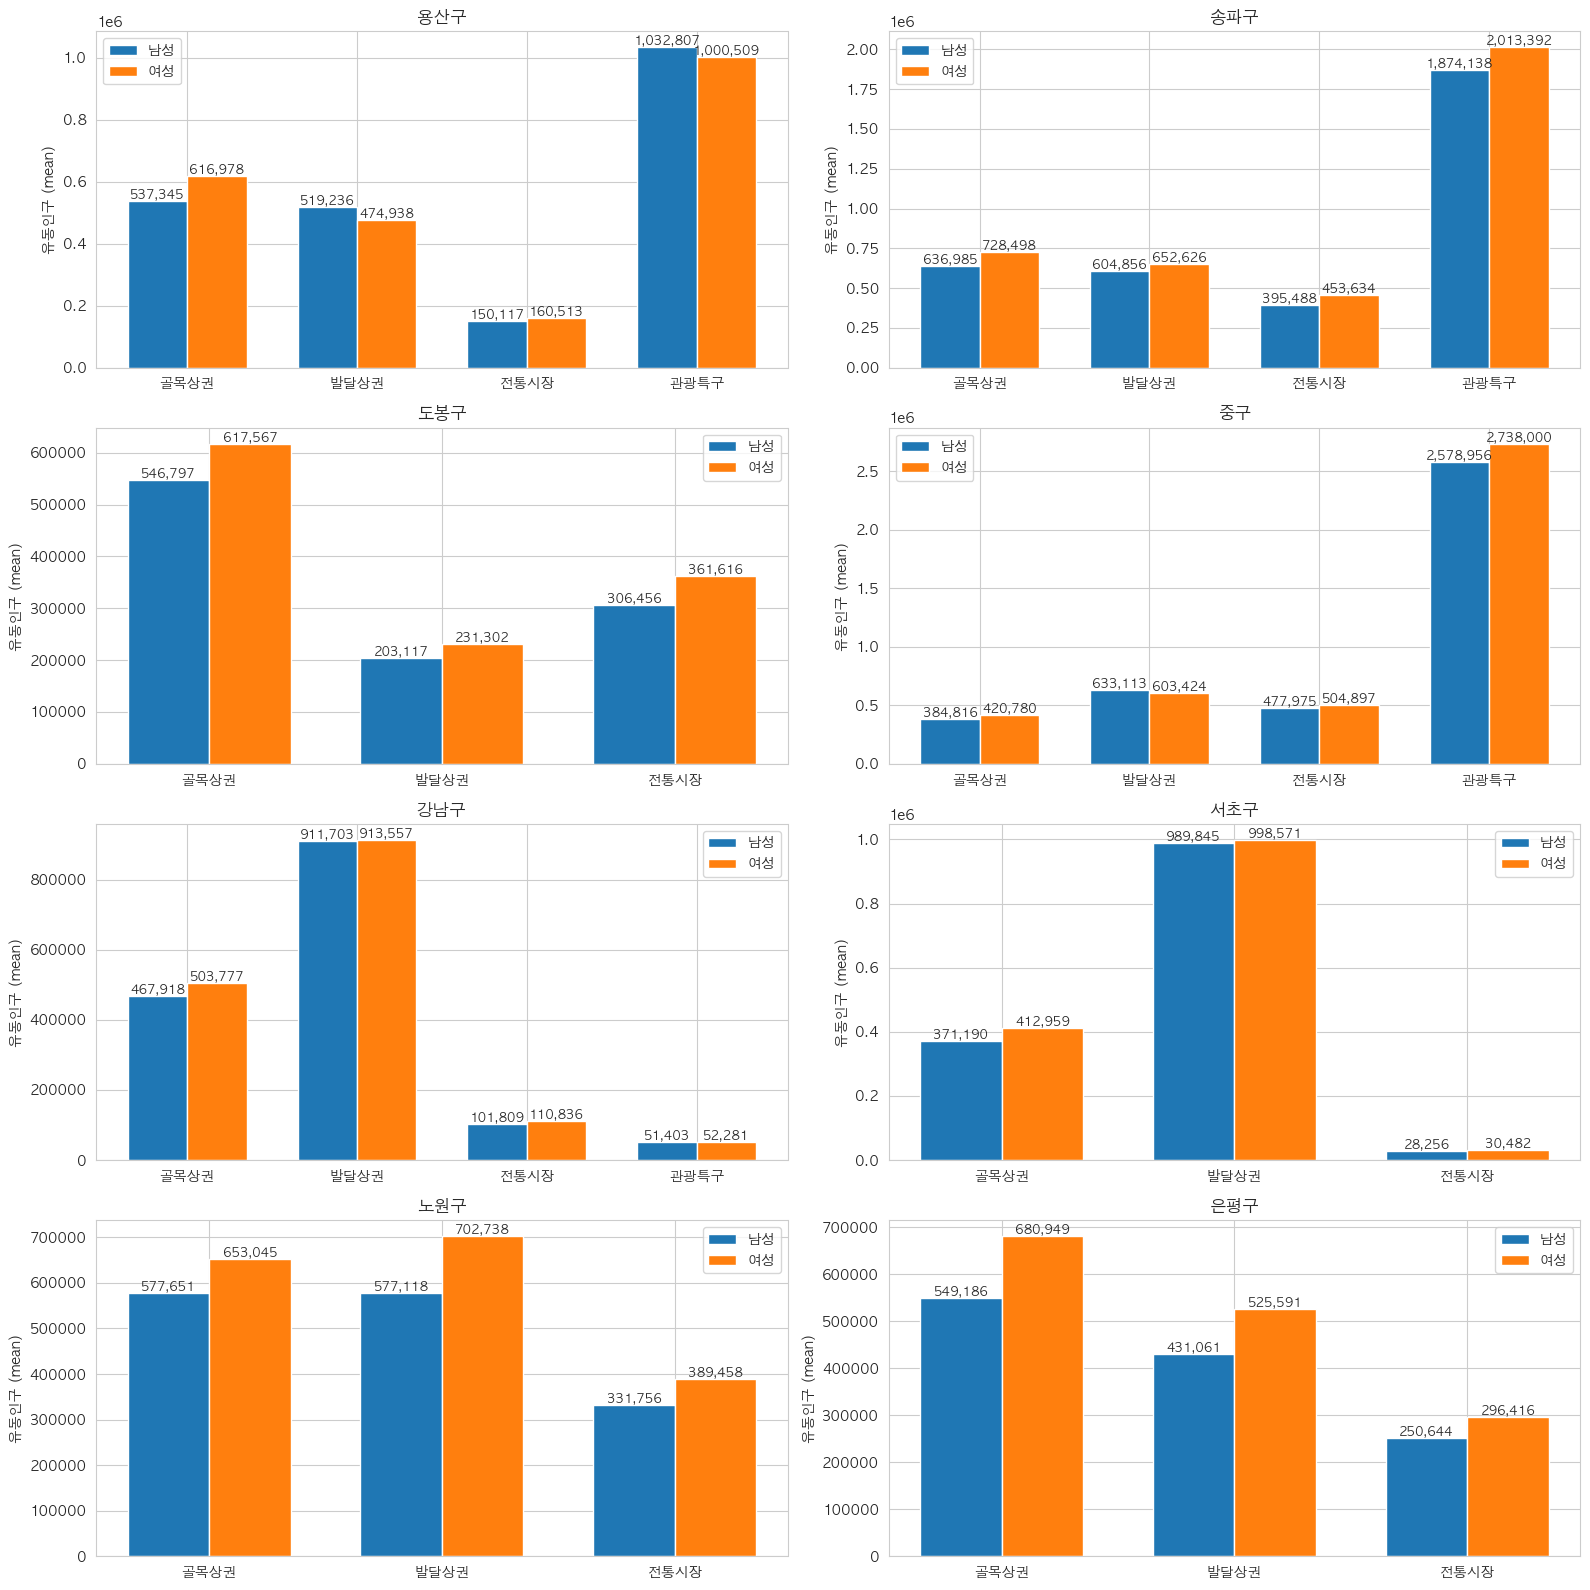

In [142]:
import math

market_order = ['골목상권', '발달상권', '전통시장', '관광특구']

# 상권유형 순서 정리
grouped['상권_구분_코드_명'] = pd.Categorical(
    grouped['상권_구분_코드_명'],
    categories=market_order,
    ordered=True
)
grouped = grouped.sort_values(['자치구_코드_명', '상권_구분_코드_명'])

# subplot 설정
n = len(target_gu)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, gu in enumerate(target_gu):
    ax = axes[i]
    temp = grouped[grouped['자치구_코드_명'] == gu].copy()
    
    x = np.arange(len(temp))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, temp['남성_유동인구_수'], width, label='남성')
    bars2 = ax.bar(x + width/2, temp['여성_유동인구_수'], width, label='여성')
    
    ax.set_title(gu, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(temp['상권_구분_코드_명'], rotation=0)
    ax.set_ylabel(f'유동인구 ({agg_func})')
    ax.legend()
    
    # 수치 라벨 표시
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h,
                f'{h:,.0f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

# 남는 축 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* 관광특구 매출건수 많은데 매출은 많은 이유 분석.

In [143]:
관광특구_매출 = 매출_영역[
    매출_상주_통합['상권_구분_코드_명'] == '관광특구'
]

In [144]:
관광특구_매출.groupby('상권_구분_코드_명')[
    ['시간대_17~21_매출_금액','시간대_21~24_매출_금액']
].mean()

,시간대_17~21_매출_금액,시간대_21~24_매출_금액
상권_구분_코드_명,,
관광특구,"1,346,275,498.49","377,019,024.44"


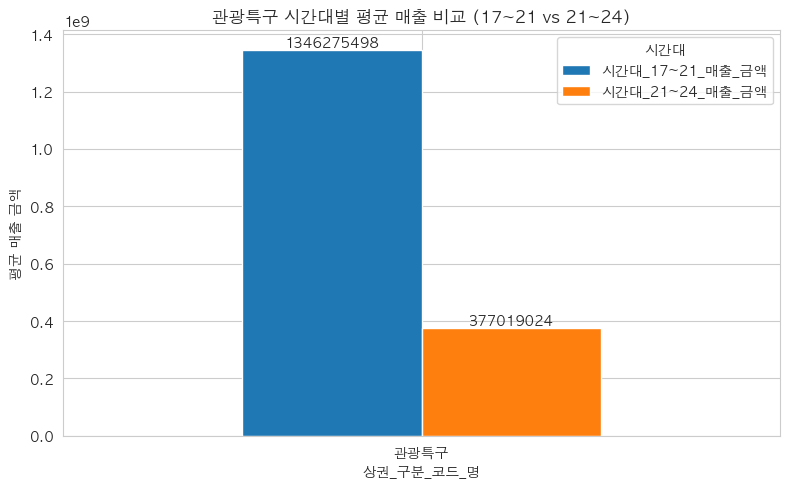

In [145]:
import matplotlib.pyplot as plt

# 그룹 평균 계산
df_plot = 관광특구_매출.groupby('상권_구분_코드_명')[
    ['시간대_17~21_매출_금액','시간대_21~24_매출_금액']
].mean()

# 시각화
ax = df_plot.plot(kind='bar', figsize=(8,5))

# 숫자 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge')

plt.title('관광특구 시간대별 평균 매출 비교 (17~21 vs 21~24)')
plt.ylabel('평균 매출 금액')
plt.xticks(rotation=0)
plt.legend(title='시간대')
plt.tight_layout()

plt.show()

In [146]:
관광특구_매출.groupby('상권_구분_코드_명')[
    ['주중_매출_금액','주말_매출_금액']
].mean()

,주중_매출_금액,주말_매출_금액
상권_구분_코드_명,,
관광특구,"3,606,423,058.76","1,312,043,251.19"


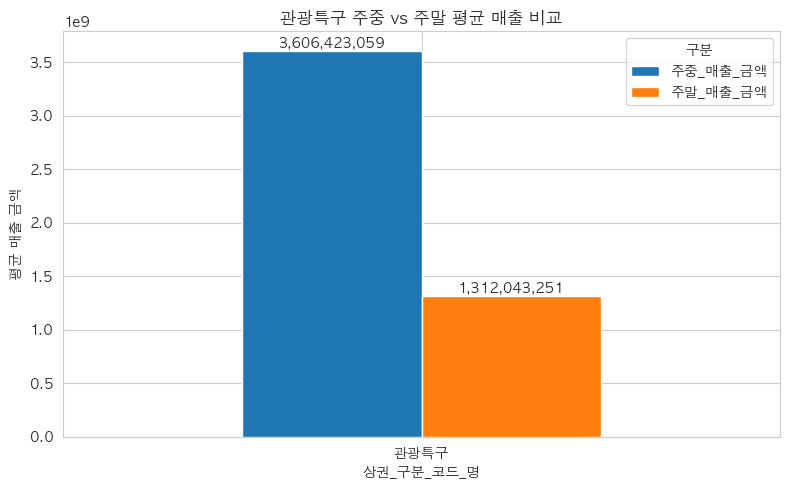

In [147]:
import matplotlib.pyplot as plt

# 그룹 평균 계산
df_plot = 관광특구_매출.groupby('상권_구분_코드_명')[
    ['주중_매출_금액','주말_매출_금액']
].mean()

# 시각화
ax = df_plot.plot(kind='bar', figsize=(8,5))

# 막대 위 숫자 표시 (천단위 콤마)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.title('관광특구 주중 vs 주말 평균 매출 비교')
plt.ylabel('평균 매출 금액')
plt.xticks(rotation=0)
plt.legend(title='구분')
plt.tight_layout()

plt.show()

In [148]:
관광특구_매출.groupby('상권_구분_코드_명')[
    ['남성_매출_금액','여성_매출_금액']
].sum()

,남성_매출_금액,여성_매출_금액
상권_구분_코드_명,,
관광특구,12077485590968,13853026718626


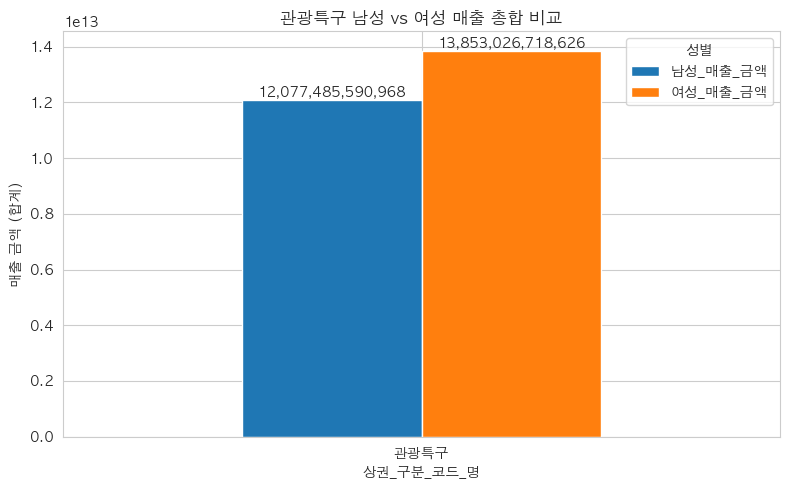

In [149]:
import matplotlib.pyplot as plt

# 그룹 합계 계산
df_plot = 관광특구_매출.groupby('상권_구분_코드_명')[
    ['남성_매출_금액','여성_매출_금액']
].sum()

# 시각화
ax = df_plot.plot(kind='bar', figsize=(8,5))

# 막대 위 숫자 표시 (천단위 콤마)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.title('관광특구 남성 vs 여성 매출 총합 비교')
plt.ylabel('매출 금액 (합계)')
plt.xticks(rotation=0)
plt.legend(title='성별')
plt.tight_layout()

plt.show()

In [150]:
관광특구_매출.groupby('상권_구분_코드_명')[
    ['연령대_20_매출_금액',
     '연령대_30_매출_금액',
     '연령대_40_매출_금액']
].sum()

,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액
상권_구분_코드_명,,,
관광특구,4145273227076,6287040583591,5451543197791


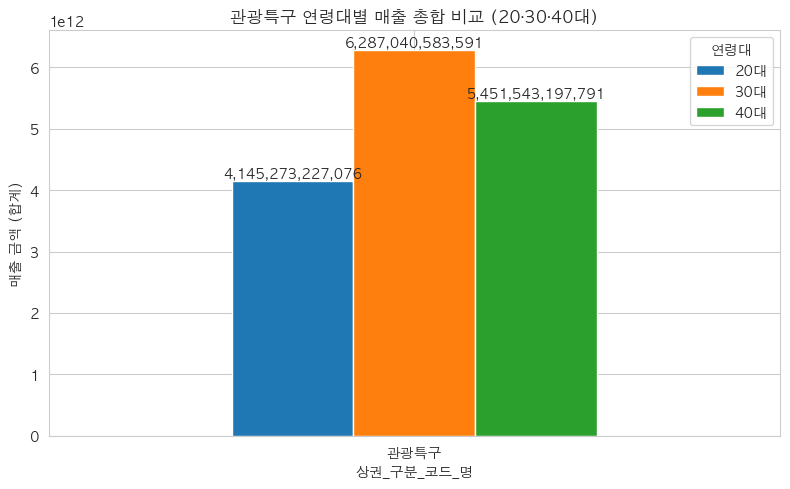

In [151]:
import matplotlib.pyplot as plt

# 그룹 합계 계산
df_plot = 관광특구_매출.groupby('상권_구분_코드_명')[
    ['연령대_20_매출_금액',
     '연령대_30_매출_금액',
     '연령대_40_매출_금액']
].sum()

# 컬럼명 보기 좋게 변경 (선택)
df_plot.columns = ['20대', '30대', '40대']

# 시각화
ax = df_plot.plot(kind='bar', figsize=(8,5))

# 막대 위 숫자 표시 (천단위 콤마)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.title('관광특구 연령대별 매출 총합 비교 (20·30·40대)')
plt.ylabel('매출 금액 (합계)')
plt.xticks(rotation=0)
plt.legend(title='연령대')
plt.tight_layout()

plt.show()

In [152]:
업종수=('서비스_업종_코드','nunique')

In [153]:
매출_영역.groupby('상권_구분_코드_명')['서비스_업종_코드'].nunique()

상권_구분_코드_명
골목상권    62
관광특구    61
발달상권    63
전통시장    60
Name: 서비스_업종_코드, dtype: int64

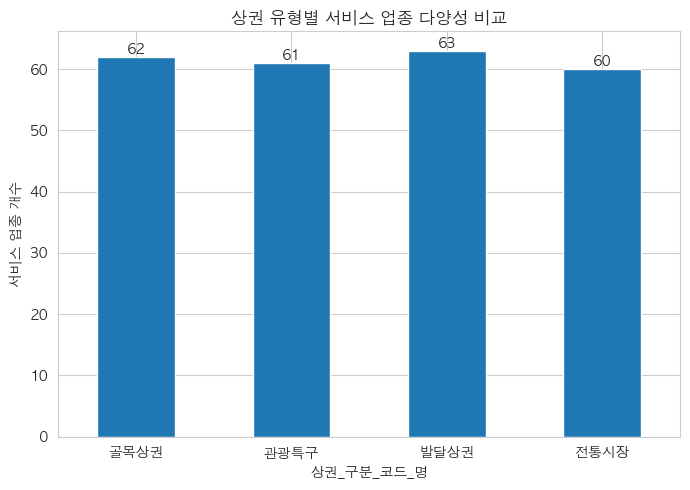

In [154]:
import matplotlib.pyplot as plt

# 상권 유형별 업종 수 계산
df_plot = 매출_영역.groupby('상권_구분_코드_명')['서비스_업종_코드'].nunique()

# 시각화
ax = df_plot.plot(kind='bar', figsize=(7,5))

# 막대 위 숫자 표시
for i, v in enumerate(df_plot):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')

plt.title('상권 유형별 서비스 업종 다양성 비교')
plt.ylabel('서비스 업종 개수')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

① 용산구 상권유형 구성
② 상권유형별 남녀 직장인 비율
③ 용산구 vs 타구 비교
④ 연도별 변화 여부 확인

In [155]:

매출_상주_통합.groupby('상권_구분_코드_명')['총_상주인구_수'].mean()

상권_구분_코드_명
골목상권   4,222.32
관광특구   3,181.36
발달상권   2,746.03
전통시장   1,096.15
Name: 총_상주인구_수, dtype: float64

In [156]:
매출_유동_통합.groupby('상권_구분_코드_명')['총_유동인구_수'].mean()

상권_구분_코드_명
골목상권   1,280,083.09
관광특구   4,644,161.49
발달상권   1,584,479.53
전통시장     534,827.14
Name: 총_유동인구_수, dtype: float64

In [157]:
매출_직장_통합.groupby('상권_구분_코드_명')['총_직장_인구_수'].mean()

상권_구분_코드_명
골목상권    1,063.31
관광특구   93,071.74
발달상권   13,628.47
전통시장    1,100.84
Name: 총_직장_인구_수, dtype: float64

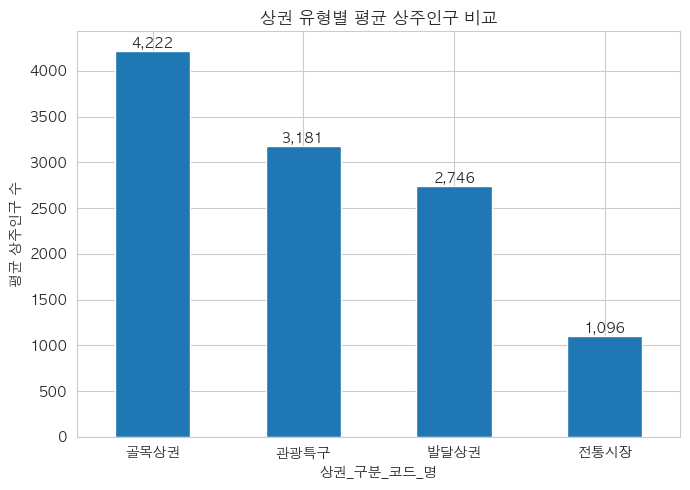

In [158]:
import matplotlib.pyplot as plt

# 상권 유형별 평균 상주인구 계산
df_plot = 매출_상주_통합.groupby('상권_구분_코드_명')['총_상주인구_수'].mean()

# 시각화
ax = df_plot.plot(kind='bar', figsize=(7,5))

# 막대 위 숫자 표시 (천단위 콤마)
for i, v in enumerate(df_plot):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom')

plt.title('상권 유형별 평균 상주인구 비교')
plt.ylabel('평균 상주인구 수')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

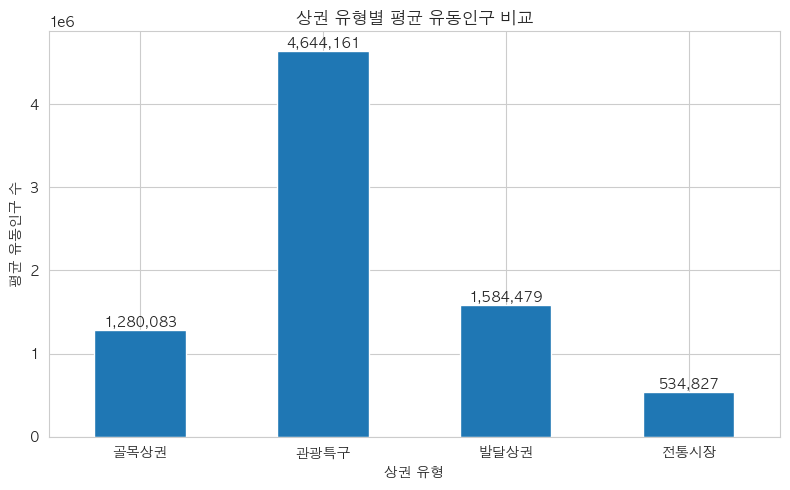

In [159]:
import matplotlib.pyplot as plt

# 데이터 (이미 계산된 Series라 가정)
유동인구 = 매출_유동_통합.groupby('상권_구분_코드_명')['총_유동인구_수'].mean()

# 그래프
plt.figure(figsize=(8,5))

ax = 유동인구.plot(kind='bar')

plt.title('상권 유형별 평균 유동인구 비교')
plt.xlabel('상권 유형')
plt.ylabel('평균 유동인구 수')

# 숫자 표시
for i, v in enumerate(유동인구):
    plt.text(i, v, f'{int(v):,}', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

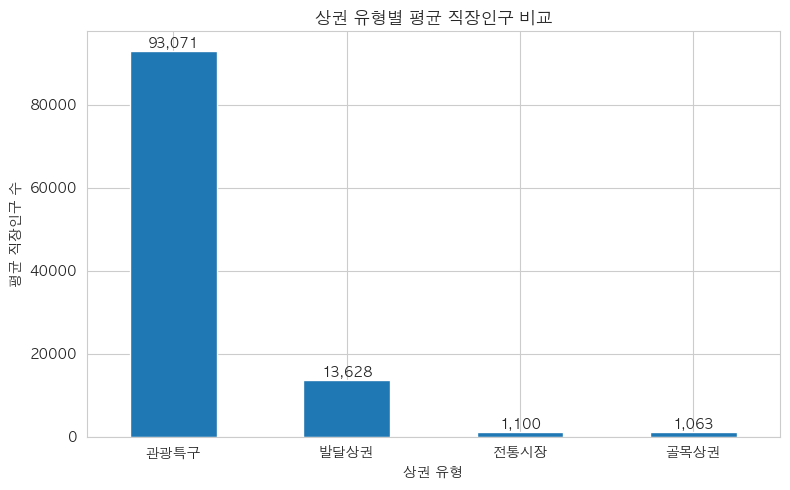

In [ ]:
import matplotlib.pyplot as plt

# 직장인구 데이터 (이미 계산된 Series)
직장인구 = 매출_직장_통합.groupby('상권_구분_코드_명')['총_직장_인구_수'].mean()

# 큰 값부터 정렬
직장인구_sorted = 직장인구.sort_values(ascending=False)

# 그래프
plt.figure(figsize=(8,5))

ax = 직장인구_sorted.plot(kind='bar')

plt.title('상권 유형별 평균 직장인구 비교')
plt.xlabel('상권 유형')
plt.ylabel('평균 직장인구 수')

# 수치 표시
for i, v in enumerate(직장인구_sorted):
    plt.text(i, v, f'{int(v):,}', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()